### Extract fused embeddings

In [ ]:
# ============================================================
# SAVE FUSED EMBEDDINGS FOR *ALL* ROWS (NO UMAP, NO SUBSAMPLE)
# + ALSO SAVE: MSI_CHAN_ONLY  ✅ NEW
#
# Save *all reps* (MAE-MSI, MAE-ImageNet, MAE-RandInit, PCA)
# for *5 variants*:
#   (A) SMILES + MSI_CLS
#   (B) SMILES + MSI_CHAN
#   (C) SMILES + MSI_CLS + MSI_CHAN
#   (D) MSI_CLS + MSI_CHAN
#   (E) MSI_CHAN_ONLY               ✅ NEW  (raw channel embedding only, gated)
#
# Fusion rules (NO CONCAT):
#   (A) z_tile = l2( alpha_cls*l2(z_cls) + (1-alpha_cls)*l2(z_smi) )
#   (B) z_chan = l2( alpha_chan*l2(z_chan) + (1-alpha_chan)*l2(z_smi) )
#   (C) z_all  = l2( w_smi*l2(z_smi) + w_cls*l2(z_cls) + w_chan*l2(z_chan) )
#   (D) z_msi  = l2( beta_msi*l2(z_cls) + (1-beta_msi)*l2(z_chan) )
#   (E) z_msi_chan_only = l2( z_chan )
#
# IMPORTANT gating for msi_chan:
# - embeddings_all.npy contains 32 channels per tile INCLUDING blank/zero channels
# - channels_with_candidates.parquet (ch_df) contains ONLY "real" channels
# - We therefore gate:
#     if (tile, channel_idx) not present in ch_df -> treat as missing (skip row)
#
# Also: channel-meta has split; ch_df doesn't.
# We auto-resolve split by checking (ds,tr,tc,split) existence in this order:
#   train -> val -> test (then any match)
#
# ✅ SKIP LOGIC (your request):
#   - We do NOT skip a rep just because fused_all exists.
#   - We ONLY skip a rep if ALL outputs exist:
#       fused_tile__REP.npy, fused_chan__REP.npy, fused_all__REP.npy, fused_msi__REP.npy,
#       msi_chan_only__REP.npy
#     plus all row_ids and summary.
#
# Outputs:
#   spatial_metabolomics_atlas/channel_embeddings/
#     fused_tile__<REP>.npy        + row_ids__tile__<REP>.npy
#     fused_chan__<REP>.npy        + row_ids__chan__<REP>.npy
#     fused_all__<REP>.npy         + row_ids__all__<REP>.npy
#     fused_msi__<REP>.npy         + row_ids__msi__<REP>.npy
#     msi_chan_only__<REP>.npy     + row_ids__msi_chan_only__<REP>.npy   ✅ NEW
#     summary__<REP>.csv
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
from tqdm import tqdm

# -------------------------
# CONFIG
# -------------------------
SEED = 6740

BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

PQ      = BASE / "molformer_pubchem_index_enriched_semantic.parquet"
SMI_NPY = BASE / "molformer_pubchem_embeddings.npy"

# Tile-level CLS (MSI model)
MSI_TILE_DIR   = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_TILE_META  = MSI_TILE_DIR / "meta.csv"
MSI_TILE_CLS   = MSI_TILE_DIR / "cls_embeddings.npy"  # (Ntiles, D)

# Single-channel embeddings (N,C,D) for MAE-MSI
MSI_CHAN_DIR       = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel")
MSI_CHAN_ALL_NPY   = MSI_CHAN_DIR / "embeddings_all.npy"  # (N_total,C,D)
MSI_CHAN_ALL_META  = MSI_CHAN_DIR / "meta__all.csv"       # includes split

# Benchmarks: tile-level CLS
BASELINES_TILE_DIR = Path("msi-vitmae_REBUILT2_2/benchmarks/embeddings_baselines")

# Benchmarks: single-channel embeddings (N,C,D) packed
BASELINES_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/benchmarks/embeddings_single_channel_baselines")

# Output
OUT_DIR = Path("spatial_metabolomics_atlas") / "channel_embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Fusion weights
ALPHA_CLS   = 0.5   # for (A) SMILES + CLS
ALPHA_CHAN  = 0.5   # for (B) SMILES + CHAN
BETA_MSI    = 0.5   # for (D) CLS + CHAN

# for (C) combined
W_SMI  = 1/3
W_CLS  = 1/3
W_CHAN = 1/3

# Prefer split order when channel-meta has split but ch_df doesn't
SPLIT_PREFER_ORDER = ("train", "val", "test")

# columns in channels parquet
DATASET_COL   = "dataset_id"
TILE_R_COL    = "tile_r"
TILE_C_COL    = "tile_c"
CAND_CIDS_COL = "cand_pubchem_cids"

# For valid-channel gating map (ch_df must have channel_idx)
CHAN_IDX_COL  = "channel_idx"
C_TARGET      = 32

SAVE_DTYPE = np.float32
MMAP_MODE  = "r"

# If True: recompute a rep even if outputs exist
OVERWRITE = False

# -------------------------
# CID helpers
# -------------------------
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    # unique-preserve-order
    seen, uniq = set(), []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq

def build_cid_to_index_map(pq_df: pd.DataFrame, cid_col: str = "cid") -> dict[str, int]:
    if cid_col not in pq_df.columns:
        raise KeyError(f"PQ missing {cid_col!r}. Columns: {list(pq_df.columns)}")
    cid_series = pq_df[cid_col].astype(str).map(normalize_cid)
    cid_to_idx: dict[str, int] = {}
    for i, cid in enumerate(cid_series.values):
        if cid and cid not in cid_to_idx:
            cid_to_idx[cid] = i
    return cid_to_idx

def gather_candidate_indices_for_row(r: pd.Series, cid_to_idx: dict[str, int]) -> np.ndarray:
    cids = parse_cids_field(r.get(CAND_CIDS_COL))
    if not cids:
        return np.asarray([], dtype=np.int64)
    idxs = []
    for cid in cids:
        j = cid_to_idx.get(cid)
        if j is not None:
            idxs.append(j)
    return np.asarray(idxs, dtype=np.int64)

# -------------------------
# vector helpers
# -------------------------
def l2(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    v = np.asarray(v, dtype=np.float32)
    n = float(np.linalg.norm(v) + eps)
    return v / n

def mean_pool(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X)
    if X.size == 0:
        raise ValueError("Cannot mean-pool empty.")
    return X.mean(axis=0)

# -------------------------
# channel idx inference (robust)
# -------------------------
def infer_chan_index(row: pd.Series) -> int:
    if CHAN_IDX_COL in row.index:
        v = row.get(CHAN_IDX_COL)
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return int(v)

    for col in ["chan", "channel", "channel_i", "ch", "c"]:
        if col in row.index:
            v = row.get(col)
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            return int(v)

    raise KeyError(
        "Could not infer channel index from row "
        f"(expected '{CHAN_IDX_COL}' or one of chan/channel/channel_i/ch/c)."
    )

# -------------------------
# gating: valid-channel map from ch_df
# -------------------------
def build_valid_chan_map_from_chdf(ch_df: pd.DataFrame, C: int = 32) -> dict[tuple, np.ndarray]:
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL}
    miss = need - set(ch_df.columns)
    if miss:
        raise KeyError(f"ch_df missing columns for gating: {sorted(miss)}")

    valid: dict[tuple, np.ndarray] = {}
    for (ds, tr, tc), g in ch_df.groupby([DATASET_COL, TILE_R_COL, TILE_C_COL], sort=False):
        mask = np.zeros(C, dtype=bool)
        idxs = g[CHAN_IDX_COL].astype(int).values
        idxs = idxs[(0 <= idxs) & (idxs < C)]
        mask[idxs] = True
        valid[(str(ds), int(tr), int(tc))] = mask
    return valid

# -------------------------
# tile index builders
# -------------------------
def build_tile_index(meta_df: pd.DataFrame) -> dict[tuple, int]:
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"meta missing columns: {sorted(miss)}")

    key_to_i: dict[tuple, int] = {}
    for i, rr in meta_df.reset_index(drop=True).iterrows():
        key = (str(rr[DATASET_COL]), int(rr[TILE_R_COL]), int(rr[TILE_C_COL]))
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i

def build_chan_tile_index(meta_df: pd.DataFrame) -> tuple[dict[tuple, int], bool]:
    """
    Returns:
      key_to_i, has_split
      - if has_split: key = (ds,tr,tc,split)
      - else        : key = (ds,tr,tc)
    """
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"channel meta missing columns: {sorted(miss)}")

    has_split = "split" in meta_df.columns
    key_to_i: dict[tuple, int] = {}
    for i, rr in meta_df.reset_index(drop=True).iterrows():
        ds = str(rr[DATASET_COL])
        tr = int(rr[TILE_R_COL])
        tc = int(rr[TILE_C_COL])
        if has_split:
            sp = str(rr["split"])
            key = (ds, tr, tc, sp)
        else:
            key = (ds, tr, tc)
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i, has_split

def infer_tile_key_for_chan_embeddings(
    row: pd.Series,
    *,
    chan_meta_has_split: bool,
    chan_tile_to_i: dict[tuple, int],
    prefer_order: tuple[str, ...] = SPLIT_PREFER_ORDER,
) -> tuple:
    ds = str(row.get(DATASET_COL))
    tr = int(row.get(TILE_R_COL))
    tc = int(row.get(TILE_C_COL))

    if not chan_meta_has_split:
        return (ds, tr, tc)

    # if row itself has split, use it
    if "split" in row.index and row.get("split") is not None:
        return (ds, tr, tc, str(row.get("split")))

    # prefer train -> val -> test
    for sp in prefer_order:
        k = (ds, tr, tc, sp)
        if k in chan_tile_to_i:
            return k

    # fallback any match
    prefix = (ds, tr, tc)
    for k in chan_tile_to_i.keys():
        if len(k) == 4 and k[:3] == prefix:
            return k

    # nothing found
    return (ds, tr, tc, prefer_order[0])

# -------------------------
# rep loaders
# -------------------------
def _load_tile_rep(rep: str) -> tuple[np.ndarray, pd.DataFrame, dict[tuple, int], int]:
    if rep == "MAE-MSI":
        emb_p  = MSI_TILE_CLS
        meta_p = MSI_TILE_META

    elif rep == "MAE-ImageNet":
        candidates = [
            (BASELINES_TILE_DIR / "mae_imagenet_only.cls_embeddings.npy", BASELINES_TILE_DIR / "mae_imagenet_only.meta.csv"),
            (BASELINES_TILE_DIR / "mae_imagenet_only" / "cls_embeddings.npy", BASELINES_TILE_DIR / "mae_imagenet_only" / "meta.csv"),
        ]
        emb_p = meta_p = None
        for e, m in candidates:
            if e.exists() and m.exists():
                emb_p, meta_p = e, m
                break
        if emb_p is None:
            raise FileNotFoundError("Could not find MAE-ImageNet tile CLS files under embeddings_baselines.")

    elif rep == "MAE-RandInit":
        candidates = [
            (BASELINES_TILE_DIR / "mae_randinit.cls_embeddings.npy", BASELINES_TILE_DIR / "mae_randinit.meta.csv"),
            (BASELINES_TILE_DIR / "mae_randinit" / "cls_embeddings.npy", BASELINES_TILE_DIR / "mae_randinit" / "meta.csv"),
        ]
        emb_p = meta_p = None
        for e, m in candidates:
            if e.exists() and m.exists():
                emb_p, meta_p = e, m
                break
        if emb_p is None:
            raise FileNotFoundError("Could not find MAE-RandInit tile CLS files under embeddings_baselines.")

    elif rep == "PCA":
        candidates = [
            (BASELINES_TILE_DIR / "pca.embeddings.npy", BASELINES_TILE_DIR / "pca.meta.csv"),
            (BASELINES_TILE_DIR / "pca" / "embeddings.npy", BASELINES_TILE_DIR / "pca" / "meta.csv"),
        ]
        emb_p = meta_p = None
        for e, m in candidates:
            if e.exists() and m.exists():
                emb_p, meta_p = e, m
                break
        if emb_p is None:
            raise FileNotFoundError("Could not find PCA tile embedding files under embeddings_baselines.")

    else:
        raise ValueError(f"Unknown tile rep: {rep}")

    meta = pd.read_csv(meta_p)
    tile_to_i = build_tile_index(meta)

    Z = np.load(emb_p, mmap_mode=MMAP_MODE)
    if Z.ndim != 2:
        raise RuntimeError(f"{rep} tile embeddings must be 2D (N,D). Got {Z.shape}")
    if len(Z) != len(meta):
        raise RuntimeError(f"{rep} len mismatch: Z={Z.shape} meta={meta.shape}")

    D = int(Z.shape[1])
    print(f"[LOAD tile] {rep}: Z={Z.shape} meta={meta.shape}")
    return Z, meta, tile_to_i, D

def _load_chan_rep(rep: str) -> tuple[np.ndarray, pd.DataFrame, dict[tuple, int], bool, int, int]:
    if rep == "MAE-MSI":
        emb_p  = MSI_CHAN_ALL_NPY
        meta_p = MSI_CHAN_ALL_META
    else:
        rep_dir = BASELINES_CHAN_DIR / {
            "MAE-ImageNet": "mae_imagenet_only",
            "MAE-RandInit": "mae_randinit",
            "PCA": "pca",
        }[rep]
        emb_p  = rep_dir / "embeddings_all.npy"
        meta_p = rep_dir / "meta__all.csv"

    if not emb_p.exists():
        raise FileNotFoundError(f"Missing channel embeddings_all for {rep}: {emb_p}")
    if not meta_p.exists():
        raise FileNotFoundError(f"Missing channel meta__all for {rep}: {meta_p}")

    meta = pd.read_csv(meta_p)
    tile_to_i, has_split = build_chan_tile_index(meta)

    Z = np.load(emb_p, mmap_mode=MMAP_MODE)
    if Z.ndim != 3:
        raise RuntimeError(f"{rep} channel embeddings must be 3D (N,C,D). Got {Z.shape}")
    if len(Z) != len(meta):
        raise RuntimeError(f"{rep} len mismatch: Z={Z.shape} meta={meta.shape}")

    C = int(Z.shape[1])
    D = int(Z.shape[2])
    print(f"[LOAD chan] {rep}: Z={Z.shape} meta={meta.shape} has_split={has_split}")
    return Z, meta, tile_to_i, has_split, C, D

# -------------------------
# row -> embeddings
# -------------------------
def get_smi_embedding(row: pd.Series, *, cid_to_idx: dict[str, int], ZS_ALL: np.ndarray) -> np.ndarray | None:
    idx = gather_candidate_indices_for_row(row, cid_to_idx)
    if idx.size == 0:
        return None
    return l2(mean_pool(np.asarray(ZS_ALL[idx])))

def get_tile_cls_embedding(
    row: pd.Series,
    *,
    Z_tile: np.ndarray,
    tile_to_i: dict[tuple, int],
) -> np.ndarray | None:
    key = (str(row[DATASET_COL]), int(row[TILE_R_COL]), int(row[TILE_C_COL]))
    i = tile_to_i.get(key)
    if i is None:
        return None
    return l2(np.asarray(Z_tile[i], dtype=np.float32))

def get_chan_embedding_gated(
    row: pd.Series,
    *,
    Z_chan_all: np.ndarray,              # (N,C,D)
    chan_tile_to_i: dict[tuple, int],
    chan_meta_has_split: bool,
    valid_chan_map: dict[tuple, np.ndarray] | None,
) -> np.ndarray | None:
    ds = str(row[DATASET_COL])
    tr = int(row[TILE_R_COL])
    tc = int(row[TILE_C_COL])
    k = infer_chan_index(row)

    # gate: must be a "real channel" in ch_df for this tile
    if valid_chan_map is not None:
        mask = valid_chan_map.get((ds, tr, tc))
        if mask is not None:
            if not (0 <= k < len(mask)) or (not mask[k]):
                return None

    key_tile = infer_tile_key_for_chan_embeddings(
        row,
        chan_meta_has_split=chan_meta_has_split,
        chan_tile_to_i=chan_tile_to_i,
        prefer_order=SPLIT_PREFER_ORDER,
    )
    i = chan_tile_to_i.get(key_tile)
    if i is None:
        return None

    if not (0 <= k < Z_chan_all.shape[1]):
        return None

    return l2(np.asarray(Z_chan_all[i, k, :], dtype=np.float32))

# -------------------------
# skip logic (rep complete?)
# -------------------------
def rep_is_complete(rep: str) -> bool:
    required = [
        OUT_DIR / f"fused_tile__{rep}.npy",
        OUT_DIR / f"fused_chan__{rep}.npy",
        OUT_DIR / f"fused_all__{rep}.npy",
        OUT_DIR / f"fused_msi__{rep}.npy",                 # CLS+CHAN
        OUT_DIR / f"msi_chan_only__{rep}.npy",             # ✅ NEW

        OUT_DIR / f"row_ids__tile__{rep}.npy",
        OUT_DIR / f"row_ids__chan__{rep}.npy",
        OUT_DIR / f"row_ids__all__{rep}.npy",
        OUT_DIR / f"row_ids__msi__{rep}.npy",
        OUT_DIR / f"row_ids__msi_chan_only__{rep}.npy",    # ✅ NEW

        OUT_DIR / f"summary__{rep}.csv",
    ]
    return all(p.exists() for p in required)

def cleanup_tmp(rep: str) -> None:
    for p in [
        OUT_DIR / f"__tmp__tile__{rep}.npy",
        OUT_DIR / f"__tmp__chan__{rep}.npy",
        OUT_DIR / f"__tmp__all__{rep}.npy",
        OUT_DIR / f"__tmp__msi__{rep}.npy",
        OUT_DIR / f"__tmp__msi_chan_only__{rep}.npy",  # ✅ NEW
    ]:
        try:
            if p.exists():
                p.unlink()
        except Exception:
            pass

# -------------------------
# main fusion writer (streaming)
# -------------------------
def fuse_and_save_all_five(
    *,
    rep: str,
    ch_df: pd.DataFrame,
    cid_to_idx: dict[str, int],
    ZS_ALL: np.ndarray,
    # tile
    Z_tile: np.ndarray,
    tile_to_i: dict[tuple, int],
    # chan
    Z_chan_all: np.ndarray,
    chan_tile_to_i: dict[tuple, int],
    chan_meta_has_split: bool,
    valid_chan_map: dict[tuple, np.ndarray] | None,
    D_expected: int,
) -> None:
    if (not OVERWRITE) and rep_is_complete(rep):
        print(f"[SKIP] {rep}: all outputs already exist (including msi_chan_only).")
        return

    cleanup_tmp(rep)

    n_max = len(ch_df)

    out_tile_tmp = np.lib.format.open_memmap(
        OUT_DIR / f"__tmp__tile__{rep}.npy", mode="w+", dtype=SAVE_DTYPE, shape=(n_max, D_expected)
    )
    out_chan_tmp = np.lib.format.open_memmap(
        OUT_DIR / f"__tmp__chan__{rep}.npy", mode="w+", dtype=SAVE_DTYPE, shape=(n_max, D_expected)
    )
    out_all_tmp = np.lib.format.open_memmap(
        OUT_DIR / f"__tmp__all__{rep}.npy", mode="w+", dtype=SAVE_DTYPE, shape=(n_max, D_expected)
    )
    out_msi_tmp = np.lib.format.open_memmap(
        OUT_DIR / f"__tmp__msi__{rep}.npy", mode="w+", dtype=SAVE_DTYPE, shape=(n_max, D_expected)
    )
    out_msi_chan_only_tmp = np.lib.format.open_memmap(
        OUT_DIR / f"__tmp__msi_chan_only__{rep}.npy", mode="w+", dtype=SAVE_DTYPE, shape=(n_max, D_expected)
    )

    # one row_ids stream shared by all outputs (identical filtering)
    row_ids = np.empty((n_max,), dtype=np.int64)

    n_keep = 0
    try:
        for rid in tqdm(range(n_max), desc=f"[FUSE] {rep}", total=n_max):
            row = ch_df.iloc[rid]

            z_smi = get_smi_embedding(row, cid_to_idx=cid_to_idx, ZS_ALL=ZS_ALL)
            if z_smi is None:
                continue
            z_cls = get_tile_cls_embedding(row, Z_tile=Z_tile, tile_to_i=tile_to_i)
            if z_cls is None:
                continue
            z_ch = get_chan_embedding_gated(
                row,
                Z_chan_all=Z_chan_all,
                chan_tile_to_i=chan_tile_to_i,
                chan_meta_has_split=chan_meta_has_split,
                valid_chan_map=valid_chan_map,
            )
            if z_ch is None:
                continue

            if z_smi.shape[0] != D_expected:
                raise RuntimeError(f"{rep}: SMILES dim={z_smi.shape[0]} != expected {D_expected}")
            if z_cls.shape[0] != D_expected:
                raise RuntimeError(f"{rep}: CLS dim={z_cls.shape[0]} != expected {D_expected}")
            if z_ch.shape[0] != D_expected:
                raise RuntimeError(f"{rep}: CHAN dim={z_ch.shape[0]} != expected {D_expected}")

            z_tile = l2(ALPHA_CLS * z_cls + (1.0 - ALPHA_CLS) * z_smi)
            z_chan = l2(ALPHA_CHAN * z_ch + (1.0 - ALPHA_CHAN) * z_smi)
            z_all  = l2((W_SMI * z_smi) + (W_CLS * z_cls) + (W_CHAN * z_ch))
            z_msi  = l2(BETA_MSI * z_cls + (1.0 - BETA_MSI) * z_ch)

            # ✅ NEW: pure channel-only representation (already l2'd in get_chan_embedding_gated)
            z_msi_chan_only = l2(z_ch)

            row_ids[n_keep] = int(rid)
            out_tile_tmp[n_keep, :] = z_tile.astype(SAVE_DTYPE, copy=False)
            out_chan_tmp[n_keep, :] = z_chan.astype(SAVE_DTYPE, copy=False)
            out_all_tmp[n_keep, :]  = z_all.astype(SAVE_DTYPE, copy=False)
            out_msi_tmp[n_keep, :]  = z_msi.astype(SAVE_DTYPE, copy=False)
            out_msi_chan_only_tmp[n_keep, :] = z_msi_chan_only.astype(SAVE_DTYPE, copy=False)

            n_keep += 1

            if (n_keep % 10000) == 0:
                out_tile_tmp.flush()
                out_chan_tmp.flush()
                out_all_tmp.flush()
                out_msi_tmp.flush()
                out_msi_chan_only_tmp.flush()

        out_tile_tmp.flush()
        out_chan_tmp.flush()
        out_all_tmp.flush()
        out_msi_tmp.flush()
        out_msi_chan_only_tmp.flush()

        if n_keep == 0:
            print(f"[WARN] {rep}: no rows produced.")
            return

        row_ids_out = row_ids[:n_keep].copy()

        Z_tile_out = np.asarray(out_tile_tmp[:n_keep, :], dtype=SAVE_DTYPE)
        Z_chan_out = np.asarray(out_chan_tmp[:n_keep, :], dtype=SAVE_DTYPE)
        Z_all_out  = np.asarray(out_all_tmp[:n_keep, :], dtype=SAVE_DTYPE)
        Z_msi_out  = np.asarray(out_msi_tmp[:n_keep, :], dtype=SAVE_DTYPE)
        Z_msi_chan_only_out = np.asarray(out_msi_chan_only_tmp[:n_keep, :], dtype=SAVE_DTYPE)

        np.save(OUT_DIR / f"fused_tile__{rep}.npy", Z_tile_out)
        np.save(OUT_DIR / f"fused_chan__{rep}.npy", Z_chan_out)
        np.save(OUT_DIR / f"fused_all__{rep}.npy",  Z_all_out)
        np.save(OUT_DIR / f"fused_msi__{rep}.npy",  Z_msi_out)
        np.save(OUT_DIR / f"msi_chan_only__{rep}.npy", Z_msi_chan_only_out)  # ✅ NEW

        np.save(OUT_DIR / f"row_ids__tile__{rep}.npy", row_ids_out)
        np.save(OUT_DIR / f"row_ids__chan__{rep}.npy", row_ids_out)
        np.save(OUT_DIR / f"row_ids__all__{rep}.npy",  row_ids_out)
        np.save(OUT_DIR / f"row_ids__msi__{rep}.npy",  row_ids_out)
        np.save(OUT_DIR / f"row_ids__msi_chan_only__{rep}.npy", row_ids_out)  # ✅ NEW

        summary = pd.DataFrame([{
            "rep": rep,
            "rows_total": int(n_max),
            "rows_kept": int(n_keep),
            "alpha_cls": float(ALPHA_CLS),
            "alpha_chan": float(ALPHA_CHAN),
            "beta_msi": float(BETA_MSI),
            "w_smi": float(W_SMI),
            "w_cls": float(W_CLS),
            "w_chan": float(W_CHAN),
            "D": int(D_expected),
            "saved_msi_chan_only": True,
        }])
        summary.to_csv(OUT_DIR / f"summary__{rep}.csv", index=False)

        print(f"[OK] {rep}: kept {n_keep}/{n_max}")

    finally:
        cleanup_tmp(rep)

# ============================================================
# MAIN
# ============================================================
def main():
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    ch_df = pd.read_parquet(CHAN_PQ)
    print("[LOAD] channels:", ch_df.shape)

    for col in [DATASET_COL, TILE_R_COL, TILE_C_COL, CAND_CIDS_COL]:
        if col not in ch_df.columns:
            raise KeyError(f"channels parquet missing {col!r}. Columns: {list(ch_df.columns)}")

    valid_chan_map = None
    if CHAN_IDX_COL in ch_df.columns:
        valid_chan_map = build_valid_chan_map_from_chdf(ch_df, C=C_TARGET)
        print("[INFO] valid_chan_map built (gating enabled)")
    else:
        print("[WARN] ch_df has no 'channel_idx' -> gating DISABLED (msi_chan may include blanks!)")

    if not PQ.exists():
        raise FileNotFoundError(f"Missing: {PQ}")
    pq_df = pd.read_parquet(PQ, columns=["cid"])
    cid_to_idx = build_cid_to_index_map(pq_df, cid_col="cid")

    if not SMI_NPY.exists():
        raise FileNotFoundError(f"Missing: {SMI_NPY}")
    ZS_ALL = np.load(SMI_NPY, mmap_mode=MMAP_MODE)
    if ZS_ALL.ndim != 2:
        raise RuntimeError(f"MolFormer embeddings must be 2D, got {ZS_ALL.shape}")
    D_SMI = int(ZS_ALL.shape[1])
    print("[LOAD] MolFormer:", ZS_ALL.shape, f"(dim={D_SMI})")

    reps = ["PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"]

    for rep in reps:
        if (not OVERWRITE) and rep_is_complete(rep):
            print(f"[SKIP] {rep}: already complete.")
            continue

        Z_tile, tile_meta, tile_to_i, D_tile = _load_tile_rep(rep)
        Z_chan_all, chan_meta, chan_tile_to_i, chan_meta_has_split, C, D_chan = _load_chan_rep(rep)

        if D_tile != D_SMI:
            raise RuntimeError(f"[DIM] {rep}: tile D={D_tile} != MolFormer D={D_SMI}")
        if D_chan != D_SMI:
            raise RuntimeError(f"[DIM] {rep}: chan D={D_chan} != MolFormer D={D_SMI}")

        if C != C_TARGET:
            print(f"[WARN] {rep}: channel C={C} != C_TARGET={C_TARGET}. Using C={C} bounds.")

        fuse_and_save_all_five(
            rep=rep,
            ch_df=ch_df,
            cid_to_idx=cid_to_idx,
            ZS_ALL=ZS_ALL,
            Z_tile=Z_tile,
            tile_to_i=tile_to_i,
            Z_chan_all=Z_chan_all,
            chan_tile_to_i=chan_tile_to_i,
            chan_meta_has_split=chan_meta_has_split,
            valid_chan_map=valid_chan_map,
            D_expected=D_SMI,
        )

    print(f"\n[DONE] Saved fused embeddings under:\n  {OUT_DIR.resolve()}")
    print(f"[NOTE] OVERWRITE={OVERWRITE}")

if __name__ == "__main__":
    main()

[LOAD] channels: (164359, 21)
[INFO] valid_chan_map built (gating enabled)
[LOAD] MolFormer: (30478, 768) (dim=768)
[LOAD tile] PCA: Z=(5811, 768) meta=(5811, 14)
[LOAD chan] PCA: Z=(5811, 32, 768) meta=(5811, 14) has_split=True


[FUSE] PCA: 100%|██████████| 164359/164359 [02:24<00:00, 1134.29it/s]


[OK] PCA: kept 157847/164359
[LOAD tile] MAE-RandInit: Z=(5811, 768) meta=(5811, 14)
[LOAD chan] MAE-RandInit: Z=(5811, 32, 768) meta=(5811, 14) has_split=True


[FUSE] MAE-RandInit: 100%|██████████| 164359/164359 [02:30<00:00, 1093.43it/s]


[OK] MAE-RandInit: kept 157847/164359
[LOAD tile] MAE-ImageNet: Z=(5811, 768) meta=(5811, 14)
[LOAD chan] MAE-ImageNet: Z=(5811, 32, 768) meta=(5811, 14) has_split=True


[FUSE] MAE-ImageNet: 100%|██████████| 164359/164359 [01:47<00:00, 1529.10it/s]


[OK] MAE-ImageNet: kept 157847/164359
[LOAD tile] MAE-MSI: Z=(5811, 768) meta=(5811, 14)
[LOAD chan] MAE-MSI: Z=(5811, 32, 768) meta=(5811, 14) has_split=True


[FUSE] MAE-MSI: 100%|██████████| 164359/164359 [01:59<00:00, 1377.49it/s]


[OK] MAE-MSI: kept 157847/164359

[DONE] Saved fused embeddings under:
  \\bme-data2.ad.gatech.edu\labs6\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\channel_embeddings
[NOTE] OVERWRITE=False


### Benchmark results

In [ ]:
# ============================================================
# FUSED EMBEDDINGS (3 fusion types) — FULL BENCHMARK SUITE
#   + EXTRA BASELINE: MSI_CHAN (NO FUSION)
#   WITH *GROUPED* TRAIN/VAL/TEST SPLITS BY dataset_id (NO DATASET LEAKAGE)
#
# Variants (per rep):
#   (0) msi_chan_only : MSI_CHAN (no fusion)             -> built from raw channel embeddings
#   (A) tile          : SMILES + MSI_CLS                 -> fused_tile__<REP>.npy
#   (B) chan          : SMILES + MSI_CHAN                -> fused_chan__<REP>.npy
#   (C) all           : SMILES + MSI_CLS + MSI_CHAN      -> fused_all__<REP>.npy
#
# This script:
# - loads ALL (rep,variant) embeddings
# - evaluates the FULL suite for EACH (rep,variant):
#     (A) Linear probe (LogReg) — choose C on VAL, eval on TEST (per split repeat)
#     (B) kNN probe — cosine kNN using TRAIN as gallery (per split repeat)
#     (C) Few-shot — k-shot per class from TRAIN rows, repeated within each split
#     (D) Retrieval — Recall@K and mAP@K using TRAIN as gallery, TEST as queries
#
# Splits:
# - ALWAYS dataset_id-grouped (no leakage):
#   all rows from a dataset_id go to exactly one of train/val/test
# - Splits are computed PER (rep,variant,task,split_seed) using ONLY datasets
#   that actually appear in that variant’s available rows.
#
# Plotting:
# - SAME seaborn bar layout + manual mean±std errorbars as your prior script.
# - Titles/legends use:
#     "MSI_CHAN", "SMILES + MSI_CLS", "SMILES + MSI_CHAN", "SMILES + MSI_CLS + MSI_CHAN"
#   (no "all" label in plots)
#
# Outputs:
#   spatial_metabolomics_atlas/benchmarks/
#     linear_probe/results_all_variants.csv + summaries + plots/
#     knn/results_all_variants.csv          + summaries + plots/
#     fewshot/results_all_variants.csv      + summaries + plots/
#     retrieval/results_all_variants.csv    + summaries + plots/
#     constant_split_report_all_variants.csv
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)
warnings.filterwarnings("ignore", message=".*converge.*", category=ConvergenceWarning)
warnings.filterwarnings("ignore", module="sklearn")


# ============================================================
# PATHS
# ============================================================
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

ATLAS = Path("spatial_metabolomics_atlas")
FUSED_DIR = ATLAS / "channel_embeddings"

MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

# Raw channel embeddings (for MSI_CHAN baseline)
MSI_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel")
MSI_CHAN_ALL_NPY = MSI_CHAN_DIR / "embeddings_all.npy"
MSI_CHAN_ALL_META = MSI_CHAN_DIR / "meta__all.csv"

# Baseline channel embeddings (packed) for other reps
BASELINES_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/benchmarks/embeddings_single_channel_baselines")

OUT_ROOT = ATLAS / "benchmarks"
OUT_LINEAR = OUT_ROOT / "linear_probe"
OUT_KNN = OUT_ROOT / "knn"
OUT_FEWSHOT = OUT_ROOT / "fewshot"
OUT_RET = OUT_ROOT / "retrieval"

OUT_PLOTS = OUT_ROOT / "plots"
OUT_PLOTS.mkdir(parents=True, exist_ok=True)
for p in [OUT_ROOT, OUT_LINEAR, OUT_KNN, OUT_FEWSHOT, OUT_RET]:
    p.mkdir(parents=True, exist_ok=True)
for p in [
    OUT_LINEAR / "plots_by_fusion", OUT_LINEAR / "plots_by_rep",
    OUT_KNN / "plots_by_fusion", OUT_KNN / "plots_by_rep",
    OUT_FEWSHOT / "plots_by_fusion", OUT_FEWSHOT / "plots_by_rep",
    OUT_RET / "plots_by_fusion", OUT_RET / "plots_by_rep",
]:
    p.mkdir(parents=True, exist_ok=True)


# ============================================================
# CONFIG
# ============================================================
SEED = 6740

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.10
TEST_FRAC  = 0.20
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9

# --- Split repeats (meaningful std bars) ---
SPLIT_REPEATS = 3
SPLIT_SEEDS = [SEED + 1000 * r for r in range(SPLIT_REPEATS)]

# linear probe
C_GRID = [1.0]
MAX_ITER_BIN = 200
MAX_ITER_MULTI = 250
LP_TOL = 5e-2

# knn / retrieval
KNN_KS = [1, 10, 20]
RETR_KS = [1, 10, 20]

# few-shot
FEWSHOT_SHOTS = [1, 10, 20]
FEWSHOT_REPEATS = 5
FEWSHOT_METHOD = "proto"   # "proto" (fast) or "logreg" (slower)
FEWSHOT_LOGREG_MAX_ITER = 200

# columns
DATASET_COL   = "dataset_id"
CONDITION_COL = "Condition"
ORGAN_COL     = "Organism_Part"
TILE_R_COL    = "tile_r"
TILE_C_COL    = "tile_c"
CHAN_IDX_COL  = "channel_idx"

TUMOR_LABELS  = {"Tumor", "Cancer"}
NORMAL_LABELS = {"Wildtype", "Healthy"}

TOPK_ORGANS = 6
MIN_ORGAN_COUNT_GLOBAL = 2
MIN_ORGAN_COUNT_IN_TRAIN_FOR_TOPK = 2

# neighbor search speed
USE_FAISS_FOR_KNN = True  # if faiss installed
FAISS_HNSW_M = 32
FAISS_EF_SEARCH = 64
KMAX_ALL = int(max(max(KNN_KS), max(RETR_KS)))

# reps
REP_ORDER = ["PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"]
REP_LABEL = {
    "PCA": "PCA (raw)",
    "MAE-RandInit": "MAE (rand-init)",
    "MAE-ImageNet": "MAE (ImageNet)",
    "MAE-MSI": "MAE (MSI-pretrained)",
}
_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(_cycle) < 10:
    _cycle = _cycle + ["C0","C1","C2","C3","C4","C5","C6","C7","C8","C9"]
REP_COLOR = {
    "PCA": _cycle[0],
    "MAE-RandInit": _cycle[1],
    "MAE-ImageNet": _cycle[2],
    "MAE-MSI": _cycle[3],
}

# fusion/variant types (include no-fusion MSI_CHAN)
FUSION_ORDER = ["msi_chan_only", "msi", "tile", "chan", "all"]
FUSION_LABEL = {
    "msi_chan_only": "MSI_CHAN",
    "msi": "MSI_CHAN + MSI_CLS",
    "tile": "SMILES + MSI_CLS",
    "chan": "SMILES + MSI_CHAN",
    "all":  "SMILES + MSI_CLS + MSI_CHAN",
}
FUSION_COLOR = {
    "msi_chan_only": _cycle[7],
    "msi": _cycle[8],
    "tile": _cycle[4],
    "chan": _cycle[5],
    "all":  _cycle[6],
}

# Prefer split order when channel-meta has split but ch_df doesn't
SPLIT_PREFER_ORDER = ("train", "val", "test")

sns.set(style="whitegrid", context="talk")


# ============================================================
# Utilities
# ============================================================
def l2_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32, order="C")
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(n, eps)

def sample_kshot_indices(y, k, seed):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    classes = np.unique(y)
    picks = []
    for c in classes:
        idxc = np.where(y == c)[0]
        take = min(int(k), len(idxc))
        if take > 0:
            picks.append(rng.choice(idxc, size=take, replace=False))
    if len(picks) == 0:
        return np.array([], dtype=int)
    idx = np.concatenate(picks)
    if len(np.unique(y[idx])) < 2:
        return np.array([], dtype=int)
    return np.sort(idx)


# ============================================================
# Plot helper (same seaborn layout + manual mean±std errorbars)
# ============================================================
def plot_meanstd_bar(
    df, x, y_mean, y_std, hue, order_x, order_hue,
    title, out_png, ylabel, figsize=(11.6, 4.8),
    palette_map=None,
    hue_label_map=None,
    legend_title="",
):
    if df.empty:
        print("[WARN] empty df for plot:", out_png)
        return

    df = df.copy()
    df[hue] = pd.Categorical(df[hue], categories=order_hue, ordered=True)
    df[x]   = pd.Categorical(df[x], categories=order_x, ordered=True)
    df = df.sort_values([x, hue])

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x,
        y=y_mean,
        hue=hue,
        hue_order=order_hue,
        order=order_x,
        ci=None,
        palette=palette_map,
    )

    lookup = {
        (str(r[x]), str(r[hue])): (float(r[y_mean]), float(r[y_std]) if np.isfinite(r[y_std]) else 0.0)
        for _, r in df.iterrows()
    }

    n_x = len(order_x)
    n_h = len(order_hue)
    width = 0.8 / max(n_h, 1)
    x0 = np.arange(n_x)

    xs, ys, es = [], [], []
    for i_x, xv in enumerate(order_x):
        for i_h, hv in enumerate(order_hue):
            key = (str(xv), str(hv))
            if key not in lookup:
                continue
            mean_v, std_v = lookup[key]
            cx = x0[i_x] - 0.4 + (i_h + 0.5) * width
            xs.append(cx); ys.append(mean_v); es.append(std_v)

    ax.errorbar(xs, ys, yerr=es, fmt="none", c="black", capsize=3, lw=1)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

    handles, labels = ax.get_legend_handles_labels()
    if hue_label_map is None:
        pretty = labels
    else:
        pretty = [hue_label_map.get(l, l) for l in labels]

    ax.legend(
        handles, pretty,
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        frameon=False,
    )
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(out_png, dpi=300)
    plt.close()
    print("[OK] Saved plot:", out_png)


# ============================================================
# LOAD: dataset_id -> labels (Condition, Organism_Part)
# ============================================================
def load_dataset_labels():
    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")
    meta = pd.read_csv(MSI_META_CSV)

    missing = {DATASET_COL, CONDITION_COL, ORGAN_COL} - set(meta.columns)
    if missing:
        raise KeyError(f"meta.csv missing columns: {sorted(missing)}")

    meta_small = meta[[DATASET_COL, CONDITION_COL, ORGAN_COL]].copy()
    meta_small[DATASET_COL] = meta_small[DATASET_COL].astype(str)

    meta_small = (
        meta_small.groupby(DATASET_COL, as_index=False)
                  .agg({
                      CONDITION_COL: lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan,
                      ORGAN_COL:     lambda s: s.dropna().iloc[0] if len(s.dropna()) else np.nan,
                  })
    )
    return meta_small


# ============================================================
# Labels
# ============================================================
def make_condition_codes(cond_s: pd.Series) -> np.ndarray:
    s = cond_s.astype(str)
    y = s.map(lambda x: 1 if x in TUMOR_LABELS else (0 if x in NORMAL_LABELS else np.nan))
    return y.values


# ============================================================
# GROUPED STRATIFIED SPLIT BY dataset_id
# ============================================================
def stratified_group_split_dataset_ids(ds_ids, ds_labels, seed, train_frac, val_frac, test_frac):
    ds_ids = np.asarray(ds_ids).astype(str)
    ds_labels = np.asarray(ds_labels)

    if len(ds_ids) != len(ds_labels):
        raise ValueError("ds_ids and ds_labels must have same length")
    if len(np.unique(ds_labels)) < 2:
        raise ValueError("Need >=2 classes at dataset level for stratified split")

    idx_all = np.arange(len(ds_ids))

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=seed)
    idx_trva, idx_te = next(sss1.split(idx_all, ds_labels))

    labels_trva = ds_labels[idx_trva]
    val_frac2 = val_frac / max(train_frac + val_frac, 1e-12)
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_frac2, random_state=seed + 1)
    rel_tr, rel_va = next(sss2.split(np.arange(len(idx_trva)), labels_trva))

    idx_tr = idx_trva[rel_tr]
    idx_va = idx_trva[rel_va]

    return ds_ids[idx_tr], ds_ids[idx_va], ds_ids[idx_te]

def row_indices_from_dataset_split(ds_per_row: np.ndarray, ds_train, ds_val, ds_test):
    ds_per_row = np.asarray(ds_per_row).astype(str)
    ds_train = set(map(str, ds_train))
    ds_val   = set(map(str, ds_val))
    ds_test  = set(map(str, ds_test))

    m_tr = np.array([d in ds_train for d in ds_per_row], dtype=bool)
    m_va = np.array([d in ds_val   for d in ds_per_row], dtype=bool)
    m_te = np.array([d in ds_test  for d in ds_per_row], dtype=bool)

    if np.any(m_tr & m_va) or np.any(m_tr & m_te) or np.any(m_va & m_te):
        raise RuntimeError("Dataset split masks overlap (should not happen).")

    return np.where(m_tr)[0], np.where(m_va)[0], np.where(m_te)[0]


# ============================================================
# kNN + Retrieval shared neighbor search
# ============================================================
def knn_search_indices_cosine(Xtr: np.ndarray, Xte: np.ndarray, K: int) -> np.ndarray | None:
    K = int(min(K, len(Xtr)))
    if K < 1:
        return None

    Xtr_n = l2_rows(Xtr)
    Xte_n = l2_rows(Xte)

    if USE_FAISS_FOR_KNN:
        try:
            import faiss  # type: ignore
            d = Xtr_n.shape[1]
            index = faiss.IndexHNSWFlat(d, FAISS_HNSW_M)
            index.metric_type = faiss.METRIC_INNER_PRODUCT
            index.hnsw.efSearch = FAISS_EF_SEARCH
            index.add(Xtr_n)
            _, I = index.search(Xte_n, K)
            return I
        except Exception as e:
            tqdm.write(f"[WARN] Faiss unavailable -> sklearn fallback. Reason: {repr(e)}")

    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=K, metric="cosine", algorithm="auto")
    nn.fit(Xtr_n)
    _, I = nn.kneighbors(Xte_n, n_neighbors=K, return_distance=True)
    return I

def majority_vote_smallC(y_neighbors: np.ndarray, n_classes: int) -> np.ndarray:
    n_test, k = y_neighbors.shape
    counts = np.zeros((n_test, n_classes), dtype=np.int32)
    rows = np.repeat(np.arange(n_test), k)
    cols = y_neighbors.reshape(-1)
    np.add.at(counts, (rows, cols), 1)
    return counts.argmax(axis=1).astype(np.int64)

def knn_predict_from_indices(ytr: np.ndarray, I: np.ndarray, k: int, n_classes: int) -> np.ndarray:
    k = int(min(k, I.shape[1]))
    yk = ytr[I[:, :k]]
    return majority_vote_smallC(yk, n_classes=n_classes)

def recall_at_k(ytr: np.ndarray, yte: np.ndarray, I: np.ndarray, K: int) -> float:
    K = int(min(K, I.shape[1]))
    if K <= 0:
        return float("nan")
    hits = (ytr[I[:, :K]] == yte[:, None]).any(axis=1)
    return float(hits.mean()) if hits.size else float("nan")

def map_at_k(ytr: np.ndarray, yte: np.ndarray, I: np.ndarray, K: int) -> float:
    K = int(min(K, I.shape[1]))
    if K <= 0:
        return float("nan")
    y_nei = ytr[I[:, :K]]
    rel = (y_nei == yte[:, None]).astype(np.int32)
    n_rel = rel.sum(axis=1)
    cumsum = np.cumsum(rel, axis=1)
    ranks = (np.arange(K) + 1.0)[None, :]
    prec = cumsum / ranks
    ap = (prec * rel).sum(axis=1) / np.maximum(n_rel, 1)
    ap[n_rel == 0] = 0.0
    return float(ap.mean())

def purity_at_k(ytr: np.ndarray, yte: np.ndarray, I: np.ndarray, K: int) -> float:
    K = int(min(K, I.shape[1]))
    if K <= 0:
        return float("nan")
    y_nei = ytr[I[:, :K]]
    purity = (y_nei == yte[:, None]).mean(axis=1)
    return float(purity.mean())

# ============================================================
# Linear probe
# ============================================================
def fit_logreg_on_scaled(Xtr_s, ytr, Xte_s, yte, C, seed, max_iter, n_classes: int):
    if n_classes == 2:
        solver = "liblinear"
        n_jobs = 1
    else:
        solver = "saga"
        n_jobs = -1

    clf = LogisticRegression(
        C=float(C),
        max_iter=int(max_iter),
        n_jobs=n_jobs,
        class_weight="balanced",
        random_state=int(seed),
        solver=solver,
        tol=float(LP_TOL),
    )
    clf.fit(Xtr_s, ytr)
    yhat = clf.predict(Xte_s)
    return {
        "acc": float(accuracy_score(yte, yhat)),
        "f1_macro": float(f1_score(yte, yhat, average="macro")),
    }

def select_C_on_val_scaled(Xtr_s, ytr, Xva_s, yva, C_grid, seed, max_iter, n_classes: int):
    best_C, best_f1 = None, -1.0
    for C in C_grid:
        res = fit_logreg_on_scaled(Xtr_s, ytr, Xva_s, yva, C=C, seed=seed, max_iter=max_iter, n_classes=n_classes)
        if res["f1_macro"] > best_f1:
            best_f1 = res["f1_macro"]
            best_C = C
    return float(best_C)


# ============================================================
# Few-shot (proto)
# ============================================================
def prototypical_predict(X_support: np.ndarray, y_support: np.ndarray, X_query: np.ndarray) -> np.ndarray:
    Xs = l2_rows(X_support)
    Xq = l2_rows(X_query)
    classes = np.unique(y_support)
    protos = np.vstack([Xs[y_support == c].mean(axis=0) for c in classes]).astype(np.float32)
    protos = l2_rows(protos)
    sims = Xq @ protos.T
    return classes[sims.argmax(axis=1)]


# ============================================================
# Build grouped splits for tasks (Condition / Organ)
# ============================================================
def build_condition_grouped_split(df_all: pd.DataFrame, seed: int):
    ds = (
        df_all[[DATASET_COL, CONDITION_COL]]
        .dropna(subset=[CONDITION_COL])
        .drop_duplicates(subset=[DATASET_COL])
        .copy()
    )
    ds[DATASET_COL] = ds[DATASET_COL].astype(str)
    y_ds = make_condition_codes(ds[CONDITION_COL])
    m_ok = ~pd.isna(y_ds)
    ds = ds.loc[m_ok].reset_index(drop=True)
    y_ds = y_ds[m_ok].astype(np.int64)

    if len(np.unique(y_ds)) < 2:
        raise RuntimeError("Condition has <2 classes at dataset level after filtering.")

    ds_train, ds_val, ds_test = stratified_group_split_dataset_ids(
        ds_ids=ds[DATASET_COL].values,
        ds_labels=y_ds,
        seed=seed + 101,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        test_frac=TEST_FRAC,
    )

    ds_set = set(ds[DATASET_COL].astype(str).tolist())
    m_rows = df_all[DATASET_COL].astype(str).isin(ds_set).values
    y_rows_raw = make_condition_codes(df_all.loc[m_rows, CONDITION_COL])
    m_rows2 = ~pd.isna(y_rows_raw)
    idx_rows = np.where(m_rows)[0]
    idx_rows = idx_rows[m_rows2]

    ds_per_row = df_all.iloc[idx_rows][DATASET_COL].astype(str).values
    y_rows = y_rows_raw[m_rows2].astype(np.int64)

    tr_idx, va_idx, te_idx = row_indices_from_dataset_split(ds_per_row, ds_train, ds_val, ds_test)

    return {
        "task": "Condition",
        "idx_rows": idx_rows,
        "y": y_rows,
        "tr": tr_idx,
        "va": va_idx,
        "te": te_idx,
        "n_ds_total": int(len(ds)),
        "n_ds_train": int(len(ds_train)),
        "n_ds_val": int(len(ds_val)),
        "n_ds_test": int(len(ds_test)),
        "topk": None,
    }

def build_organ_top6_grouped_split(df_all: pd.DataFrame, keep_orgs_global: list[str], seed: int):
    ds = (
        df_all[[DATASET_COL, ORGAN_COL]]
        .dropna(subset=[ORGAN_COL])
        .drop_duplicates(subset=[DATASET_COL])
        .copy()
    )
    ds[DATASET_COL] = ds[DATASET_COL].astype(str)
    ds[ORGAN_COL] = ds[ORGAN_COL].astype(str)

    ds = ds[ds[ORGAN_COL].isin(keep_orgs_global)].reset_index(drop=True)
    if ds.empty:
        raise RuntimeError("No organ datasets remain after global keep-list filtering.")

    vc = ds[ORGAN_COL].value_counts()
    ok_classes = vc[vc >= 2].index.tolist()
    ds = ds[ds[ORGAN_COL].isin(ok_classes)].reset_index(drop=True)
    if ds[ORGAN_COL].nunique() < 2:
        raise RuntimeError("Organ has <2 classes at dataset level after min-count filtering.")

    y_ds_codes = pd.Categorical(ds[ORGAN_COL]).codes.astype(np.int64)

    # preliminary split to pick train pool for top-6 selection
    ds_train0, _, _ = stratified_group_split_dataset_ids(
        ds_ids=ds[DATASET_COL].values,
        ds_labels=y_ds_codes,
        seed=seed + 202,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        test_frac=TEST_FRAC,
    )

    ds_indexed = ds.set_index(DATASET_COL)
    train_orgs = ds_indexed.loc[list(map(str, ds_train0))][ORGAN_COL].astype(str)
    vc_train = train_orgs.value_counts()
    vc_train_ok = vc_train[vc_train >= MIN_ORGAN_COUNT_IN_TRAIN_FOR_TOPK]
    top6 = vc_train_ok.index[:TOPK_ORGANS].tolist()
    if len(top6) < 2:
        raise RuntimeError(
            f"Not enough Organ classes in TRAIN datasets with >= {MIN_ORGAN_COUNT_IN_TRAIN_FOR_TOPK} datasets. "
            f"Found {len(top6)}."
        )

    ds_top6 = ds[ds[ORGAN_COL].isin(top6)].reset_index(drop=True)
    y_ds_top6 = pd.Categorical(ds_top6[ORGAN_COL], categories=top6).codes.astype(np.int64)
    if len(np.unique(y_ds_top6)) < 2:
        raise RuntimeError("Top6 organ set collapsed to <2 classes (unexpected).")

    ds_train, ds_val, ds_test = stratified_group_split_dataset_ids(
        ds_ids=ds_top6[DATASET_COL].values,
        ds_labels=y_ds_top6,
        seed=seed + 303,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        test_frac=TEST_FRAC,
    )

    ds_set = set(ds_top6[DATASET_COL].astype(str).tolist())
    idx_rows = np.where(df_all[DATASET_COL].astype(str).isin(ds_set).values)[0]
    ds_per_row = df_all.iloc[idx_rows][DATASET_COL].astype(str).values

    y_rows = df_all.iloc[idx_rows][ORGAN_COL].astype(str)
    y_rows_codes = pd.Categorical(y_rows, categories=top6).codes.astype(np.int64)
    if np.any(y_rows_codes < 0):
        raise RuntimeError("Unexpected -1 organ codes after restricting to top6 datasets.")

    tr_idx, va_idx, te_idx = row_indices_from_dataset_split(ds_per_row, ds_train, ds_val, ds_test)

    return {
        "task": "Organ",
        "idx_rows": idx_rows,
        "y": y_rows_codes,
        "tr": tr_idx,
        "va": va_idx,
        "te": te_idx,
        "n_ds_total": int(len(ds_top6)),
        "n_ds_train": int(len(ds_train)),
        "n_ds_val": int(len(ds_val)),
        "n_ds_test": int(len(ds_test)),
        "topk": top6,
    }


# ============================================================
# Channel-meta indexing helpers (for MSI_CHAN baseline extraction)
# ============================================================
def build_chan_tile_index(meta_df: pd.DataFrame) -> tuple[dict[tuple, int], bool]:
    """
    Returns:
      key_to_i, has_split
      - if has_split: key = (ds,tr,tc,split)
      - else        : key = (ds,tr,tc)
    """
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"channel meta missing columns: {sorted(miss)}")

    has_split = "split" in meta_df.columns
    key_to_i: dict[tuple, int] = {}
    for i, rr in meta_df.reset_index(drop=True).iterrows():
        ds = str(rr[DATASET_COL])
        tr = int(rr[TILE_R_COL])
        tc = int(rr[TILE_C_COL])
        if has_split:
            sp = str(rr["split"])
            key = (ds, tr, tc, sp)
        else:
            key = (ds, tr, tc)
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i, has_split

def infer_tile_key_for_chan_embeddings(
    row: pd.Series,
    *,
    chan_meta_has_split: bool,
    chan_tile_to_i: dict[tuple, int],
    prefer_order: tuple[str, ...] = SPLIT_PREFER_ORDER,
) -> tuple:
    ds = str(row.get(DATASET_COL))
    tr = int(row.get(TILE_R_COL))
    tc = int(row.get(TILE_C_COL))

    if not chan_meta_has_split:
        return (ds, tr, tc)

    # if row itself has split, use it
    if "split" in row.index and row.get("split") is not None:
        return (ds, tr, tc, str(row.get("split")))

    # prefer train -> val -> test
    for sp in prefer_order:
        k = (ds, tr, tc, sp)
        if k in chan_tile_to_i:
            return k

    # fallback any match
    prefix = (ds, tr, tc)
    for k in chan_tile_to_i.keys():
        if len(k) == 4 and k[:3] == prefix:
            return k

    # nothing found
    return (ds, tr, tc, prefer_order[0])

def get_chan_paths_for_rep(rep: str) -> tuple[Path, Path]:
    """
    Returns (embeddings_all.npy path, meta__all.csv path) for the given rep.
    """
    if rep == "MAE-MSI":
        emb_p = MSI_CHAN_ALL_NPY
        meta_p = MSI_CHAN_ALL_META
        return emb_p, meta_p

    rep_dir = BASELINES_CHAN_DIR / {
        "MAE-ImageNet": "mae_imagenet_only",
        "MAE-RandInit": "mae_randinit",
        "PCA": "pca",
    }[rep]
    emb_p = rep_dir / "embeddings_all.npy"
    meta_p = rep_dir / "meta__all.csv"
    return emb_p, meta_p


# ============================================================
# LOAD: ALL variants (rep,fusion) including MSI_CHAN baseline
# ============================================================
def load_all_variants_with_msi_chan_baseline(*, ch_df_full: pd.DataFrame):
    """
    Returns dict:
      (rep, fusion) -> (row_ids, X)
    where:
      - for fused variants, X is mmap (N,D) from fused_* files
      - for msi_chan_only baseline, X is built (N,D) by indexing raw channel embeddings_all (Ntiles,C,D)
        using the SAME row_ids as fused_chan (so row filtering matches exactly).
    """
    all_vars: dict[tuple[str, str], tuple[np.ndarray, np.ndarray]] = {}

    for rep in REP_ORDER:
        for fusion in FUSION_ORDER:

            # -------------------------
            # Fused variants load directly
            # -------------------------
            if fusion in {"tile", "chan", "all", "msi"}:
                if fusion == "tile":
                    emb_p = FUSED_DIR / f"fused_tile__{rep}.npy"
                    ids_p = FUSED_DIR / f"row_ids__tile__{rep}.npy"
                elif fusion == "chan":
                    emb_p = FUSED_DIR / f"fused_chan__{rep}.npy"
                    ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
                elif fusion == "msi":
                    emb_p = FUSED_DIR / f"fused_msi__{rep}.npy"
                    ids_p = FUSED_DIR / f"row_ids__msi__{rep}.npy"
                else:  # "all"
                    emb_p = FUSED_DIR / f"fused_all__{rep}.npy"
                    ids_p = FUSED_DIR / f"row_ids__all__{rep}.npy"

                if not (emb_p.exists() and ids_p.exists()):
                    raise FileNotFoundError(
                        f"Missing for rep={rep}, fusion={fusion}:\n  {emb_p}\n  {ids_p}\n"
                        f"(Did you run your fusion saving script?)"
                    )

                X = np.load(emb_p, mmap_mode="r")
                row_ids = np.asarray(np.load(ids_p), dtype=np.int64)
                if len(X) != len(row_ids):
                    raise RuntimeError(f"Len mismatch rep={rep}, fusion={fusion}: X={np.shape(X)} ids={row_ids.shape}")

                all_vars[(rep, fusion)] = (row_ids, X)
                print(f"[LOAD] rep={rep:12s} variant={fusion:12s}: X={np.shape(X)} (mmap) ids={row_ids.shape}")
                continue

            # -------------------------
            # MSI_CHAN baseline (no fusion)
            # -------------------------
            if fusion == "msi_chan_only":
                # Use SAME row_ids as fused_chan to guarantee identical row filtering
                ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
                if not ids_p.exists():
                    raise FileNotFoundError(
                        f"Missing row_ids for MSI_CHAN baseline (needs fused_chan run): {ids_p}"
                    )
                row_ids = np.asarray(np.load(ids_p), dtype=np.int64)

                emb_p, meta_p = get_chan_paths_for_rep(rep)
                if not emb_p.exists():
                    raise FileNotFoundError(f"Missing channel embeddings_all for rep={rep}: {emb_p}")
                if not meta_p.exists():
                    raise FileNotFoundError(f"Missing channel meta__all for rep={rep}: {meta_p}")

                Z_all = np.load(emb_p, mmap_mode="r")  # (Ntiles, C, D)
                meta_all = pd.read_csv(meta_p)
                tile_to_i, has_split = build_chan_tile_index(meta_all)

                # Build X by indexing (tile_i, channel_idx) for each rid
                need_cols = {DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL}
                miss = need_cols - set(ch_df_full.columns)
                if miss:
                    raise KeyError(f"channels parquet missing columns required for MSI_CHAN baseline: {sorted(miss)}")

                D = int(Z_all.shape[2])
                X_out = np.empty((len(row_ids), D), dtype=np.float32)

                n_missing = 0
                for j, rid in enumerate(tqdm(row_ids, desc=f"[BUILD] MSI_CHAN baseline ({rep})", leave=False)):
                    row = ch_df_full.iloc[int(rid)]
                    k = int(row[CHAN_IDX_COL])

                    key_tile = infer_tile_key_for_chan_embeddings(
                        row,
                        chan_meta_has_split=has_split,
                        chan_tile_to_i=tile_to_i,
                        prefer_order=SPLIT_PREFER_ORDER,
                    )
                    ti = tile_to_i.get(key_tile)
                    if ti is None:
                        n_missing += 1
                        X_out[j, :] = np.nan
                        continue

                    if not (0 <= k < Z_all.shape[1]):
                        n_missing += 1
                        X_out[j, :] = np.nan
                        continue

                    X_out[j, :] = np.asarray(Z_all[ti, k, :], dtype=np.float32)

                # Drop any NaN rows (should be rare; but keep consistency + avoid crashing downstream)
                ok = np.isfinite(X_out).all(axis=1)
                if not np.all(ok):
                    kept = int(ok.sum())
                    print(f"[WARN] MSI_CHAN baseline ({rep}): dropping {int((~ok).sum())} rows due to missing tile/channel match.")
                    row_ids = row_ids[ok]
                    X_out = X_out[ok]

                all_vars[(rep, fusion)] = (row_ids, X_out)
                print(f"[LOAD] rep={rep:12s} variant={fusion:12s}: X={X_out.shape} (built) ids={row_ids.shape}")
                continue

            raise ValueError(f"Unknown fusion/variant: {fusion}")

    return all_vars


# ============================================================
# RUN
# ============================================================
def run_all():
    # ------------------------------------------------------------
    # Channels parquet:
    #   - minimal (for fast df_all build)
    #   - full (only needed for MSI_CHAN baseline extraction)
    # ------------------------------------------------------------
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")

    print("[LOAD] channels parquet (minimal cols):", CHAN_PQ)
    ch_df_min = pd.read_parquet(CHAN_PQ, columns=[DATASET_COL]).reset_index(drop=True)
    ch_df_min[DATASET_COL] = ch_df_min[DATASET_COL].astype(str)

    print("[LOAD] channels parquet (full cols for MSI_CHAN baseline):", CHAN_PQ)
    ch_df_full = pd.read_parquet(CHAN_PQ).reset_index(drop=True)
    ch_df_full[DATASET_COL] = ch_df_full[DATASET_COL].astype(str)

    # ------------------------------------------------------------
    # Dataset labels
    # ------------------------------------------------------------
    meta_small = load_dataset_labels()
    ds2cond = dict(zip(meta_small[DATASET_COL].astype(str), meta_small[CONDITION_COL]))
    ds2org  = dict(zip(meta_small[DATASET_COL].astype(str), meta_small[ORGAN_COL]))

    # ------------------------------------------------------------
    # Global organ keep-list (stable)
    # ------------------------------------------------------------
    meta_org = meta_small[[DATASET_COL, ORGAN_COL]].dropna(subset=[ORGAN_COL]).copy()
    meta_org[ORGAN_COL] = meta_org[ORGAN_COL].astype(str)
    vc_global = meta_org[ORGAN_COL].value_counts()
    keep_orgs_global = vc_global[vc_global >= MIN_ORGAN_COUNT_GLOBAL].index.tolist()
    if len(keep_orgs_global) < 2:
        raise RuntimeError("Global organ keep-list has <2 classes. Lower MIN_ORGAN_COUNT_GLOBAL?")

    # ------------------------------------------------------------
    # Load ALL variants (including MSI_CHAN baseline)
    # ------------------------------------------------------------
    variants = load_all_variants_with_msi_chan_baseline(ch_df_full=ch_df_full)

    # ------------------------------------------------------------
    # Main loops: repeats x tasks x (rep,fusion)
    # ------------------------------------------------------------
    lp_rows, knn_rows, fs_rows, ret_rows = [], [], [], []
    split_reports_all = []

    tasks = ["Condition", "Organ"]

    outer = tqdm(SPLIT_SEEDS, desc="Split repeats", leave=True)
    for split_seed in outer:
        for (rep, fusion) in tqdm(list(variants.keys()), desc=f"seed={split_seed}: variants", leave=False):
            row_ids, X_any = variants[(rep, fusion)]
            X = np.asarray(X_any, dtype=np.float32, order="C")  # materialize once per variant

            # Build df_all for THIS variant (rows available only)
            df_all = ch_df_min.iloc[row_ids].reset_index(drop=True).copy()
            df_all[CONDITION_COL] = df_all[DATASET_COL].map(ds2cond)
            df_all[ORGAN_COL]     = df_all[DATASET_COL].map(ds2org)

            split_reports_all.append({
                "split_seed": int(split_seed),
                "rep": rep,
                "fusion": fusion,
                "n_rows_available": int(len(df_all)),
                "missing_condition": int(df_all[CONDITION_COL].isna().sum()),
                "missing_organ": int(df_all[ORGAN_COL].isna().sum()),
            })

            for task_name in tasks:
                try:
                    if task_name == "Condition":
                        sp = build_condition_grouped_split(df_all, seed=int(split_seed))
                    else:
                        sp = build_organ_top6_grouped_split(df_all, keep_orgs_global, seed=int(split_seed))
                except Exception as e:
                    tqdm.write(f"[SKIP] seed={split_seed} rep={rep} variant={fusion} task={task_name}: {repr(e)}")
                    continue

                idx_rows = sp["idx_rows"]
                y_all = sp["y"]
                tr_idx, va_idx, te_idx = sp["tr"], sp["va"], sp["te"]

                X_task = X[idx_rows]

                Xtr, ytr = X_task[tr_idx], y_all[tr_idx]
                Xva, yva = X_task[va_idx], y_all[va_idx]
                Xte, yte = X_task[te_idx], y_all[te_idx]

                n_classes = int(len(np.unique(y_all)))
                max_iter = MAX_ITER_BIN if n_classes == 2 else MAX_ITER_MULTI

                if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
                    tqdm.write(f"[SKIP] seed={split_seed} task={task_name} rep={rep} variant={fusion} (not enough classes)")
                    continue

                sc = StandardScaler()
                Xtr_s = sc.fit_transform(Xtr)
                Xva_s = sc.transform(Xva)
                Xte_s = sc.transform(Xte)

                # (A) Linear probe
                best_C = select_C_on_val_scaled(
                    Xtr_s, ytr, Xva_s, yva,
                    C_grid=C_GRID,
                    seed=int(split_seed) + 13 + (hash(rep + fusion + task_name) % 997),
                    max_iter=max_iter,
                    n_classes=n_classes,
                )
                te = fit_logreg_on_scaled(
                    Xtr_s, ytr, Xte_s, yte,
                    C=best_C,
                    seed=int(split_seed) + 77,
                    max_iter=max_iter,
                    n_classes=n_classes,
                )
                lp_rows.append({
                    "split_seed": int(split_seed),
                    "task": task_name,
                    "rep": rep,
                    "fusion": fusion,
                    "C_selected": float(best_C),
                    "n_train": int(len(ytr)),
                    "n_val": int(len(yva)),
                    "n_test": int(len(yte)),
                    "test_acc": float(te["acc"]),
                    "test_f1_macro": float(te["f1_macro"]),
                })

                # ONE neighbor search reused for kNN + retrieval
                Kmax_eff = min(KMAX_ALL, int(len(ytr)))
                I = knn_search_indices_cosine(Xtr, Xte, K=Kmax_eff)
                if I is None:
                    tqdm.write(f"[WARN] neighbor search failed: seed={split_seed} task={task_name} rep={rep} variant={fusion}")
                    continue

                # (B) kNN
                for k in KNN_KS:
                    k_eff = min(int(k), I.shape[1])
                    if k_eff < 1:
                        continue
                    yhat = knn_predict_from_indices(ytr, I, k=k_eff, n_classes=n_classes)
                    knn_rows.append({
                        "split_seed": int(split_seed),
                        "task": task_name,
                        "rep": rep,
                        "fusion": fusion,
                        "k": int(k_eff),
                        "test_acc": float(accuracy_score(yte, yhat)),
                        "test_f1_macro": float(f1_score(yte, yhat, average="macro")),
                        "n_train": int(len(ytr)),
                        "n_test": int(len(yte)),
                    })

                # (D) Retrieval
                for K in RETR_KS:
                    K_eff = min(int(K), I.shape[1])
                    if K_eff < 1:
                        continue
                    ret_rows.append({
                        "split_seed": int(split_seed),
                        "task": task_name,
                        "rep": rep,
                        "fusion": fusion,
                        "K": int(K_eff),
                        "recall_at_k": float(recall_at_k(ytr, yte, I, K=K_eff)),
                        "map_at_k": float(map_at_k(ytr, yte, I, K=K_eff)),
                        "purity_at_k": float(purity_at_k(ytr, yte, I, K=K_eff)),
                        "n_train": int(len(ytr)),
                        "n_test": int(len(yte)),
                    })

                # (C) Few-shot
                for shots in FEWSHOT_SHOTS:
                    for r in range(FEWSHOT_REPEATS):
                        idx = sample_kshot_indices(
                            ytr, k=shots,
                            seed=int(split_seed) + 5000 + 97 * shots + r + (hash(task_name + rep + fusion) % 997)
                        )
                        if len(idx) == 0:
                            continue

                        if FEWSHOT_METHOD == "proto":
                            yhat = prototypical_predict(Xtr[idx], ytr[idx], Xte)
                            fs_rows.append({
                                "split_seed": int(split_seed),
                                "task": task_name,
                                "rep": rep,
                                "fusion": fusion,
                                "shots_per_class": int(shots),
                                "repeat": int(r),
                                "method": "proto",
                                "n_train_used": int(len(idx)),
                                "n_test": int(len(yte)),
                                "test_acc": float(accuracy_score(yte, yhat)),
                                "test_f1_macro": float(f1_score(yte, yhat, average="macro")),
                            })
                        else:
                            te2 = fit_logreg_on_scaled(
                                Xtr_s[idx], ytr[idx], Xte_s, yte,
                                C=best_C,
                                seed=int(split_seed) + 9000 + r,
                                max_iter=FEWSHOT_LOGREG_MAX_ITER,
                                n_classes=n_classes,
                            )
                            fs_rows.append({
                                "split_seed": int(split_seed),
                                "task": task_name,
                                "rep": rep,
                                "fusion": fusion,
                                "shots_per_class": int(shots),
                                "repeat": int(r),
                                "method": "logreg",
                                "C_used": float(best_C),
                                "n_train_used": int(len(idx)),
                                "n_test": int(len(yte)),
                                "test_acc": float(te2["acc"]),
                                "test_f1_macro": float(te2["f1_macro"]),
                            })

    # ------------------------------------------------------------
    # Save split report
    # ------------------------------------------------------------
    df_splitrep = pd.DataFrame(split_reports_all)
    df_splitrep.to_csv(OUT_ROOT / "constant_split_report_all_variants.csv", index=False)
    print("[OK] Saved split report:", OUT_ROOT / "constant_split_report_all_variants.csv")

    # ------------------------------------------------------------
    # Save raw results
    # ------------------------------------------------------------
    df_lp  = pd.DataFrame(lp_rows)
    df_knn = pd.DataFrame(knn_rows)
    df_fs  = pd.DataFrame(fs_rows)
    df_ret = pd.DataFrame(ret_rows)

    for d in (df_lp, df_knn, df_fs, df_ret):
        if not d.empty:
            d["rep"] = pd.Categorical(d["rep"], categories=REP_ORDER, ordered=True)
            d["fusion"] = pd.Categorical(d["fusion"], categories=FUSION_ORDER, ordered=True)

    df_lp.to_csv(OUT_LINEAR / "results_all_variants.csv", index=False)
    df_knn.to_csv(OUT_KNN / "results_all_variants.csv", index=False)
    df_fs.to_csv(OUT_FEWSHOT / "results_all_variants.csv", index=False)
    df_ret.to_csv(OUT_RET / "results_all_variants.csv", index=False)

    print("[OK] Saved:", OUT_LINEAR / "results_all_variants.csv")
    print("[OK] Saved:", OUT_KNN / "results_all_variants.csv")
    print("[OK] Saved:", OUT_FEWSHOT / "results_all_variants.csv")
    print("[OK] Saved:", OUT_RET / "results_all_variants.csv")

    # ------------------------------------------------------------
    # Summaries + plots (two families)
    # ------------------------------------------------------------
    TASK_ORDER = ["Condition", "Organ"]

    # ========== LINEAR PROBE ==========
    if not df_lp.empty:
        lp_summ = (
            df_lp.groupby(["fusion", "task", "rep"], as_index=False)
                 .agg(mean=("test_f1_macro", "mean"),
                      std=("test_f1_macro", "std"),
                      n=("test_f1_macro", "count"))
        )
        lp_summ.to_csv(OUT_LINEAR / "summary_meanstd_all_variants.csv", index=False)

        # (1) Compare REPs within each FUSION
        for fusion in FUSION_ORDER:
            sub = lp_summ[lp_summ["fusion"] == fusion].copy()
            if sub.empty:
                continue
            plot_meanstd_bar(
                df=sub,
                x="task",
                y_mean="mean",
                y_std="std",
                hue="rep",
                order_x=TASK_ORDER,
                order_hue=REP_ORDER,
                title=f"Linear probe — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS}) — Test Macro-F1",
                out_png=OUT_LINEAR / "plots_by_fusion" / f"barplot__linear__{fusion}.png",
                ylabel="Macro-F1 (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                hue_label_map=REP_LABEL,
                legend_title="Representation",
            )

        # (2) Compare FUSIONS within each REP
        for rep in REP_ORDER:
            sub = lp_summ[lp_summ["rep"] == rep].copy()
            if sub.empty:
                continue
            plot_meanstd_bar(
                df=sub,
                x="task",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=TASK_ORDER,
                order_hue=FUSION_ORDER,
                title=f"Linear probe — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS}) — Test Macro-F1",
                out_png=OUT_LINEAR / "plots_by_rep" / f"barplot__linear__{rep}.png",
                ylabel="Macro-F1 (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )

    # ========== kNN ==========
    if not df_knn.empty:
        knn_summ = (
            df_knn.groupby(["fusion", "task", "rep", "k"], as_index=False)
                  .agg(mean=("test_f1_macro", "mean"),
                       std=("test_f1_macro", "std"),
                       n=("test_f1_macro", "count"))
        )
        knn_summ.to_csv(OUT_KNN / "summary_meanstd_all_variants.csv", index=False)

        # By fusion: compare reps
        for fusion in FUSION_ORDER:
            for task in TASK_ORDER:
                sub = knn_summ[(knn_summ["fusion"] == fusion) & (knn_summ["task"] == task)].copy()
                if sub.empty:
                    continue
                sub["K"] = sub["k"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub.drop(columns=["k"]),
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="rep",
                    order_x=[str(k) for k in KNN_KS],
                    order_hue=REP_ORDER,
                    title=f"kNN — {task} — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS}) — Test Macro-F1",
                    out_png=OUT_KNN / "plots_by_fusion" / f"barplot__knn__{task}__{fusion}.png",
                    ylabel="Macro-F1 (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                    hue_label_map=REP_LABEL,
                    legend_title="Representation",
                )

        # By rep: compare variants
        for rep in REP_ORDER:
            for task in TASK_ORDER:
                sub = knn_summ[(knn_summ["rep"] == rep) & (knn_summ["task"] == task)].copy()
                if sub.empty:
                    continue
                sub["K"] = sub["k"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub.drop(columns=["k"]),
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="fusion",
                    order_x=[str(k) for k in KNN_KS],
                    order_hue=FUSION_ORDER,
                    title=f"kNN — {task} — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS}) — Test Macro-F1",
                    out_png=OUT_KNN / "plots_by_rep" / f"barplot__knn__{task}__{rep}.png",
                    ylabel="Macro-F1 (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                    hue_label_map=FUSION_LABEL,
                    legend_title="Variant",
                )

    # ========== FEWSHOT ==========
    if not df_fs.empty:
        fs_within = (
            df_fs.groupby(["fusion", "split_seed", "task", "rep", "shots_per_class"], as_index=False)
                 .agg(f1_mean_within=("test_f1_macro", "mean"))
        )
        fs_summ = (
            fs_within.groupby(["fusion", "task", "rep", "shots_per_class"], as_index=False)
                     .agg(mean=("f1_mean_within", "mean"),
                          std=("f1_mean_within", "std"),
                          n=("f1_mean_within", "count"))
        )
        fs_summ.to_csv(OUT_FEWSHOT / "summary_meanstd_all_variants.csv", index=False)

        # By fusion: compare reps
        for fusion in FUSION_ORDER:
            for task in TASK_ORDER:
                sub = fs_summ[(fs_summ["fusion"] == fusion) & (fs_summ["task"] == task)].copy()
                if sub.empty:
                    continue
                sub["Shots"] = sub["shots_per_class"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub.drop(columns=["shots_per_class"]),
                    x="Shots",
                    y_mean="mean",
                    y_std="std",
                    hue="rep",
                    order_x=[str(s) for s in FEWSHOT_SHOTS],
                    order_hue=REP_ORDER,
                    title=f"Few-shot ({FEWSHOT_METHOD}) — {task} — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_FEWSHOT / "plots_by_fusion" / f"barplot__fewshot__{task}__{fusion}.png",
                    ylabel="Macro-F1 (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                    hue_label_map=REP_LABEL,
                    legend_title="Representation",
                )

        # By rep: compare variants
        for rep in REP_ORDER:
            for task in TASK_ORDER:
                sub = fs_summ[(fs_summ["rep"] == rep) & (fs_summ["task"] == task)].copy()
                if sub.empty:
                    continue
                sub["Shots"] = sub["shots_per_class"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub.drop(columns=["shots_per_class"]),
                    x="Shots",
                    y_mean="mean",
                    y_std="std",
                    hue="fusion",
                    order_x=[str(s) for s in FEWSHOT_SHOTS],
                    order_hue=FUSION_ORDER,
                    title=f"Few-shot ({FEWSHOT_METHOD}) — {task} — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_FEWSHOT / "plots_by_rep" / f"barplot__fewshot__{task}__{rep}.png",
                    ylabel="Macro-F1 (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                    hue_label_map=FUSION_LABEL,
                    legend_title="Variant",
                )

    # ========== RETRIEVAL (Recall@K + mAP@K) ==========
    if not df_ret.empty:
        rec_summ = (
            df_ret.groupby(["fusion", "task", "rep", "K"], as_index=False)
                .agg(mean=("recall_at_k", "mean"),
                    std=("recall_at_k", "std"),
                    n=("recall_at_k", "count"))
        )
        map_summ = (
            df_ret.groupby(["fusion", "task", "rep", "K"], as_index=False)
                .agg(mean=("map_at_k", "mean"),
                    std=("map_at_k", "std"),
                    n=("map_at_k", "count"))
        )
        pur_summ = (
            df_ret.groupby(["fusion", "task", "rep", "K"], as_index=False)
                .agg(mean=("purity_at_k", "mean"),
                    std=("purity_at_k", "std"),
                    n=("purity_at_k", "count"))
        )

        rec_summ.to_csv(OUT_RET / "summary_recall_meanstd_all_variants.csv", index=False)
        map_summ.to_csv(OUT_RET / "summary_map_meanstd_all_variants.csv", index=False)
        pur_summ.to_csv(OUT_RET / "summary_purity_meanstd_all_variants.csv", index=False)

    # By fusion: compare reps
    for fusion in FUSION_ORDER:
        for task in TASK_ORDER:
            sub = rec_summ[(rec_summ["fusion"] == fusion) & (rec_summ["task"] == task)].copy()
            if not sub.empty:
                sub["K"] = sub["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="rep",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=REP_ORDER,
                    title=f"Retrieval Recall@K — {task} — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_fusion" / f"barplot__recall__{task}__{fusion}.png",
                    ylabel="Recall@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                    hue_label_map=REP_LABEL,
                    legend_title="Representation",
                )

            subm = map_summ[(map_summ["fusion"] == fusion) & (map_summ["task"] == task)].copy()
            if not subm.empty:
                subm["K"] = subm["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=subm,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="rep",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=REP_ORDER,
                    title=f"Retrieval mAP@K — {task} — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_fusion" / f"barplot__map__{task}__{fusion}.png",
                    ylabel="mAP@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                    hue_label_map=REP_LABEL,
                    legend_title="Representation",
                )

            subp = pur_summ[(pur_summ["fusion"] == fusion) & (pur_summ["task"] == task)].copy()
            if not subp.empty:
                subp["K"] = subp["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=subp,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="rep",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=REP_ORDER,
                    title=f"Retrieval Purity@K — {task} — {FUSION_LABEL[fusion]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_fusion" / f"barplot__purity__{task}__{fusion}.png",
                    ylabel="Purity@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: REP_COLOR.get(k) for k in REP_ORDER},
                    hue_label_map=REP_LABEL,
                    legend_title="Representation",
                )

    # By rep: compare variants
    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = rec_summ[(rec_summ["rep"] == rep) & (rec_summ["task"] == task)].copy()
            if not sub.empty:
                sub["K"] = sub["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=sub,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="fusion",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=FUSION_ORDER,
                    title=f"Retrieval Recall@K — {task} — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_rep" / f"barplot__recall__{task}__{rep}.png",
                    ylabel="Recall@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                    hue_label_map=FUSION_LABEL,
                    legend_title="Variant",
                )

            subm = map_summ[(map_summ["rep"] == rep) & (map_summ["task"] == task)].copy()
            if not subm.empty:
                subm["K"] = subm["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=subm,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="fusion",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=FUSION_ORDER,
                    title=f"Retrieval mAP@K — {task} — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_rep" / f"barplot__map__{task}__{rep}.png",
                    ylabel="mAP@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                    hue_label_map=FUSION_LABEL,
                    legend_title="Variant",
                )

            subp = pur_summ[(pur_summ["rep"] == rep) & (pur_summ["task"] == task)].copy()
            if not subp.empty:
                subp["K"] = subp["K"].astype(int).astype(str)
                plot_meanstd_bar(
                    df=subp,
                    x="K",
                    y_mean="mean",
                    y_std="std",
                    hue="fusion",
                    order_x=[str(k) for k in RETR_KS],
                    order_hue=FUSION_ORDER,
                    title=f"Retrieval Purity@K — {task} — {REP_LABEL[rep]} (GROUPED ds, repeats={SPLIT_REPEATS})",
                    out_png=OUT_RET / "plots_by_rep" / f"barplot__purity__{task}__{rep}.png",
                    ylabel="Purity@K (mean ± std)",
                    figsize=(11.6, 4.8),
                    palette_map={k: FUSION_COLOR.get(k) for k in FUSION_ORDER},
                    hue_label_map=FUSION_LABEL,
                    legend_title="Variant",
                )

    return df_lp, df_knn, df_fs, df_ret


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
df_linear, df_knn, df_fewshot, df_retrieval = run_all()
print("[DONE]")

[LOAD] channels parquet (minimal cols): metaspace_images_dump\channels_with_candidates.parquet
[LOAD] channels parquet (full cols for MSI_CHAN baseline): metaspace_images_dump\channels_with_candidates.parquet


[BUILD] MSI_CHAN baseline (PCA):   0%|          | 0/157847 [00:00<?, ?it/s]

### Recolor the plots

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# RE-PLOT ONLY: enforce SAME COLORS + SAME NAMES for fusion variants
# No benchmarking re-run; uses saved summary CSVs
#
# Goal:
#   Match the HMDB-style legend naming/colors you showed:
#       chan                  -> blue
#       CLS + chan            -> orange
#       chan + SMILES         -> brown
#       CLS + SMILES          -> pink
#       CLS + chan + SMILES   -> gray
#
# Notes:
#   - No m/z+pol variants are used here
#   - This only regenerates plots from saved summary CSVs
# ============================================================

ROOT = Path("spatial_metabolomics_atlas/benchmarks")

OUT_LINEAR = ROOT / "linear_probe"
OUT_KNN = ROOT / "knn"
OUT_FEWSHOT = ROOT / "fewshot"
OUT_RET = ROOT / "retrieval"

for p in [
    OUT_LINEAR / "plots_by_rep",
    OUT_KNN / "plots_by_rep",
    OUT_FEWSHOT / "plots_by_rep",
    OUT_RET / "plots_by_rep",
]:
    p.mkdir(parents=True, exist_ok=True)

sns.set(style="whitegrid", context="talk")

# ============================================================
# ORDERS / LABELS
# ============================================================

REP_ORDER = ["PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"]
REP_LABEL = {
    "PCA": "PCA (raw)",
    "MAE-RandInit": "MAE (rand-init)",
    "MAE-ImageNet": "MAE (ImageNet)",
    "MAE-MSI": "MAE (MSI-pretrained)",
}

# Keep the ORIGINAL fusion ids from your saved benchmark CSVs
#FUSION_ORDER = ["msi_chan_only", "msi", "tile", "chan", "all"]
FUSION_ORDER = ["msi_chan_only", "msi", "all"]

# But DISPLAY them with the HMDB-style names
FUSION_LABEL = {
    "msi_chan_only": "chan",
    "msi": "CLS + chan",
    "tile": "chan + SMILES",
    "chan": "CLS + SMILES",
    "all": "CLS + chan + SMILES",
}

# Exact matplotlib default colors matching your earlier legend family:
# blue, orange, brown, pink, gray
FUSION_COLOR = {
    "msi_chan_only": "#1f77b4",  # blue   -> chan
    "msi": "#ff7f0e",            # orange -> CLS + chan
    "tile": "#8c564b",           # brown  -> chan + SMILES
    "chan": "#e377c2",           # pink   -> CLS + SMILES
    "all": "#7f7f7f",            # gray   -> CLS + chan + SMILES
}

TASK_ORDER = ["Condition", "Organ"]
KNN_KS = [1, 10, 20]
FEWSHOT_SHOTS = [1, 10, 20]
RETR_KS = [1, 10, 20]

# ============================================================
# PLOT HELPER
# ============================================================

def plot_meanstd_bar(
    df,
    x,
    y_mean,
    y_std,
    hue,
    order_x,
    order_hue,
    title,
    out_png,
    ylabel,
    figsize=(11.6, 4.8),
    palette_map=None,
    hue_label_map=None,
    legend_title="",
):
    if df.empty:
        print("[WARN] empty df for plot:", out_png)
        return

    df = df.copy()
    df[hue] = pd.Categorical(df[hue], categories=order_hue, ordered=True)
    df[x] = pd.Categorical(df[x], categories=order_x, ordered=True)
    df = df.sort_values([x, hue]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(
        data=df,
        x=x,
        y=y_mean,
        hue=hue,
        hue_order=order_hue,
        order=order_x,
        ci=None,
        palette=palette_map,
        ax=ax,
    )

    lookup = {
        (str(r[x]), str(r[hue])): (
            float(r[y_mean]),
            float(r[y_std]) if np.isfinite(r[y_std]) else 0.0,
        )
        for _, r in df.iterrows()
    }

    n_x = len(order_x)
    n_h = len(order_hue)
    width = 0.8 / max(n_h, 1)
    x0 = np.arange(n_x)

    xs, ys, es = [], [], []
    for i_x, xv in enumerate(order_x):
        for i_h, hv in enumerate(order_hue):
            key = (str(xv), str(hv))
            if key not in lookup:
                continue
            mean_v, std_v = lookup[key]
            cx = x0[i_x] - 0.4 + (i_h + 0.5) * width
            xs.append(cx)
            ys.append(mean_v)
            es.append(std_v)

    if len(xs) > 0:
        ax.errorbar(xs, ys, yerr=es, fmt="none", c="black", capsize=3, lw=1)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

    handles, labels = ax.get_legend_handles_labels()
    pretty = [hue_label_map.get(l, l) for l in labels] if hue_label_map else labels

    ax.legend(
        handles,
        pretty,
        title=legend_title,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("[OK] Saved plot:", out_png)

# ============================================================
# LINEAR
# ============================================================

lp_csv = OUT_LINEAR / "summary_meanstd_all_variants.csv"
if lp_csv.exists():
    lp_summ = pd.read_csv(lp_csv)

    for rep in REP_ORDER:
        sub = lp_summ[lp_summ["rep"] == rep].copy()
        if sub.empty:
            continue

        plot_meanstd_bar(
            df=sub,
            x="task",
            y_mean="mean",
            y_std="std",
            hue="fusion",
            order_x=TASK_ORDER,
            order_hue=FUSION_ORDER,
            title=f"Linear probe — {REP_LABEL[rep]}",
            out_png=OUT_LINEAR / "plots_by_rep" / f"barplot__linear__{rep}.png",
            ylabel="Macro-F1 (mean ± std)",
            figsize=(11.6, 4.8),
            palette_map=FUSION_COLOR,
            hue_label_map=FUSION_LABEL,
            legend_title="Variant",
        )
else:
    print("[WARN] Missing:", lp_csv)

# ============================================================
# KNN
# ============================================================

knn_csv = OUT_KNN / "summary_meanstd_all_variants.csv"
if knn_csv.exists():
    knn_summ = pd.read_csv(knn_csv)

    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = knn_summ[
                (knn_summ["rep"] == rep) &
                (knn_summ["task"] == task)
            ].copy()
            if sub.empty:
                continue

            sub["K"] = sub["k"].astype(int).astype(str)

            plot_meanstd_bar(
                df=sub.drop(columns=["k"]),
                x="K",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=[str(k) for k in KNN_KS],
                order_hue=FUSION_ORDER,
                title=f"kNN — {task} — {REP_LABEL[rep]}",
                out_png=OUT_KNN / "plots_by_rep" / f"barplot__knn__{task}__{rep}.png",
                ylabel="Macro-F1 (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map=FUSION_COLOR,
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )
else:
    print("[WARN] Missing:", knn_csv)

# ============================================================
# FEWSHOT
# ============================================================

fs_csv = OUT_FEWSHOT / "summary_meanstd_all_variants.csv"
if fs_csv.exists():
    fs_summ = pd.read_csv(fs_csv)

    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = fs_summ[
                (fs_summ["rep"] == rep) &
                (fs_summ["task"] == task)
            ].copy()
            if sub.empty:
                continue

            sub["Shots"] = sub["shots_per_class"].astype(int).astype(str)

            plot_meanstd_bar(
                df=sub.drop(columns=["shots_per_class"]),
                x="Shots",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=[str(s) for s in FEWSHOT_SHOTS],
                order_hue=FUSION_ORDER,
                title=f"Few-shot — {task} — {REP_LABEL[rep]}",
                out_png=OUT_FEWSHOT / "plots_by_rep" / f"barplot__fewshot__{task}__{rep}.png",
                ylabel="Macro-F1 (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map=FUSION_COLOR,
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )
else:
    print("[WARN] Missing:", fs_csv)

# ============================================================
# RETRIEVAL
# ============================================================

rec_csv = OUT_RET / "summary_recall_meanstd_all_variants.csv"
map_csv = OUT_RET / "summary_map_meanstd_all_variants.csv"
pur_csv = OUT_RET / "summary_purity_meanstd_all_variants.csv"

if rec_csv.exists():
    rec_summ = pd.read_csv(rec_csv)

    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = rec_summ[
                (rec_summ["rep"] == rep) &
                (rec_summ["task"] == task)
            ].copy()
            if sub.empty:
                continue

            sub["K"] = sub["K"].astype(int).astype(str)

            plot_meanstd_bar(
                df=sub,
                x="K",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=[str(k) for k in RETR_KS],
                order_hue=FUSION_ORDER,
                title=f"Retrieval Recall@K — {task} — {REP_LABEL[rep]}",
                out_png=OUT_RET / "plots_by_rep" / f"barplot__recall__{task}__{rep}.png",
                ylabel="Recall@K (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map=FUSION_COLOR,
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )
else:
    print("[WARN] Missing:", rec_csv)

if map_csv.exists():
    map_summ = pd.read_csv(map_csv)

    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = map_summ[
                (map_summ["rep"] == rep) &
                (map_summ["task"] == task)
            ].copy()
            if sub.empty:
                continue

            sub["K"] = sub["K"].astype(int).astype(str)

            plot_meanstd_bar(
                df=sub,
                x="K",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=[str(k) for k in RETR_KS],
                order_hue=FUSION_ORDER,
                title=f"Retrieval mAP@K — {task} — {REP_LABEL[rep]}",
                out_png=OUT_RET / "plots_by_rep" / f"barplot__map__{task}__{rep}.png",
                ylabel="mAP@K (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map=FUSION_COLOR,
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )
else:
    print("[WARN] Missing:", map_csv)

if pur_csv.exists():
    pur_summ = pd.read_csv(pur_csv)

    for rep in REP_ORDER:
        for task in TASK_ORDER:
            sub = pur_summ[
                (pur_summ["rep"] == rep) &
                (pur_summ["task"] == task)
            ].copy()
            if sub.empty:
                continue

            sub["K"] = sub["K"].astype(int).astype(str)

            plot_meanstd_bar(
                df=sub,
                x="K",
                y_mean="mean",
                y_std="std",
                hue="fusion",
                order_x=[str(k) for k in RETR_KS],
                order_hue=FUSION_ORDER,
                title=f"Retrieval Purity@K — {task} — {REP_LABEL[rep]}",
                out_png=OUT_RET / "plots_by_rep" / f"barplot__purity__{task}__{rep}.png",
                ylabel="Purity@K (mean ± std)",
                figsize=(11.6, 4.8),
                palette_map=FUSION_COLOR,
                hue_label_map=FUSION_LABEL,
                legend_title="Variant",
            )
else:
    print("[WARN] Missing:", pur_csv)

print("[DONE] Replotted plots_by_rep with fixed fusion colors and HMDB-style labels.")

C:\Users\eozturk7\AppData\Local\Temp\ipykernel_174396\1146374465.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\linear_probe\plots_by_rep\barplot__linear__PCA.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_174396\1146374465.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\linear_probe\plots_by_rep\barplot__linear__MAE-RandInit.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_174396\1146374465.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


...

[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\retrieval\plots_by_rep\barplot__purity__Organ__MAE-ImageNet.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_174396\1146374465.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\retrieval\plots_by_rep\barplot__purity__Condition__MAE-MSI.png


C:\Users\eozturk7\AppData\Local\Temp\ipykernel_174396\1146374465.py:111: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


[OK] Saved plot: spatial_metabolomics_atlas\benchmarks\retrieval\plots_by_rep\barplot__purity__Organ__MAE-MSI.png
[DONE] Replotted plots_by_rep with fixed fusion colors and HMDB-style labels.


### UMAP coordinates

In [2]:
# ============================================================
# UMAP COORDS FOR ALL FUSION VARIANTS × ALL REPS (NO PLOTTING)
#
# Supports variants:
#   - tile, chan, all, msi        -> loaded from fused_*.npy
#   - msi_chan_only              -> BUILT ON THE FLY from raw channel embeddings_all.npy
#                                  using row_ids__chan__<REP>.npy (same filtering as fused_chan)
#
# File naming (your fusion saver):
#   spatial_metabolomics_atlas/channel_embeddings/
#     fused_tile__<REP>.npy      + row_ids__tile__<REP>.npy
#     fused_chan__<REP>.npy      + row_ids__chan__<REP>.npy
#     fused_all__<REP>.npy       + row_ids__all__<REP>.npy
#     fused_msi__<REP>.npy       + row_ids__msi__<REP>.npy
#
# Output:
#   spatial_metabolomics_atlas/benchmarks/umap/<variant>/<rep>/
#     umap_coords.csv   (row_id, umap1, umap2)
#     joined_meta.csv   (row_id + join columns + MSI metadata + canonical domains)
# ============================================================

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd

# ---------------- CONFIG ----------------
SEED = 6740

COMPUTE_IF_MISSING = True
FORCE_RECOMPUTE = False  # set True to overwrite existing coords

UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.15
UMAP_METRIC = "cosine"

# Your reps / variants
REP_ORDER = ["PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"]
FUSION_ORDER = ["msi_chan_only", "msi", "tile", "chan", "all"]
FUSION_LABEL = {
    "msi_chan_only": "MSI_CHAN",
    "msi": "MSI_CHAN+MSI_CLS",
    "tile": "SMILES+MSI_CLS",
    "chan": "SMILES+MSI_CHAN",
    "all":  "SMILES+CLS+CHAN",
}

# Optional canonicalization for these MSI meta columns (if present)
DOMAIN_VALUES = {
    "polarity": ["positive", "negative"],
    "organism": ["mus musculus", "homo sapiens"],
    "ionisationSource": ["DESI", "MALDI"],
    "analyzerType": ["FTICR", "Orbitrap", "timsTOF"],
}

# ---------------- PATHS ----------------
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

ATLAS = Path("spatial_metabolomics_atlas")
FUSED_DIR = ATLAS / "channel_embeddings"   # fused_*.npy live here

OUT_ROOT = ATLAS / "benchmarks" / "umap"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

# Raw channel embeddings for building msi_chan_only
MSI_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel")
MSI_CHAN_ALL_NPY = MSI_CHAN_DIR / "embeddings_all.npy"
MSI_CHAN_ALL_META = MSI_CHAN_DIR / "meta__all.csv"

# Baseline channel embeddings for non-MAE-MSI reps (packed)
BASELINES_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/benchmarks/embeddings_single_channel_baselines")

# join keys in channels parquet
DATASET_COL = "dataset_id"
TILE_R_COL = "tile_r"
TILE_C_COL = "tile_c"
CHAN_IDX_COL = "channel_idx"

# join keys in MSI meta
MSI_DATASET_COL = "dataset_id"
MSI_TILE_R_COL = "tile_r"
MSI_TILE_C_COL = "tile_c"

# Prefer split order when channel-meta has split but ch_df doesn't
SPLIT_PREFER_ORDER = ("train", "val", "test")

# ---------------- optional UMAP compute imports ----------------
if COMPUTE_IF_MISSING:
    from tqdm.auto import tqdm
    import umap
    import umap.umap_ as umap_module
    umap_module.tqdm = tqdm  # tqdm progress in umap


# ---------------- helpers ----------------
def _safe_str(x) -> str:
    if x is None:
        return ""
    s = str(x).strip()
    if s.lower() in {"none", "nan"}:
        return ""
    return s

def _canon_factor_value(factor: str, v) -> str:
    s = _safe_str(v)
    if not s:
        return ""
    s_low = s.lower()

    if factor == "polarity":
        if s_low.startswith("pos"):
            return "positive"
        if s_low.startswith("neg"):
            return "negative"
        return ""

    if factor == "organism":
        if "mus musculus" in s_low:
            return "mus musculus"
        if "homo sapiens" in s_low:
            return "homo sapiens"
        return ""

    if factor == "ionisationSource":
        s2 = s_low.replace("_", "-").replace(" ", "-")
        if any(k in s2 for k in ["maldi", "ap-smaldi", "ap-maldi", "ir-maldesi", "maldesi"]):
            return "MALDI"
        if "desi" in s2:
            return "DESI"
        return ""

    if factor == "analyzerType":
        s2 = s_low.replace("_", " ")
        if "fticr" in s2:
            return "FTICR"
        if "orbitrap" in s2 or "exploris" in s2:
            return "Orbitrap"
        if "timstof" in s2 or "tims tof" in s2:
            return "timsTOF"
        return ""

    return ""

def canonicalize_domains(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for fac in DOMAIN_VALUES.keys():
        if fac in df.columns:
            df[fac] = df[fac].map(lambda x: _canon_factor_value(fac, x))
    return df

def l2_normalize_rows(Z: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Z = np.asarray(Z, dtype=np.float32)
    norms = np.linalg.norm(Z, axis=1, keepdims=True)
    return (Z / np.maximum(norms, eps)).astype(np.float32, copy=False)

def out_dir_for(variant: str, rep: str) -> Path:
    d = OUT_ROOT / variant / rep
    d.mkdir(parents=True, exist_ok=True)
    return d

def coords_csv_path(variant: str, rep: str) -> Path:
    return out_dir_for(variant, rep) / "umap_coords.csv"

def meta_csv_path(variant: str, rep: str) -> Path:
    return out_dir_for(variant, rep) / "joined_meta.csv"

def load_coords(coords_path: Path, n_expected: int) -> np.ndarray:
    df = pd.read_csv(coords_path)
    if not {"umap1", "umap2"}.issubset(df.columns):
        raise KeyError(f"coords file missing umap1/umap2: {coords_path}")
    xy = df[["umap1", "umap2"]].to_numpy(dtype=np.float32)
    if len(xy) != int(n_expected):
        raise RuntimeError(f"Coordinate length mismatch: got {len(xy)} expected {n_expected} ({coords_path})")
    return xy

def compute_umap(Z: np.ndarray, variant: str, rep: str) -> np.ndarray:
    if not COMPUTE_IF_MISSING:
        raise FileNotFoundError("UMAP coords missing and COMPUTE_IF_MISSING=False")

    Z_n = l2_normalize_rows(np.asarray(Z, dtype=np.float32))

    # deterministic per (variant,rep)
    seed = int(SEED + (abs(hash(f"{variant}__{rep}")) % 10000))

    reducer = umap.UMAP(
        n_neighbors=int(UMAP_N_NEIGHBORS),
        min_dist=float(UMAP_MIN_DIST),
        n_components=2,
        metric=str(UMAP_METRIC),
        random_state=seed,
        transform_seed=seed,
        verbose=True,
        low_memory=True,
    )
    xy = reducer.fit_transform(Z_n)
    return np.asarray(xy, dtype=np.float32)


# ---------------- channel-meta indexing helpers ----------------
def build_chan_tile_index(meta_df: pd.DataFrame) -> tuple[dict[tuple, int], bool]:
    """
    Returns:
      key_to_i, has_split
      - if has_split: key = (ds,tr,tc,split)
      - else        : key = (ds,tr,tc)
    """
    need = {DATASET_COL, TILE_R_COL, TILE_C_COL}
    miss = need - set(meta_df.columns)
    if miss:
        raise KeyError(f"channel meta missing columns: {sorted(miss)}")

    has_split = "split" in meta_df.columns
    key_to_i: dict[tuple, int] = {}
    for i, rr in meta_df.reset_index(drop=True).iterrows():
        ds = str(rr[DATASET_COL])
        tr = int(rr[TILE_R_COL])
        tc = int(rr[TILE_C_COL])
        if has_split:
            sp = str(rr["split"])
            key = (ds, tr, tc, sp)
        else:
            key = (ds, tr, tc)
        if key not in key_to_i:
            key_to_i[key] = i
    return key_to_i, has_split

def infer_tile_key_for_chan_embeddings(
    row: pd.Series,
    *,
    chan_meta_has_split: bool,
    chan_tile_to_i: dict[tuple, int],
    prefer_order: tuple[str, ...] = SPLIT_PREFER_ORDER,
) -> tuple:
    ds = str(row.get(DATASET_COL))
    tr = int(row.get(TILE_R_COL))
    tc = int(row.get(TILE_C_COL))

    if not chan_meta_has_split:
        return (ds, tr, tc)

    if "split" in row.index and row.get("split") is not None:
        return (ds, tr, tc, str(row.get("split")))

    for sp in prefer_order:
        k = (ds, tr, tc, sp)
        if k in chan_tile_to_i:
            return k

    prefix = (ds, tr, tc)
    for k in chan_tile_to_i.keys():
        if len(k) == 4 and k[:3] == prefix:
            return k

    return (ds, tr, tc, prefer_order[0])

def get_chan_paths_for_rep(rep: str) -> tuple[Path, Path]:
    """
    Returns (embeddings_all.npy path, meta__all.csv path) for the given rep.
    """
    if rep == "MAE-MSI":
        return MSI_CHAN_ALL_NPY, MSI_CHAN_ALL_META

    rep_dir = BASELINES_CHAN_DIR / {
        "MAE-ImageNet": "mae_imagenet_only",
        "MAE-RandInit": "mae_randinit",
        "PCA": "pca",
    }[rep]
    return rep_dir / "embeddings_all.npy", rep_dir / "meta__all.csv"


# ---------------- fused loaders (tile/chan/all/msi) ----------------
def fused_paths_standard(variant: str, rep: str) -> tuple[Path, Path]:
    """
    Standard fused variants live on disk:
      fused_<variant>__<rep>.npy
      row_ids__<variant>__<rep>.npy
    """
    emb_p = FUSED_DIR / f"fused_{variant}__{rep}.npy"
    ids_p = FUSED_DIR / f"row_ids__{variant}__{rep}.npy"
    return emb_p, ids_p

def load_fused_standard(variant: str, rep: str) -> tuple[np.ndarray, np.ndarray]:
    emb_p, ids_p = fused_paths_standard(variant, rep)
    if not emb_p.exists():
        raise FileNotFoundError(f"Missing embeddings: {emb_p}")
    if not ids_p.exists():
        raise FileNotFoundError(f"Missing row_ids: {ids_p}")

    Z = np.load(emb_p, mmap_mode="r")  # keep mmap until needed
    row_ids = np.asarray(np.load(ids_p), dtype=np.int64)
    if len(Z) != len(row_ids):
        raise RuntimeError(f"Len mismatch {variant}/{rep}: Z={np.shape(Z)} row_ids={row_ids.shape}")
    return Z, row_ids


# ---------------- Option B: build MSI_CHAN baseline on the fly ----------------
def build_msi_chan_only_embeddings(
    *,
    rep: str,
    ch_df_all: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Builds (row_ids, X) for variant="msi_chan_only" by:
      - loading row_ids from row_ids__chan__<REP>.npy (same kept rows as fused_chan)
      - indexing raw channel embeddings_all (Ntiles,C,D) using:
          tile index (from meta__all.csv) + channel_idx (from channels parquet)
    Returns:
      X: (N,D) float32
      row_ids: (N,) int64 (may be reduced if missing matches -> we drop NaNs)
    """
    # use SAME row_ids as fused_chan to match filtering
    ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
    if not ids_p.exists():
        raise FileNotFoundError(f"Missing row_ids for baseline build: {ids_p} (need fused_chan run first)")

    row_ids = np.asarray(np.load(ids_p), dtype=np.int64)

    emb_p, meta_p = get_chan_paths_for_rep(rep)
    if not emb_p.exists():
        raise FileNotFoundError(f"Missing channel embeddings_all for rep={rep}: {emb_p}")
    if not meta_p.exists():
        raise FileNotFoundError(f"Missing channel meta__all for rep={rep}: {meta_p}")

    Z_all = np.load(emb_p, mmap_mode="r")  # (Ntiles, C, D)
    meta_all = pd.read_csv(meta_p)
    tile_to_i, has_split = build_chan_tile_index(meta_all)

    need = {DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL}
    miss = need - set(ch_df_all.columns)
    if miss:
        raise KeyError(f"channels parquet missing columns required for msi_chan_only: {sorted(miss)}")

    D = int(Z_all.shape[2])
    X_out = np.empty((len(row_ids), D), dtype=np.float32)
    X_out[:] = np.nan

    for j, rid in enumerate(tqdm(row_ids, desc=f"[BUILD] msi_chan_only ({rep})", leave=False)):
        row = ch_df_all.iloc[int(rid)]
        k = int(row[CHAN_IDX_COL])

        key_tile = infer_tile_key_for_chan_embeddings(
            row,
            chan_meta_has_split=has_split,
            chan_tile_to_i=tile_to_i,
            prefer_order=SPLIT_PREFER_ORDER,
        )
        ti = tile_to_i.get(key_tile)
        if ti is None:
            continue
        if not (0 <= k < Z_all.shape[1]):
            continue

        X_out[j, :] = np.asarray(Z_all[ti, k, :], dtype=np.float32)

    ok = np.isfinite(X_out).all(axis=1)
    if not np.all(ok):
        dropped = int((~ok).sum())
        print(f"[WARN] msi_chan_only ({rep}): dropping {dropped} rows due to missing tile/channel match.")
        row_ids = row_ids[ok]
        X_out = X_out[ok]

    return X_out, row_ids


# ---------------- joined meta ----------------
def build_joined_meta_for_row_ids(
    ch_df_all: pd.DataFrame,
    row_ids: np.ndarray,
    msi_meta: pd.DataFrame,
) -> pd.DataFrame:
    ch_sub = ch_df_all.iloc[row_ids].reset_index(drop=True)

    left = ch_sub[[DATASET_COL, TILE_R_COL, TILE_C_COL]].copy()
    left[DATASET_COL] = left[DATASET_COL].astype(str)

    right = msi_meta.copy()
    right[MSI_DATASET_COL] = right[MSI_DATASET_COL].astype(str)

    joined = left.merge(
        right,
        how="left",
        left_on=[DATASET_COL, TILE_R_COL, TILE_C_COL],
        right_on=[MSI_DATASET_COL, MSI_TILE_R_COL, MSI_TILE_C_COL],
    )
    return joined


# ---------------- MAIN ----------------
def main():
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")

    print("[LOAD] channels:", CHAN_PQ)
    ch_df_all = pd.read_parquet(CHAN_PQ).reset_index(drop=True)
    ch_df_all[DATASET_COL] = ch_df_all[DATASET_COL].astype(str)

    print("[LOAD] MSI meta:", MSI_META_CSV)
    msi_meta = pd.read_csv(MSI_META_CSV)

    # Early existence check:
    # - standard variants: require fused_* + row_ids__*
    # - msi_chan_only: requires row_ids__chan__rep + channel embeddings files
    missing = []
    for variant in FUSION_ORDER:
        for rep in REP_ORDER:
            if variant == "msi_chan_only":
                ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
                if not ids_p.exists():
                    missing.append(str(ids_p))
                emb_p, meta_p = get_chan_paths_for_rep(rep)
                if not emb_p.exists():
                    missing.append(str(emb_p))
                if not meta_p.exists():
                    missing.append(str(meta_p))
            else:
                emb_p, ids_p = fused_paths_standard(variant, rep)
                if not emb_p.exists():
                    missing.append(str(emb_p))
                if not ids_p.exists():
                    missing.append(str(ids_p))

    if missing:
        print("[ERROR] Missing required inputs:")
        for p in missing[:60]:
            print(" -", p)
        if len(missing) > 60:
            print(f" ... and {len(missing)-60} more")
        raise FileNotFoundError("Some required inputs are missing (see list above).")

    for variant in FUSION_ORDER:
        for rep in REP_ORDER:
            # ---------- load embeddings + row_ids ----------
            if variant == "msi_chan_only":
                Z, row_ids = build_msi_chan_only_embeddings(rep=rep, ch_df_all=ch_df_all)
            else:
                Z, row_ids = load_fused_standard(variant, rep)

            # ---------- save joined meta ----------
            joined = build_joined_meta_for_row_ids(ch_df_all, row_ids, msi_meta)
            joined = canonicalize_domains(joined)
            joined.insert(0, "row_id", row_ids.astype(np.int64, copy=False))
            joined["rep"] = rep
            joined["fusion_variant"] = variant
            joined["fusion_label"] = FUSION_LABEL.get(variant, variant)

            out_meta = meta_csv_path(variant, rep)
            joined.to_csv(out_meta, index=False)

            # ---------- coords reuse/compute ----------
            out_coords = coords_csv_path(variant, rep)
            if out_coords.exists() and (not FORCE_RECOMPUTE):
                _ = load_coords(out_coords, n_expected=len(Z))
                print(f"[OK] {variant}/{rep}: reused coords ({len(Z)} points)")
                continue

            xy = compute_umap(Z, variant=variant, rep=rep)
            pd.DataFrame(
                {"row_id": row_ids.astype(np.int64, copy=False), "umap1": xy[:, 0], "umap2": xy[:, 1]}
            ).to_csv(out_coords, index=False)

            print(f"[OK] {variant}/{rep}: computed+saved coords ({len(Z)} points)")

    print("\n[DONE] Coordinates stored under:", OUT_ROOT.resolve())
    print("       Layout: spatial_metabolomics_atlas/benchmarks/umap/<variant>/<rep>/")


if __name__ == "__main__":
    main()

[LOAD] channels: metaspace_images_dump\channels_with_candidates.parquet
[LOAD] MSI meta: msi-vitmae_REBUILT2_2\embeddings\meta.csv


[BUILD] msi_chan_only (PCA):   0%|          | 0/157847 [00:00<?, ?it/s]

c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.15, n_jobs=1, n_neighbors=30, random_state=15167, transform_seed=15167, verbose=True)
Mon Mar  2 13:35:22 2026 Construct fuzzy simplicial set
Mon Mar  2 13:35:23 2026 Finding Nearest Neighbors
Mon Mar  2 13:35:23 2026 Building RP forest with 25 trees
Mon Mar  2 13:35:45 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Mon Mar  2 13:36:32 2026 Finished Nearest Neighbor Search
Mon Mar  2 13:36:34 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

...

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Mar  2 16:20:46 2026 Finished embedding
[OK] all/MAE-ImageNet: computed+saved coords (157847 points)


c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.15, n_jobs=1, n_neighbors=30, random_state=14952, transform_seed=14952, verbose=True)
Mon Mar  2 16:20:51 2026 Construct fuzzy simplicial set
Mon Mar  2 16:20:51 2026 Finding Nearest Neighbors
Mon Mar  2 16:20:51 2026 Building RP forest with 25 trees
Mon Mar  2 16:20:59 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Mon Mar  2 16:21:30 2026 Finished Nearest Neighbor Search
Mon Mar  2 16:21:31 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Mar  2 16:23:22 2026 Finished embedding
[OK] all/MAE-MSI: computed+saved coords (157847 points)

[DONE] Coordinates stored under: \\bme-data2.ad.gatech.edu\labs6\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\umap
       Layout: spatial_metabolomics_atlas/benchmarks/umap/<variant>/<rep>/


### UMAP plot

In [3]:
# ============================================================
# FUSED CHANNEL EMBEDDINGS — REUSE EXISTING UMAP COORDS (YOUR BENCHMARKS PATH), PLOT
#
# NOW supports variants:
#   - msi_chan_only : MSI_CHAN baseline extracted from embeddings_all.npy (no fusion)
#   - msi           : MSI_CHAN + MSI_CLS fused embedding file
#   - tile          : SMILES + MSI_CLS fused embedding file
#   - chan          : SMILES + MSI_CHAN fused embedding file
#   - all           : SMILES + MSI_CLS + MSI_CHAN fused embedding file
#
# IMPORTANT:
# - UMAP coords are LOADED from BENCH_UMAP_ROOT/<variant>/<rep>/umap_coords.csv
# - This script does NOT compute UMAP.
# - For msi_chan_only, we DO NOT require a fused embedding file, only row_ids:
#     row_ids__chan__<rep>.npy  (so subset matches your "chan" run)
#   and we build the per-row vectors from:
#     msi-vitmae_REBUILT2/embeddings_single_channel/embeddings_all.npy
#     (and baseline rep equivalents in benchmarks/embeddings_single_channel_baselines)
#
# Output:
#   spatial_metabolomics_atlas/benchmarks/umap_plots/<variant>/<rep>/*.png
# ============================================================

from __future__ import annotations

import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ---------------- CONFIG ----------------
SEED = 6740

TUMOR_LABELS = {"Tumor", "Cancer"}
NORMAL_LABELS = {"Wildtype", "Healthy"}

MIN_ORGAN_COUNT_FOR_TOP6 = 2

REP_ORDER = ["PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"]
FUSION_ORDER = ["msi_chan_only", "msi", "tile", "chan", "all"]
FUSION_LABEL = {
    "msi_chan_only": "MSI_CHAN",
    "msi": "MSI_CHAN+MSI_CLS",
    "tile": "SMILES+MSI_CLS",
    "chan": "SMILES+MSI_CHAN",
    "all":  "SMILES+CLS+CHAN",
}

DOMAIN_VALUES = {
    "polarity": ["positive", "negative"],
    "organism": ["mus musculus", "homo sapiens"],
    "ionisationSource": ["DESI", "MALDI"],
    "analyzerType": ["FTICR", "Orbitrap", "timsTOF"],
}

# ---- HMDB taxonomy settings ----
HMDB_PQ = Path("metaspace_images_dump") / "molformer_pubchem_index_enriched_semantic.parquet"
HMDB_FIELDS = ["kingdom", "super_class", "class", "sub_class", "direct_parent"]
MIN_HMDB_COUNT = 750
HMDB_MAX_LEGEND_CATS = 24

# ---------------- PATHS ----------------
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

ATLAS = Path("spatial_metabolomics_atlas")
FUSED_DIR = ATLAS / "channel_embeddings"

# Plots output (separate from coords)
OUT_ROOT = ATLAS / "benchmarks" / "umap_plots"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

MSI_EMB_DIR = Path("msi-vitmae_REBUILT2_2/embeddings")
MSI_META_CSV = MSI_EMB_DIR / "meta.csv"

# your benchmarks umap root (absolute Windows path)
BENCH_UMAP_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\umap")

# MSI_CHAN baseline packed embeddings (MAE-MSI)
MSI_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/embeddings_single_channel")
MSI_CHAN_ALL_NPY = MSI_CHAN_DIR / "embeddings_all.npy"   # (Ntiles, C, D)
MSI_CHAN_ALL_META = MSI_CHAN_DIR / "meta__all.csv"

# Baseline packed embeddings for other reps
BASELINES_CHAN_DIR = Path("msi-vitmae_REBUILT2_2/benchmarks/embeddings_single_channel_baselines")

# columns in channels parquet (keys)
DATASET_COL = "dataset_id"
TILE_R_COL = "tile_r"
TILE_C_COL = "tile_c"
CHAN_IDX_COL = "channel_idx"
CAND_CIDS_COL = "cand_pubchem_cids"  # for HMDB voting

# columns in MSI meta.csv (keys)
MSI_DATASET_COL = "dataset_id"
MSI_TILE_R_COL = "tile_r"
MSI_TILE_C_COL = "tile_c"

# Prefer split order when channel-meta has split but ch_df doesn't
SPLIT_PREFER_ORDER = ("train", "val", "test")


# ---------------- helpers ----------------
def _safe_str(x) -> str:
    if x is None:
        return ""
    s = str(x).strip()
    if s.lower() in {"none", "nan"}:
        return ""
    return s


def _canon_factor_value(factor: str, v) -> str:
    s = _safe_str(v)
    if not s:
        return ""

    s_low = s.lower()

    if factor == "polarity":
        if s_low.startswith("pos"):
            return "positive"
        if s_low.startswith("neg"):
            return "negative"
        return ""

    if factor == "organism":
        if "mus musculus" in s_low:
            return "mus musculus"
        if "homo sapiens" in s_low:
            return "homo sapiens"
        return ""

    if factor == "ionisationSource":
        s2 = s_low.replace("_", "-").replace(" ", "-")
        if any(k in s2 for k in ["maldi", "ap-smaldi", "ap-maldi", "ir-maldesi", "maldesi"]):
            return "MALDI"
        if "desi" in s2:
            return "DESI"
        return ""

    if factor == "analyzerType":
        s2 = s_low.replace("_", " ").strip()
        if "fticr" in s2:
            return "FTICR"
        if ("orbitrap" in s2) or ("exploris" in s2):
            return "Orbitrap"
        if ("timstof" in s2) or ("tims tof" in s2):
            return "timsTOF"
        return ""

    return ""


# ---------------- plotting (square panel + separate legend axis) ----------------
def plot_umap_colored(
    xy: np.ndarray,
    labels: np.ndarray,
    out_png: Path,
    *,
    title: str | None = None,
    s: float = 1.0,
    alpha: float = 0.85,
    unknown_names=("Unknown", "Other/Unknown"),
    legend_fontsize: int = 9,
    legend_width_ratio: float = 0.40,
    legend_ncol: int = 1,
    markerscale: float = 3.0,
):
    out_png.parent.mkdir(parents=True, exist_ok=True)

    labels = np.asarray(labels, dtype=object)
    unknown_names = set(map(str, unknown_names))

    fig = plt.figure(figsize=(9.2, 6.4))
    gs = GridSpec(
        nrows=1, ncols=2,
        width_ratios=[1.0, legend_width_ratio],
        wspace=0.05,
        left=0.07, right=0.99, bottom=0.10, top=0.92,
        figure=fig,
    )
    ax = fig.add_subplot(gs[0, 0])
    ax_leg = fig.add_subplot(gs[0, 1])
    ax_leg.axis("off")

    if title:
        fig.suptitle(title, y=0.985, fontsize=13)

    # unknown/other first in gray
    m_unknown = np.isin(labels, list(unknown_names))
    if np.any(m_unknown):
        ax.scatter(
            xy[m_unknown, 0], xy[m_unknown, 1],
            s=s, alpha=0.35, linewidths=0,
            c="lightgray", label=None,
            rasterized=True
        )

    cats = [c for c in pd.unique(labels) if str(c) not in unknown_names]
    handles = []
    for c in cats:
        m = (labels == c)
        h = ax.scatter(
            xy[m, 0], xy[m, 1],
            s=s, alpha=alpha, linewidths=0,
            label=str(c),
            rasterized=True
        )
        handles.append(h)

    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_aspect("equal", adjustable="box")

    if len(cats) > 0:
        ax_leg.legend(
            handles=handles,
            labels=[str(c) for c in cats],
            loc="upper left",
            frameon=False,
            fontsize=legend_fontsize,
            borderaxespad=0.0,
            handletextpad=0.35,
            labelspacing=0.35,
            markerscale=markerscale,
            ncol=legend_ncol,
        )

    fig.savefig(out_png, dpi=300)
    plt.close(fig)


# ---------------- labels ----------------
def build_condition_labels(df_joined: pd.DataFrame) -> np.ndarray:
    s = df_joined["Condition"].astype(str)
    out = []
    for x in s.values:
        if x in TUMOR_LABELS:
            out.append("Tumor")
        elif x in NORMAL_LABELS:
            out.append("Normal")
        else:
            out.append("Unknown")
    return np.asarray(out, dtype=object)


def compute_top6_organs(df_joined_msi: pd.DataFrame) -> list[str]:
    vc = df_joined_msi["Organism_Part"].dropna().astype(str).value_counts()
    vc = vc[vc >= MIN_ORGAN_COUNT_FOR_TOP6]
    top6 = vc.index[:6].tolist()
    if len(top6) < 2:
        raise RuntimeError(
            f"Not enough Organism_Part classes with >= {MIN_ORGAN_COUNT_FOR_TOP6} samples (found {len(top6)})."
        )
    return top6


def build_organ_top6_labels(df_joined: pd.DataFrame, top6: list[str]) -> np.ndarray:
    s = df_joined["Organism_Part"].astype(str)
    out = []
    for x in s.values:
        out.append(x if x in top6 else "Other/Unknown")
    return np.asarray(out, dtype=object)


def build_domain_labels(df_joined: pd.DataFrame, col: str, allowed: list[str]) -> np.ndarray:
    allowed_set_lc = {a.strip().lower(): a for a in allowed}
    out = []
    for v in df_joined[col].values:
        canon = _canon_factor_value(col, v)
        if not canon:
            out.append("Other/Unknown")
            continue
        out.append(allowed_set_lc.get(canon.strip().lower(), "Other/Unknown"))
    return np.asarray(out, dtype=object)


# ---------------- HMDB taxonomy helpers (cached) ----------------
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)


def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None


def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    seen = set()
    uniq = []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq


def _hmdb_tag(tax_str, key: str, default="unknown"):
    if tax_str is None:
        return default
    try:
        if pd.isna(tax_str):
            return default
    except Exception:
        pass

    key_l = key.lower()
    for p in str(tax_str).split(";"):
        p = p.strip()
        if not p:
            continue
        if p.lower().startswith(key_l + ":"):
            v = p.split(":", 1)[1].strip()
            return v if v else default
    return default


def build_cid_to_taxonomy(pq_path: Path) -> dict[str, str]:
    pq_df = pd.read_parquet(pq_path, columns=["cid", "hmdb_taxonomy"])
    pq_df["cid_norm"] = pq_df["cid"].astype(str).map(normalize_cid)

    cid_to_tax: dict[str, str] = {}
    for cid, tax in zip(pq_df["cid_norm"].values, pq_df["hmdb_taxonomy"].values):
        if cid and cid not in cid_to_tax:
            cid_to_tax[cid] = tax
    return cid_to_tax


def majority_vote(tags: list[str]) -> str:
    return Counter(tags).most_common(1)[0][0]


def label_row_by_hmdb_field_fast(cand_pubchem_cids, field: str, cid_to_tax: dict[str, str]) -> str:
    cids = parse_cids_field(cand_pubchem_cids)
    if not cids:
        return "unknown"

    tags = []
    for cid in cids:
        tax = cid_to_tax.get(cid)
        if tax is None:
            continue
        v = _hmdb_tag(tax, field, default="unknown")
        if v != "unknown":
            tags.append(v)

    if not tags:
        return "unknown"
    return majority_vote(tags)


def compute_hmdb_labels_for_row_ids(
    ch_df_all: pd.DataFrame,
    row_ids: np.ndarray,
    cid_to_tax: dict[str, str],
    cache_dir: Path,
    fields: list[str],
) -> dict[str, np.ndarray]:
    """
    Cache per (variant,rep) dir:
      cache_dir/hmdb__<field>.csv with columns [row_id, label]
    """
    cache_dir.mkdir(parents=True, exist_ok=True)
    out: dict[str, np.ndarray] = {}

    ch_sub = ch_df_all.iloc[row_ids].reset_index(drop=True)
    if CAND_CIDS_COL not in ch_sub.columns:
        raise KeyError(f"channels parquet missing {CAND_CIDS_COL!r}")

    cids_col = ch_sub[CAND_CIDS_COL].values

    for field in fields:
        cache_csv = cache_dir / f"hmdb__{field}.csv"
        if cache_csv.exists():
            df = pd.read_csv(cache_csv)
            m = dict(zip(df["row_id"].astype(np.int64).values, df["label"].astype(str).values))
            out[field] = np.array([m.get(int(r), "unknown") for r in row_ids], dtype=object)
            print(f"[HMDB] loaded cached {field}: {cache_csv}")
            continue

        print(f"[HMDB] computing {field} for {len(row_ids):,} rows ...")
        labels = np.empty(len(row_ids), dtype=object)
        for i, cand_field in enumerate(cids_col):
            labels[i] = label_row_by_hmdb_field_fast(cand_field, field, cid_to_tax)

        pd.DataFrame({"row_id": row_ids.astype(np.int64), "label": labels.astype(str)}).to_csv(cache_csv, index=False)
        print(f"[HMDB] saved {field}: {cache_csv}")
        out[field] = labels

    return out


def collapse_hmdb_for_plot(
    vals: np.ndarray,
    *,
    min_count: int,
    max_keep: int,
    other_label: str = "Other/Unknown",
):
    s = pd.Series(vals, dtype="object").map(lambda x: "unknown" if x is None or str(x).strip() == "" else str(x).strip())
    vc = s.value_counts(dropna=False)

    keep = vc[vc >= min_count].index.tolist()
    keep_sorted = sorted(keep, key=lambda c: (-int(vc.get(c, 0)), str(c)))
    keep_sorted = keep_sorted[: max_keep]

    return s.where(s.isin(keep_sorted), other_label).astype(object).values


# ---------------- IO (fused + msi_chan_only) ----------------
def load_fused(variant: str, rep: str) -> tuple[np.ndarray | None, np.ndarray]:
    """
    For plotting we only need row_ids (to join metadata and validate coords length).
    - For tile/chan/all/msi: loads row_ids__<variant>__<rep>.npy (and checks fused file exists).
    - For msi_chan_only: loads row_ids__chan__<rep>.npy (same subset/order as your 'chan' variant).
    Returns (Z_or_None, row_ids). Z is mmapped only for fused variants.
    """
    if variant == "msi_chan_only":
        ids_p = FUSED_DIR / f"row_ids__chan__{rep}.npy"
        if not ids_p.exists():
            raise FileNotFoundError(f"Missing row_ids for msi_chan_only (needs chan run): {ids_p}")
        row_ids = np.asarray(np.load(ids_p), dtype=np.int64)
        return None, row_ids

    emb_p = FUSED_DIR / f"fused_{variant}__{rep}.npy"
    ids_p = FUSED_DIR / f"row_ids__{variant}__{rep}.npy"
    if not emb_p.exists():
        raise FileNotFoundError(f"Missing fused embeddings: {emb_p}")
    if not ids_p.exists():
        raise FileNotFoundError(f"Missing row_ids: {ids_p}")
    Z = np.load(emb_p, mmap_mode="r")
    row_ids = np.asarray(np.load(ids_p), dtype=np.int64)
    if len(Z) != len(row_ids):
        raise RuntimeError(f"Len mismatch for {variant}/{rep}: Z={np.shape(Z)} row_ids={row_ids.shape}")
    return Z, row_ids


def find_benchmark_coords(variant: str, rep: str) -> Path:
    rep_dir = BENCH_UMAP_ROOT / variant / rep
    c1 = rep_dir / "umap_coords.csv"
    c2 = rep_dir / "umap_coords_all.csv"
    if c1.exists():
        return c1
    if c2.exists():
        return c2
    raise FileNotFoundError(
        f"Could not find coords for {variant}/{rep} under:\n  {rep_dir}\n"
        f"Expected one of:\n  {c1}\n  {c2}"
    )


def load_coords(coords_path: Path, n_expected: int) -> np.ndarray:
    dfc = pd.read_csv(coords_path)
    if "umap1" not in dfc.columns or "umap2" not in dfc.columns:
        raise KeyError(f"Coords file missing umap1/umap2: {coords_path}")
    xy = dfc[["umap1", "umap2"]].to_numpy(dtype=np.float32)
    if len(xy) != n_expected:
        raise RuntimeError(
            f"Coords length mismatch for {coords_path}:\n"
            f"  coords={len(xy)} expected={n_expected}\n"
            "This means the benchmark UMAP was not computed on the same row subset/order.\n"
            "Fix: recompute coords for this <variant>/<rep> using the same row_ids file."
        )
    return xy


# ---------------- JOIN MSI META ----------------
def build_joined_meta_for_row_ids(
    ch_df_all: pd.DataFrame,
    row_ids: np.ndarray,
    msi_meta: pd.DataFrame,
) -> pd.DataFrame:
    ch_sub = ch_df_all.iloc[row_ids].reset_index(drop=True)

    left = ch_sub[[DATASET_COL, TILE_R_COL, TILE_C_COL]].copy()
    left[DATASET_COL] = left[DATASET_COL].astype(str)
    left[TILE_R_COL] = left[TILE_R_COL].astype(int)
    left[TILE_C_COL] = left[TILE_C_COL].astype(int)

    right = msi_meta.copy()
    right[MSI_DATASET_COL] = right[MSI_DATASET_COL].astype(str)
    right[MSI_TILE_R_COL] = right[MSI_TILE_R_COL].astype(int)
    right[MSI_TILE_C_COL] = right[MSI_TILE_C_COL].astype(int)

    joined = left.merge(
        right,
        how="left",
        left_on=[DATASET_COL, TILE_R_COL, TILE_C_COL],
        right_on=[MSI_DATASET_COL, MSI_TILE_R_COL, MSI_TILE_C_COL],
        suffixes=("", "_msi"),
    )
    return joined


# ---------------- MAIN ----------------
def main():
    if not CHAN_PQ.exists():
        raise FileNotFoundError(f"Missing: {CHAN_PQ}")
    if not MSI_META_CSV.exists():
        raise FileNotFoundError(f"Missing: {MSI_META_CSV}")
    if not BENCH_UMAP_ROOT.exists():
        raise FileNotFoundError(f"Benchmark UMAP root does not exist: {BENCH_UMAP_ROOT}")

    ch_df_all = pd.read_parquet(CHAN_PQ)
    print("[LOAD] channels parquet:", ch_df_all.shape)

    msi_meta = pd.read_csv(MSI_META_CSV)
    print("[LOAD] MSI meta:", msi_meta.shape)

    # ---- HMDB taxonomy lookup (once) ----
    cid_to_tax = None
    if HMDB_PQ.exists():
        print("[LOAD] HMDB taxonomy parquet:", HMDB_PQ)
        cid_to_tax = build_cid_to_taxonomy(HMDB_PQ)
        print(f"[INFO] CID->HMDB taxonomy entries: {len(cid_to_tax):,}")
    else:
        print(f"[WARN] HMDB taxonomy parquet missing: {HMDB_PQ} (HMDB plots will be skipped)")

    # ---- top-6 organs (compute once from tile/MAE-MSI if possible) ----
    top6_organs = None
    try:
        _, row_ids_ref = load_fused("tile", "MAE-MSI")
        df_join_ref = build_joined_meta_for_row_ids(ch_df_all, row_ids_ref, msi_meta)
        if "Organism_Part" in df_join_ref.columns:
            top6_organs = compute_top6_organs(df_join_ref)
            print("[INFO] Top-6 organs (from tile/MAE-MSI rows):", top6_organs)
        else:
            print("[WARN] MSI meta.csv missing 'Organism_Part'; organ-top6 plots will be skipped.")
    except Exception as e:
        print("[WARN] Could not compute top6_organs:", repr(e))
        print("[WARN] organ-top6 plots will be skipped.")

    # ---- per (variant, rep) ----
    for variant in FUSION_ORDER:
        for rep in REP_ORDER:
            # load row order for this variant+rep (msi_chan_only handled internally)
            _, row_ids = load_fused(variant, rep)
            df_join = build_joined_meta_for_row_ids(ch_df_all, row_ids, msi_meta)

            coords_path = find_benchmark_coords(variant, rep)
            xy = load_coords(coords_path, n_expected=len(row_ids))
            print(f"[LOAD] {variant}/{rep}: coords <- {coords_path}")
            print(f"[STEP] {variant}/{rep}: plotting condition/organ/domains/hmdb")

            rep_out_dir = OUT_ROOT / variant / rep
            rep_out_dir.mkdir(parents=True, exist_ok=True)

            title_prefix = f"{FUSION_LABEL.get(variant, variant)} | {rep}"

            # Condition
            if "Condition" in df_join.columns:
                plot_umap_colored(
                    xy,
                    build_condition_labels(df_join),
                    rep_out_dir / "umap__condition.png",
                    title=f"{title_prefix} — Condition",
                )
            else:
                print(f"[WARN] {variant}/{rep}: MSI meta missing 'Condition'; skipping condition plot.")

            # Organ top-6
            if top6_organs is not None and "Organism_Part" in df_join.columns:
                plot_umap_colored(
                    xy,
                    build_organ_top6_labels(df_join, top6_organs),
                    rep_out_dir / "umap__organ_top6.png",
                    title=f"{title_prefix} — Organ (Top-6)",
                )
            else:
                if top6_organs is None:
                    print(f"[WARN] {variant}/{rep}: top6_organs undefined; skipping organ-top6 plot.")
                else:
                    print(f"[WARN] {variant}/{rep}: MSI meta missing 'Organism_Part'; skipping organ-top6 plot.")

            # Domains
            for dom_col, allowed_vals in DOMAIN_VALUES.items():
                if dom_col not in df_join.columns:
                    print(f"[WARN] {variant}/{rep}: MSI meta missing '{dom_col}'; skipping.")
                    continue
                plot_umap_colored(
                    xy,
                    build_domain_labels(df_join, dom_col, allowed_vals),
                    rep_out_dir / f"umap__{dom_col}.png",
                    title=f"{title_prefix} — {dom_col}",
                )

            # HMDB taxonomy plots (NO GRID)
            if cid_to_tax is not None:
                cache_dir = rep_out_dir / "_hmdb_cache"
                hmdb_labels = compute_hmdb_labels_for_row_ids(
                    ch_df_all=ch_df_all,
                    row_ids=row_ids,
                    cid_to_tax=cid_to_tax,
                    cache_dir=cache_dir,
                    fields=HMDB_FIELDS,
                )

                for field in HMDB_FIELDS:
                    raw_vals = hmdb_labels[field]
                    collapsed = collapse_hmdb_for_plot(
                        raw_vals,
                        min_count=MIN_HMDB_COUNT,
                        max_keep=HMDB_MAX_LEGEND_CATS,
                        other_label="Other/Unknown",
                    )

                    plot_umap_colored(
                        xy,
                        collapsed,
                        rep_out_dir / f"umap__hmdb__{field}.png",
                        title=f"{title_prefix} — HMDB {field}",
                        s=1.0,
                        alpha=0.85,
                        unknown_names=("Other/Unknown",),
                        legend_fontsize=8,
                        legend_width_ratio=0.58,
                        legend_ncol=1,
                        markerscale=3.0,
                    )
            else:
                print(f"[WARN] {variant}/{rep}: HMDB taxonomy unavailable; skipping HMDB plots.")

            print(f"[OK] {variant}/{rep}: plots saved -> {rep_out_dir}")

    print("\n[DONE] Outputs under:\n ", OUT_ROOT.resolve())


if __name__ == "__main__":
    main()

[LOAD] channels parquet: (164359, 21)
[LOAD] MSI meta: (5811, 14)
[LOAD] HMDB taxonomy parquet: metaspace_images_dump\molformer_pubchem_index_enriched_semantic.parquet
[INFO] CID->HMDB taxonomy entries: 30,478
[INFO] Top-6 organs (from tile/MAE-MSI rows): ['Kidney', 'Brain', 'Lung', 'Liver', 'Breast', 'Skin']
[LOAD] msi_chan_only/PCA: coords <- Y:\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\umap\msi_chan_only\PCA\umap_coords.csv
[STEP] msi_chan_only/PCA: plotting condition/organ/domains/hmdb
[HMDB] loaded cached kingdom: spatial_metabolomics_atlas\benchmarks\umap_plots\msi_chan_only\PCA\_hmdb_cache\hmdb__kingdom.csv
[HMDB] loaded cached super_class: spatial_metabolomics_atlas\benchmarks\umap_plots\msi_chan_only\PCA\_hmdb_cache\hmdb__super_class.csv
[HMDB] loaded cached class: spatial_metabolomics_atlas\benchmarks\umap_plots\msi_chan_only\PCA\_hmdb_cache\hmdb__class.csv
[HMDB] loaded cached sub_class: spatial_metabolomics_atlas\benchmarks\umap_plots\msi_cha

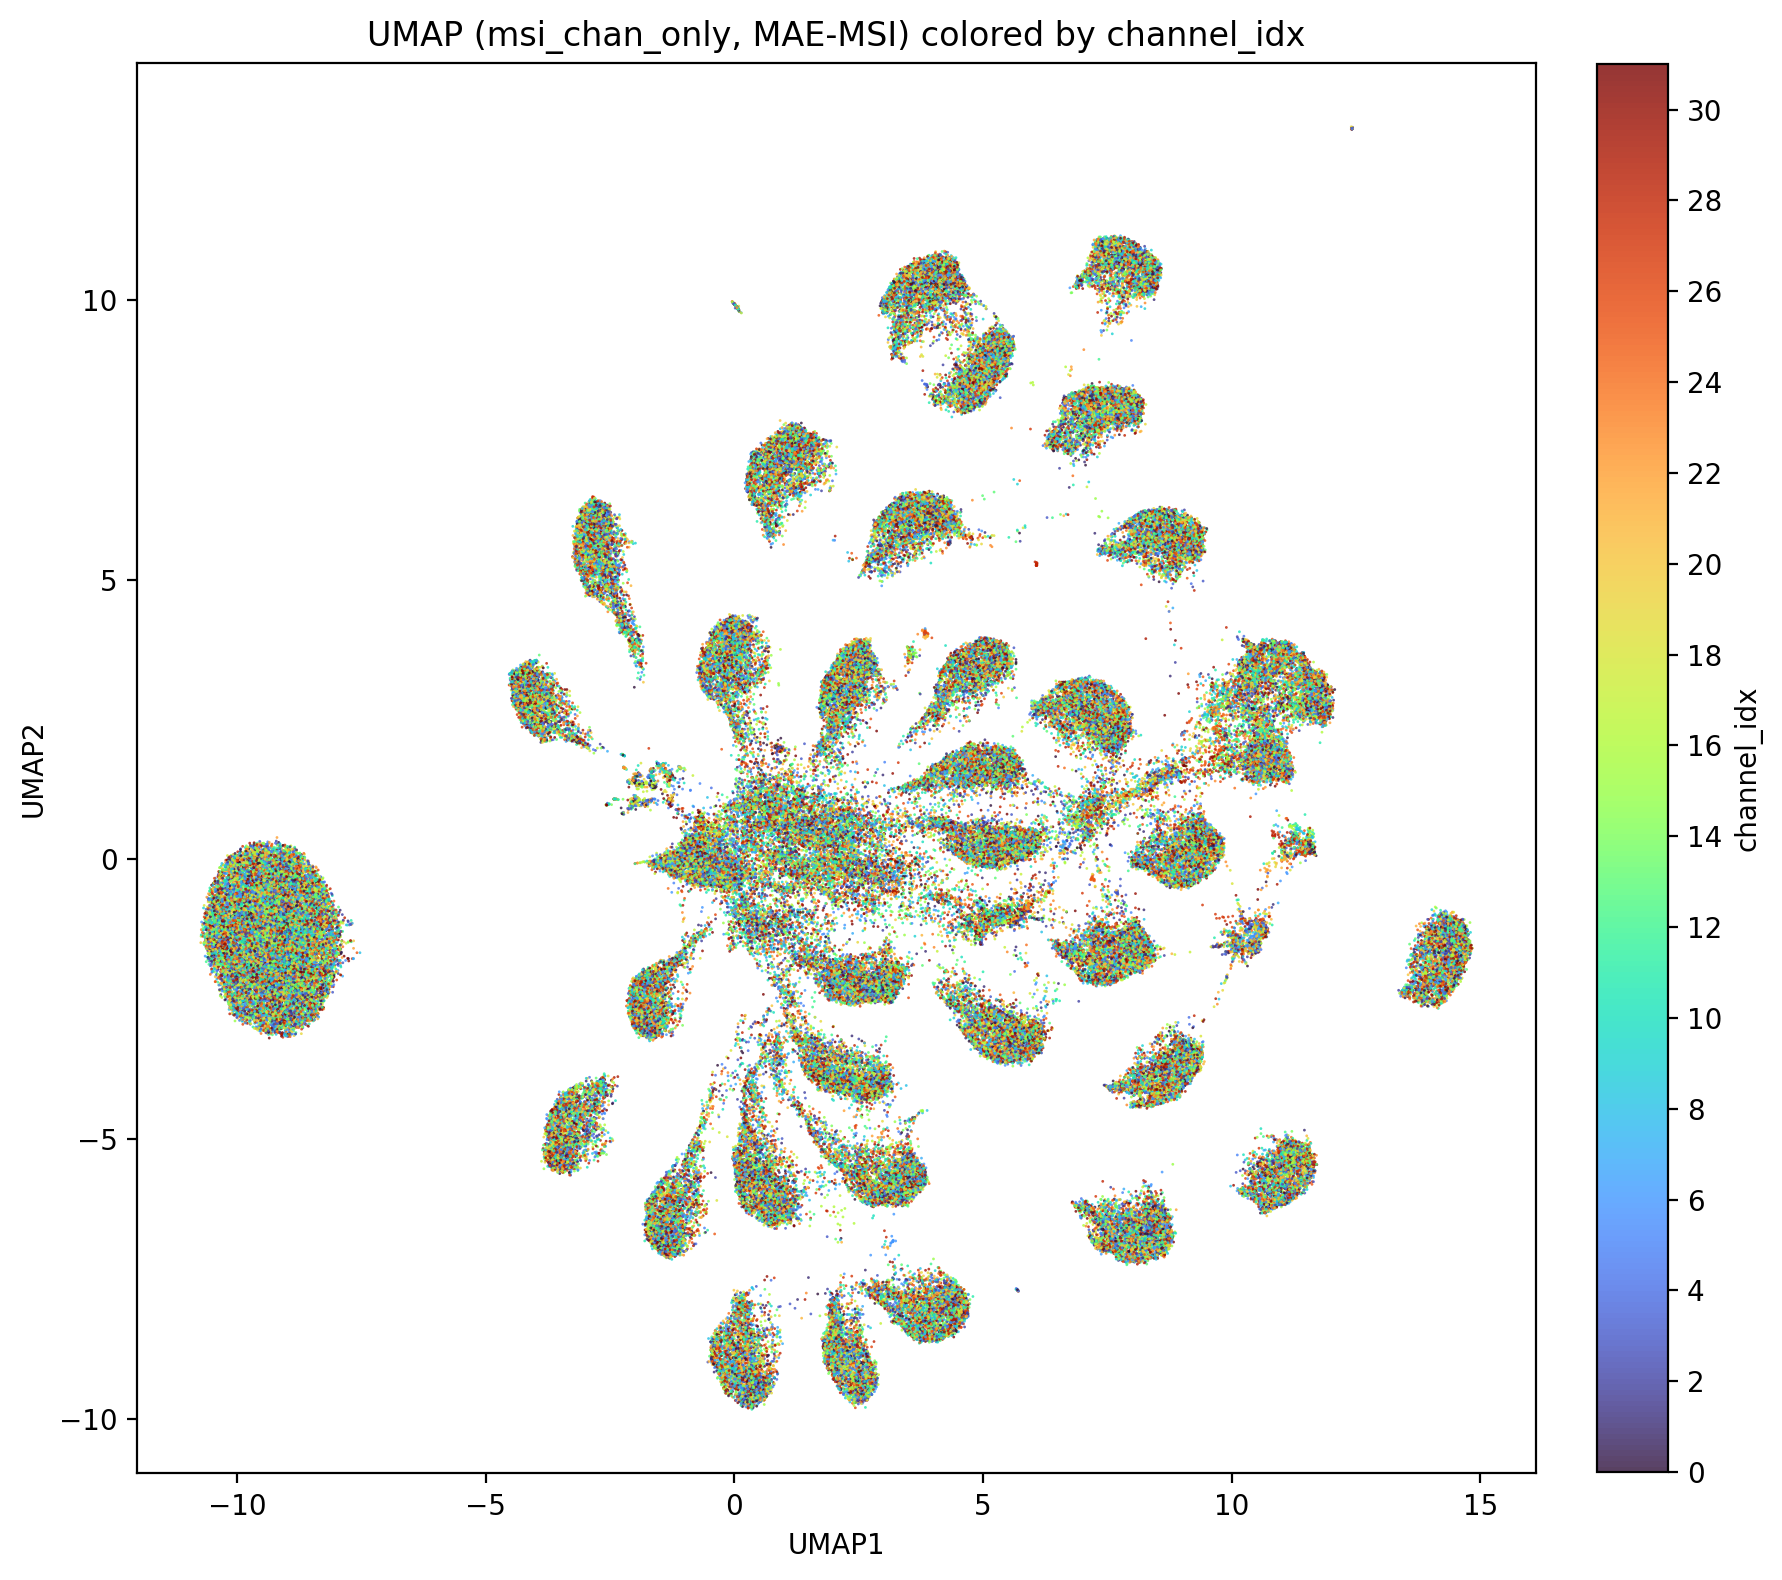

[OK] saved: spatial_metabolomics_atlas\benchmarks\umap\msi_chan_only\MAE-MSI\umap__colored_by_channel_idx.png
[INFO] points: 157,847 | channel_idx unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


In [1]:
# ============================================================
# PLOT: msi_chan_only UMAP colored by channel_idx
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG
# -------------------------
REP = "MAE-MSI"  # one of: "PCA", "MAE-RandInit", "MAE-ImageNet", "MAE-MSI"
VARIANT = "msi_chan_only"

BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"

ATLAS = Path("spatial_metabolomics_atlas")
UMAP_DIR = ATLAS / "benchmarks" / "umap" / VARIANT / REP
COORDS_CSV = UMAP_DIR / "umap_coords.csv"

OUT_PNG = UMAP_DIR / "umap__colored_by_channel_idx.png"

# columns
CHAN_IDX_COL = "channel_idx"

# plotting
POINT_SIZE = 1.0        # increase if you want bigger dots
ALPHA = 0.8             # lower if it looks too dense
RASTERIZED = True       # makes huge scatters export faster

# -------------------------
# LOAD
# -------------------------
if not COORDS_CSV.exists():
    raise FileNotFoundError(f"Missing UMAP coords: {COORDS_CSV}")

if not CHAN_PQ.exists():
    raise FileNotFoundError(f"Missing channels parquet: {CHAN_PQ}")

coords = pd.read_csv(COORDS_CSV)
if not {"row_id", "umap1", "umap2"}.issubset(coords.columns):
    raise KeyError(f"coords missing required cols. Found: {list(coords.columns)}")

ch_df = pd.read_parquet(CHAN_PQ).reset_index(drop=True)
if CHAN_IDX_COL not in ch_df.columns:
    raise KeyError(f"channels parquet missing {CHAN_IDX_COL!r}. Found: {list(ch_df.columns)}")

# -------------------------
# MAP row_id -> channel_idx
# -------------------------
row_ids = coords["row_id"].to_numpy(np.int64, copy=False)

# IMPORTANT: your row_ids are iloc indices into ch_df
chan_idx = ch_df.iloc[row_ids][CHAN_IDX_COL].to_numpy()

# If any NaNs (shouldn't), drop them
mask_ok = np.isfinite(chan_idx)
if not np.all(mask_ok):
    coords = coords.loc[mask_ok].reset_index(drop=True)
    chan_idx = chan_idx[mask_ok]

chan_idx = chan_idx.astype(int)

# -------------------------
# PLOT
# -------------------------
x = coords["umap1"].to_numpy(np.float32, copy=False)
y = coords["umap2"].to_numpy(np.float32, copy=False)

fig, ax = plt.subplots(figsize=(9, 8), dpi=200)

sc = ax.scatter(
    x, y,
    c=chan_idx,
    s=POINT_SIZE,
    alpha=ALPHA,
    linewidths=0,
    cmap="turbo",          # good discrete-ish separation; switch to "viridis" if you prefer
    rasterized=RASTERIZED,
)

ax.set_title(f"UMAP ({VARIANT}, {REP}) colored by channel_idx")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("channel_idx")

# Make ticks nice for 0..31 if that’s your C
uniq = np.unique(chan_idx)
if uniq.min() >= 0 and uniq.max() <= 31:
    cbar.set_ticks(list(range(0, 32, 2)))  # every 2 channels

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
plt.show()

print(f"[OK] saved: {OUT_PNG}")
print(f"[INFO] points: {len(coords):,} | channel_idx unique: {np.unique(chan_idx)}")

### Dataset overview

In [3]:
# ============================================================
# HMDB OVERVIEW (FULL PIPELINE)
#
# Computes HMDB taxonomy labels from candidate CIDs
# + caches results
# + plots LOG-SCALE Top-K count barplots
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"
HMDB_PQ = BASE / "molformer_pubchem_index_enriched_semantic.parquet"

OUT_ROOT = Path("spatial_metabolomics_atlas/benchmarks/hmdb_overview")
OUT_ROOT.mkdir(parents=True, exist_ok=True)
HMDB_CACHE_DIR = OUT_ROOT / "_hmdb_cache"
HMDB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
FIELDS = ["kingdom", "super_class", "class", "sub_class", "direct_parent"]

CAND_CIDS_COL = "cand_pubchem_cids"
UNKNOWN_LABEL = "unknown"
TOPK = 8

UNKNOWN_SET = {"unknown", "nan", "", "None", "none", "NaN"}

# ------------------------------------------------------------
# CID PARSING
# ------------------------------------------------------------
_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []

    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s:
            return []
        toks = re.split(r"[;,|]\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    return list(dict.fromkeys(out))  # unique preserve order

# ------------------------------------------------------------
# HMDB TAXONOMY PARSE
# ------------------------------------------------------------
def _hmdb_tag(tax_str, key: str, default=UNKNOWN_LABEL) -> str:
    if tax_str is None:
        return default

    key_l = key.lower()
    for part in str(tax_str).split(";"):
        part = part.strip()
        if part.lower().startswith(key_l + ":"):
            val = part.split(":", 1)[1].strip()
            return val if val else default
    return default

def build_cid_to_taxonomy(pq_path: Path) -> dict[str, str]:
    df = pd.read_parquet(pq_path, columns=["cid", "hmdb_taxonomy"])
    df["cid_norm"] = df["cid"].astype(str).map(normalize_cid)

    mapping = {}
    for cid, tax in zip(df["cid_norm"], df["hmdb_taxonomy"]):
        if cid and cid not in mapping:
            mapping[cid] = tax
    return mapping

def majority_vote(tags: list[str]) -> str:
    return pd.Series(tags).value_counts().index[0]

def label_row(cids_field, field, cid_to_tax):
    cids = parse_cids_field(cids_field)
    if not cids:
        return UNKNOWN_LABEL

    tags = []
    for cid in cids:
        tax = cid_to_tax.get(cid)
        if tax is None:
            continue
        tag = _hmdb_tag(tax, field)
        if tag != UNKNOWN_LABEL:
            tags.append(tag)

    if not tags:
        return UNKNOWN_LABEL

    return majority_vote(tags)

# ------------------------------------------------------------
# COMPUTE OR LOAD CACHE
# ------------------------------------------------------------
def compute_or_load_labels(ch_df, cid_to_tax, field):
    cache_file = HMDB_CACHE_DIR / f"hmdb__{field}.csv"

    if cache_file.exists():
        print(f"[LOAD CACHE] {field}")
        return pd.read_csv(cache_file)["label"]

    print(f"[COMPUTE] {field}")

    labels = []
    for val in tqdm(ch_df[CAND_CIDS_COL].values, desc=field):
        labels.append(label_row(val, field, cid_to_tax))

    labels = pd.Series(labels, name="label")
    pd.DataFrame({"row_id": np.arange(len(labels)), "label": labels}).to_csv(cache_file, index=False)
    return labels

# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------
def plot_log_bar(labels, field):
    labels = labels.astype(str).str.strip()
    labels = labels[~labels.isin(UNKNOWN_SET)]

    vc = labels.value_counts()

    if len(vc) == 0:
        print("[SKIP EMPTY]", field)
        return

    top = vc.head(TOPK).sort_values()

    # ---------------- STYLE ----------------
    TITLE_SIZE = 22
    AXIS_SIZE = 18
    TICK_SIZE = 15

    plt.figure()

    # thicker bars
    plt.barh(range(len(top)), top.values, height=0.75)

    # ticks
    plt.yticks(range(len(top)), top.index, fontsize=TICK_SIZE)
    plt.xticks(fontsize=TICK_SIZE)

    plt.xscale("log")
    plt.xlabel("Count (log scale)", fontsize=AXIS_SIZE)
    plt.title(f"HMDB {field}", fontsize=TITLE_SIZE, pad=14)

    plt.tight_layout()

    # extra margin so long names fit
    plt.subplots_adjust(left=0.42, right=0.98, top=0.90, bottom=0.10)

    out = OUT_ROOT / f"topK_bar_count_log__{field}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0.0)
    plt.close()

    print("[SAVED]", out)

# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------
def main():
    if not CHAN_PQ.exists():
        raise FileNotFoundError(CHAN_PQ)
    if not HMDB_PQ.exists():
        raise FileNotFoundError(HMDB_PQ)

    print("[LOAD] channels")
    ch_df = pd.read_parquet(CHAN_PQ, columns=[CAND_CIDS_COL])

    print("[BUILD] CID → taxonomy map")
    cid_to_tax = build_cid_to_taxonomy(HMDB_PQ)
    print("entries:", len(cid_to_tax))

    for field in FIELDS:
        labels = compute_or_load_labels(ch_df, cid_to_tax, field)
        plot_log_bar(labels, field)

    print("\nDONE — figures saved in:")
    print(OUT_ROOT.resolve())

if __name__ == "__main__":
    main()


[LOAD] channels
[BUILD] CID → taxonomy map
entries: 30478
[LOAD CACHE] kingdom
[SAVED] spatial_metabolomics_atlas\benchmarks\hmdb_overview\topK_bar_count_log__kingdom.png
[LOAD CACHE] super_class
[SAVED] spatial_metabolomics_atlas\benchmarks\hmdb_overview\topK_bar_count_log__super_class.png
[LOAD CACHE] class
[SAVED] spatial_metabolomics_atlas\benchmarks\hmdb_overview\topK_bar_count_log__class.png
[LOAD CACHE] sub_class
[SAVED] spatial_metabolomics_atlas\benchmarks\hmdb_overview\topK_bar_count_log__sub_class.png
[LOAD CACHE] direct_parent
[SAVED] spatial_metabolomics_atlas\benchmarks\hmdb_overview\topK_bar_count_log__direct_parent.png

DONE — figures saved in:
\\bme-data2.ad.gatech.edu\labs6\coskun-lab\Efe\MSI Foundation Model\spatial_metabolomics_atlas\benchmarks\hmdb_overview


### MetaboFM vs other models

In [28]:
# ============================================================
# MetaboFM dataset overview (for table/graph) — FULL EDITED
#
# UPDATE (your request):
#   ✅ Instead of "coverage %" prints, report:
#      - #distinct molecules (from cand_names in channels pq)
#      - #distinct HMDB super_class labels (known only; from ALLROWS cache)
#      - #distinct HMDB class labels (known only; from ALLROWS cache)
#
# Still computes:
#   - #datasets, #tiles, #tile-channel pairs, #unique m/z (+ range)
#   - candidate CID rows count
#   - total pixels and total pixel-channels from meta.csv
#
# Outputs:
#   - spatial_metabolomics_atlas/benchmarks/hmdb/dataset_overview.csv
#   - prints a compact "copy-paste" summary block
# ============================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# -------------------------
# PATHS
# -------------------------
BASE = Path("metaspace_images_dump")
CHAN_PQ = BASE / "channels_with_candidates.parquet"
HMDB_PQ = BASE / "molformer_pubchem_index_enriched_semantic.parquet"  # not directly needed here, kept for sanity

ATLAS = Path("spatial_metabolomics_atlas")
OUT_ROOT = ATLAS / "benchmarks" / "hmdb"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_ROOT / "dataset_overview.csv"

MSI_DIR = Path("msi-vitmae_REBUILT2/embeddings")
MSI_META_CSV = MSI_DIR / "meta.csv"

HMDB_CACHE_DIR = OUT_ROOT / "_hmdb_cache"

# -------------------------
# CONFIG
# -------------------------
DATASET_COL   = "dataset_id"
TILE_R_COL    = "tile_r"
TILE_C_COL    = "tile_c"
TILE_H_COL    = "tile_h"
TILE_W_COL    = "tile_w"
META_CHAN_COL = "channels"

CHAN_IDX_COL  = "channel_idx"
MZ_COL        = "mz"
CAND_CIDS_COL = "cand_pubchem_cids"
CAND_NAMES_COL = "cand_names"  # <-- REQUIRED for distinct molecule counts

HMDB_FIELDS = ["super_class", "class"]
UNKNOWN_LABEL = "unknown"

_CID_RE = re.compile(r"\bCID\s*0*([0-9]+)\b", flags=re.IGNORECASE)

def normalize_cid(x) -> str | None:
    if x is None:
        return None
    s = str(x).strip()
    if not s or s.lower() in {"none", "nan"}:
        return None
    m = _CID_RE.search(s)
    if m:
        return f"CID{int(m.group(1))}"
    if s.isdigit():
        return f"CID{int(s)}"
    return None

def parse_cids_field(cand_pubchem_cids) -> list[str]:
    if cand_pubchem_cids is None:
        return []
    if isinstance(cand_pubchem_cids, (list, tuple, np.ndarray)):
        toks = list(cand_pubchem_cids)
    else:
        s = str(cand_pubchem_cids).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        toks = re.split(r"[;,|]\s*|\s+\|\s+|\s*;\s*", s)

    out = []
    for t in toks:
        cid = normalize_cid(t)
        if cid:
            out.append(cid)

    # uniq preserve
    seen, uniq = set(), []
    for cid in out:
        if cid not in seen:
            uniq.append(cid)
            seen.add(cid)
    return uniq

def parse_molecule_names_field(x) -> list[str]:
    """
    Parses cand_names (string or list) into a list of cleaned molecule names.
    Keeps order, de-duplicates.
    """
    if x is None:
        return []
    if isinstance(x, (list, tuple, np.ndarray)):
        toks = [str(t).strip() for t in list(x)]
    else:
        s = str(x).strip()
        if not s or s.lower() in {"none", "nan"}:
            return []
        # cand_names often uses ';' as separator (as in your logs); also handle pipes/commas
        toks = re.split(r"\s*;\s*|\s*\|\s*|\s*,\s*", s)

    out = []
    for t in toks:
        t = str(t).strip()
        if not t or t.lower() in {"none", "nan"}:
            continue
        out.append(t)

    # uniq preserve
    seen, uniq = set(), []
    for name in out:
        if name not in seen:
            uniq.append(name)
            seen.add(name)
    return uniq

def load_cached_allrows_labels(cache_dir: Path, field: str, n_rows: int) -> np.ndarray:
    cache_csv = cache_dir / f"hmdb__{field}__ALLROWS.csv"
    if not cache_csv.exists():
        raise FileNotFoundError(
            f"Missing HMDB cache for field='{field}': {cache_csv}\n"
            f"Run your HMDB benchmark script once to generate it."
        )
    df = pd.read_csv(cache_csv)
    m = dict(zip(df["row_id"].astype(np.int64).values, df["label"].astype(str).values))
    labels = np.array([m.get(int(i), UNKNOWN_LABEL) for i in range(n_rows)], dtype=object).astype(str)
    return labels

def safe_read_parquet_cols(path: Path, cols: list[str]) -> pd.DataFrame:
    return pd.read_parquet(path, columns=cols).reset_index(drop=True)

def main():
    # ---- sanity
    for p in [CHAN_PQ, HMDB_PQ, MSI_META_CSV]:
        if not p.exists():
            raise FileNotFoundError(f"Missing: {p}")

    # ---- load channels pq
    print("[LOAD] channels_with_candidates.parquet (minimal cols)")
    ch_cols = [DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL, MZ_COL, CAND_CIDS_COL, CAND_NAMES_COL]
    ch = safe_read_parquet_cols(CHAN_PQ, ch_cols)

    ch[DATASET_COL] = ch[DATASET_COL].astype(str)
    ch[TILE_R_COL] = pd.to_numeric(ch[TILE_R_COL], errors="raise").astype(int)
    ch[TILE_C_COL] = pd.to_numeric(ch[TILE_C_COL], errors="raise").astype(int)
    ch[CHAN_IDX_COL] = pd.to_numeric(ch[CHAN_IDX_COL], errors="raise").astype(int)

    n_rows = int(len(ch))

    # ---- dataset / tile / channel instance counts
    ds_ids = ch[DATASET_COL].unique()
    n_datasets = int(len(ds_ids))

    tiles_ch = ch[[DATASET_COL, TILE_R_COL, TILE_C_COL]].drop_duplicates()
    n_tiles_from_ch = int(len(tiles_ch))

    chan_instances = ch[[DATASET_COL, TILE_R_COL, TILE_C_COL, CHAN_IDX_COL]].drop_duplicates()
    n_chan_instances = int(len(chan_instances))

    n_unique_channel_idx = int(ch[CHAN_IDX_COL].nunique())

    # ---- mz stats
    mz = pd.to_numeric(ch[MZ_COL], errors="coerce").astype(float)
    mz_valid = mz[np.isfinite(mz.to_numpy())]
    n_mz = int(mz_valid.shape[0])
    n_unique_mz = int(pd.Series(mz_valid).round(6).nunique()) if n_mz else 0
    mz_min = float(np.nanmin(mz_valid)) if n_mz else float("nan")
    mz_max = float(np.nanmax(mz_valid)) if n_mz else float("nan")

    # ---- candidate CID rows count
    print("[STATS] candidate CID rows")
    has_cand = np.array(
        [len(parse_cids_field(x)) > 0 for x in tqdm(ch[CAND_CIDS_COL].values, desc="parse CIDs")],
        dtype=bool
    )
    n_has_cand = int(has_cand.sum())

    # ---- distinct molecules from cand_names
    print("[STATS] distinct molecules (from cand_names)")
    cand_lists = [parse_molecule_names_field(x) for x in tqdm(ch[CAND_NAMES_COL].values, desc="parse cand_names")]
    primary_names = [lst[0] for lst in cand_lists if len(lst) > 0]
    all_names = [nm for lst in cand_lists for nm in lst]

    n_distinct_molecules_primary = int(pd.Series(primary_names, dtype="object").nunique()) if primary_names else 0
    n_distinct_molecules_allcands = int(pd.Series(all_names, dtype="object").nunique()) if all_names else 0

    # ---- read meta.csv for tile universe + pixel totals
    print("[LOAD] meta.csv")
    meta = pd.read_csv(MSI_META_CSV)

    required_meta_cols = [DATASET_COL, TILE_R_COL, TILE_C_COL, TILE_H_COL, TILE_W_COL, META_CHAN_COL]
    missing = [c for c in required_meta_cols if c not in meta.columns]
    if missing:
        raise KeyError(f"meta.csv missing required column(s): {missing}")

    meta[DATASET_COL] = meta[DATASET_COL].astype(str)
    meta[TILE_R_COL] = pd.to_numeric(meta[TILE_R_COL], errors="raise").astype(int)
    meta[TILE_C_COL] = pd.to_numeric(meta[TILE_C_COL], errors="raise").astype(int)
    meta[TILE_H_COL] = pd.to_numeric(meta[TILE_H_COL], errors="coerce").astype("Int64")
    meta[TILE_W_COL] = pd.to_numeric(meta[TILE_W_COL], errors="coerce").astype("Int64")
    meta[META_CHAN_COL] = pd.to_numeric(meta[META_CHAN_COL], errors="coerce").astype("Int64")

    tiles_meta = meta[[DATASET_COL, TILE_R_COL, TILE_C_COL]].drop_duplicates()
    n_tiles_from_meta = int(len(tiles_meta))
    n_datasets_meta = int(meta[DATASET_COL].nunique())
    ds_overlap = int(len(set(ds_ids).intersection(set(meta[DATASET_COL].unique()))))

    # ---- pixel totals (sum over UNIQUE tiles in meta.csv)
    meta_tiles = (
        meta[[DATASET_COL, TILE_R_COL, TILE_C_COL, TILE_H_COL, TILE_W_COL, META_CHAN_COL]]
        .drop_duplicates(subset=[DATASET_COL, TILE_R_COL, TILE_C_COL])
        .copy()
    )

    valid_hw = meta_tiles[TILE_H_COL].notna() & meta_tiles[TILE_W_COL].notna()
    valid_hw_chan = valid_hw & meta_tiles[META_CHAN_COL].notna()

    meta_tiles["tile_pixels"] = np.nan
    meta_tiles.loc[valid_hw, "tile_pixels"] = (
        meta_tiles.loc[valid_hw, TILE_H_COL].astype("int64").to_numpy()
        * meta_tiles.loc[valid_hw, TILE_W_COL].astype("int64").to_numpy()
    )

    meta_tiles["tile_pixel_channels"] = np.nan
    meta_tiles.loc[valid_hw_chan, "tile_pixel_channels"] = (
        meta_tiles.loc[valid_hw_chan, "tile_pixels"].astype("float64").to_numpy()
        * meta_tiles.loc[valid_hw_chan, META_CHAN_COL].astype("int64").to_numpy()
    )

    n_tiles_with_hw = int(valid_hw.sum())
    total_pixels = int(np.nansum(meta_tiles["tile_pixels"].to_numpy()))
    total_pixel_channels = int(np.nansum(meta_tiles["tile_pixel_channels"].to_numpy()))

    # ---- HMDB distinct label counts (known only) from caches
    hmdb_rows = {}
    for field in HMDB_FIELDS:
        print(f"[LOAD] HMDB cached ALLROWS labels: {field}")
        lab = load_cached_allrows_labels(HMDB_CACHE_DIR, field=field, n_rows=n_rows)
        known = (lab != UNKNOWN_LABEL) & (lab != "") & (lab != "nan")
        hmdb_rows[field] = {
            "n_known_rows": int(known.sum()),
            "n_unique_labels_known": int(pd.Series(lab[known]).nunique()) if known.any() else 0,
            "top5_labels": pd.Series(lab[known]).value_counts().head(5).to_dict() if known.any() else {},
        }

    # ---- meta diversity (optional)
    def count_unique_if_present(col: str) -> int | None:
        if col in meta.columns:
            return int(meta[col].astype(str).nunique())
        return None

    diversity = {
        "organism": count_unique_if_present("organism"),
        "Organism_Part": count_unique_if_present("Organism_Part"),
        "Condition": count_unique_if_present("Condition"),
        "polarity": count_unique_if_present("polarity") if "polarity" in meta.columns else (
            count_unique_if_present("ion_polarity") if "ion_polarity" in meta.columns else None
        ),
        "analyzerType": count_unique_if_present("analyzerType"),
        "ionisationSource": count_unique_if_present("ionisationSource"),
    }

    # ---- one-row overview CSV (no % fields; distinct counts instead)
    overview = {
        "n_rows_channels_parquet": n_rows,
        "n_datasets_from_channels_parquet": n_datasets,
        "n_tiles_from_channels_parquet": n_tiles_from_ch,
        "n_tiles_from_meta_csv": n_tiles_from_meta,
        "n_datasets_from_meta_csv": n_datasets_meta,
        "n_datasets_overlap_meta_vs_channels": ds_overlap,
        "n_channel_instances_tile_channelidx": n_chan_instances,
        "n_unique_channel_idx_values": n_unique_channel_idx,
        "n_mz_values_valid": n_mz,
        "n_unique_mz_rounded6": n_unique_mz,
        "mz_min": mz_min,
        "mz_max": mz_max,
        "n_rows_with_candidate_cid": n_has_cand,
        # ✅ distinct molecules
        "n_distinct_molecules_primary": n_distinct_molecules_primary,
        "n_distinct_molecules_all_candidates": n_distinct_molecules_allcands,
        # ✅ pixel totals
        "n_unique_tiles_meta_for_pixels": int(len(meta_tiles)),
        "n_tiles_with_tile_h_w_present": n_tiles_with_hw,
        "total_pixels_sum_tile_h_x_tile_w": total_pixels,
        "total_pixel_channels_sum_tile_h_x_tile_w_x_channels": total_pixel_channels,
        # ✅ HMDB distinct labels (known only)
        "hmdb_super_class_n_known_rows": hmdb_rows["super_class"]["n_known_rows"],
        "hmdb_super_class_n_distinct_labels_known": hmdb_rows["super_class"]["n_unique_labels_known"],
        "hmdb_class_n_known_rows": hmdb_rows["class"]["n_known_rows"],
        "hmdb_class_n_distinct_labels_known": hmdb_rows["class"]["n_unique_labels_known"],
        # diversity
        "n_unique_organism": diversity["organism"],
        "n_unique_organism_part": diversity["Organism_Part"],
        "n_unique_condition": diversity["Condition"],
        "n_unique_polarity": diversity["polarity"],
        "n_unique_analyzerType": diversity["analyzerType"],
        "n_unique_ionisationSource": diversity["ionisationSource"],
    }

    df_out = pd.DataFrame([overview])
    df_out.to_csv(OUT_CSV, index=False)
    print("[OK] wrote:", OUT_CSV)

    # ---- copy/paste block
    print("\n==================== DATASET OVERVIEW (COPY/PASTE) ====================")
    print(f"#datasets (channels pq): {n_datasets:,}")
    print(f"#tiles (meta.csv):       {n_tiles_from_meta:,}")
    print(f"#tiles (channels pq):    {n_tiles_from_ch:,}")
    print(f"#tile-channel pairs:     {n_chan_instances:,}")
    print(f"#unique m/z (rounded6):  {n_unique_mz:,}   (range: {mz_min:.4f} – {mz_max:.4f})")

    print("\n--- molecules (from cand_names) ---")
    print(f"#distinct molecules (primary=1st candidate per row): {n_distinct_molecules_primary:,}")
    print(f"#distinct molecules (all candidates union):         {n_distinct_molecules_allcands:,}")

    print("\n--- candidate CID rows ---")
    print(f"rows with ≥1 CID candidate: {n_has_cand:,}/{n_rows:,}")

    print("\n--- pixel totals (from meta.csv) ---")
    print(f"#unique tiles used:      {len(meta_tiles):,}")
    print(f"tiles with tile_h/w:     {n_tiles_with_hw:,}/{len(meta_tiles):,}")
    print(f"TOTAL PIXELS (Σ H×W):    {total_pixels:,}")
    print(f"TOTAL PIXEL-CHANNELS:    {total_pixel_channels:,}   (Σ H×W×channels)")

    print("\n--- HMDB labels (from cached ALLROWS; known only) ---")
    for field in HMDB_FIELDS:
        r = hmdb_rows[field]
        print(f"HMDB {field}: #distinct labels={r['n_unique_labels_known']:,} | known rows={r['n_known_rows']:,}/{n_rows:,}")
        if r["top5_labels"]:
            top = ", ".join([f"{k} ({v})" for k, v in list(r["top5_labels"].items())])
            print(f"  top5: {top}")

    print("\n--- meta.csv diversity (if present) ---")
    for k, v in diversity.items():
        if v is not None:
            print(f"{k}: {v:,}")
    print("=======================================================================\n")

if __name__ == "__main__":
    main()

[LOAD] channels_with_candidates.parquet (minimal cols)
[STATS] candidate CID rows


parse CIDs:   0%|          | 0/164359 [00:00<?, ?it/s]

[STATS] distinct molecules (from cand_names)


parse cand_names:   0%|          | 0/164359 [00:00<?, ?it/s]

[LOAD] meta.csv
[LOAD] HMDB cached ALLROWS labels: super_class
[LOAD] HMDB cached ALLROWS labels: class
[OK] wrote: spatial_metabolomics_atlas\benchmarks\hmdb\dataset_overview.csv

==================== DATASET OVERVIEW (COPY/PASTE) ====================
#datasets (channels pq): 5,811
#tiles (meta.csv):       5,811
#tiles (channels pq):    5,811
#tile-channel pairs:     164,359
#unique m/z (rounded6):  11,798   (range: 51.0007 – 2957.9504)

--- molecules (from cand_names) ---
#distinct molecules (primary=1st candidate per row): 4,597
#distinct molecules (all candidates union):         27,407

--- candidate CID rows ---
rows with ≥1 CID candidate: 157,847/164,359

--- pixel totals (from meta.csv) ---
#unique tiles used:      5,811
tiles with tile_h/w:     5,811/5,811
TOTAL PIXELS (Σ H×W):    280,499,132
TOTAL PIXEL-CHANNELS:    7,657,136,093   (Σ H×W×channels)

--- HMDB labels (from cached ALLROWS; known only) ---
HMDB super_class: #distinct labels=18 | known rows=144,690/164,359
  top5: 

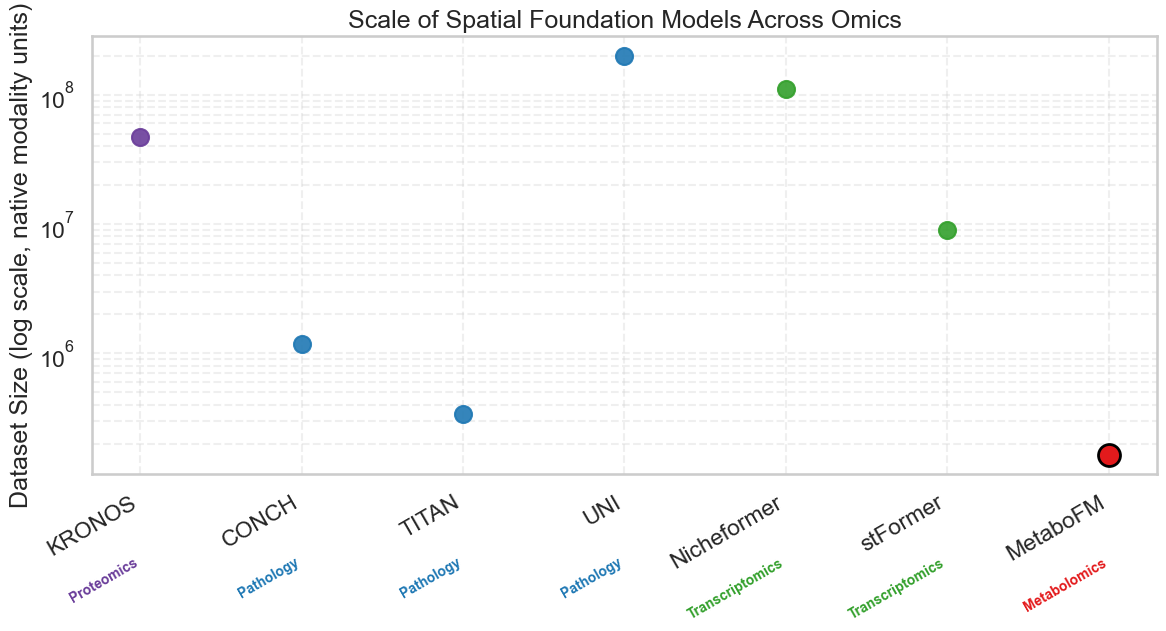

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# DATA
# -----------------------------
models = [
    "KRONOS",
    "CONCH",
    "TITAN",
    "UNI",
    "Nicheformer",
    "stFormer",
    "MetaboFM"
]

sizes = [
    47_000_000,
    1_170_000,
    335_645,
    200_000_000,
    110_000_000,
    9_000_000,
    164_359
]

domains = [
    "Proteomics",
    "Pathology",
    "Pathology",
    "Pathology",
    "Transcriptomics",
    "Transcriptomics",
    "Metabolomics"
]

domain_colors = {
    "Proteomics": "#6a3d9a",
    "Pathology": "#1f78b4",
    "Transcriptomics": "#33a02c",
    "Metabolomics": "#e31a1c"
}

colors = [domain_colors[d] for d in domains]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(13, 6))
x = np.arange(len(models))
y = np.array(sizes)

# Scatter points
for i in range(len(models)):
    if "MetaboFM" in models[i]:
        plt.scatter(x[i], y[i], s=250, color=colors[i],
                    edgecolor='black', linewidth=2, zorder=5)
    else:
        plt.scatter(x[i], y[i], s=150, color=colors[i], alpha=0.9)

plt.yscale("log")

# Model names as main x labels
plt.xticks(x, models, rotation=30, ha='right')

ax = plt.gca()

# Add domain text UNDER each model label
ymin = min(y)
offset = ymin / 6  # controls vertical spacing for domain label

for i, domain in enumerate(domains):
    ax.text(
        x[i],
        offset,
        domain,
        color=domain_colors[domain],
        fontsize=10,
        ha='right',
        va='top',
        rotation=30,
        fontweight='bold'
    )

plt.ylabel("Dataset Size (log scale, native modality units)")
plt.title("Scale of Spatial Foundation Models Across Omics")

plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(left=0.16, bottom=0.18)
plt.show()

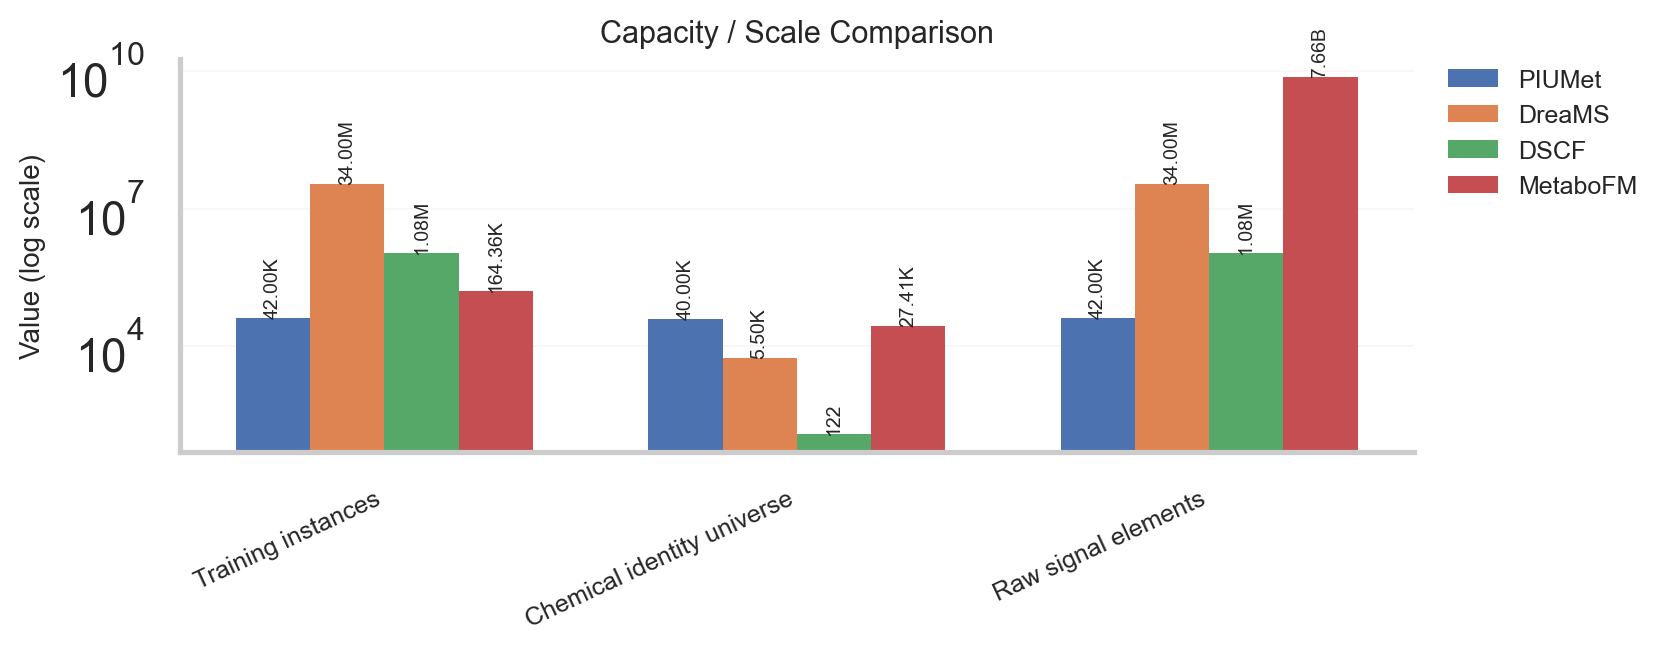

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FINAL (PAPER-READY) CAPACITY / SCALE COMPARISON
#   ✅ Only 3 fair metrics (defined for ALL models; no NaNs):
#     1) Training instances
#     2) Chemical identity universe
#     3) Raw signal elements
#
#   ✅ Log-scale grouped bar plot
#   ✅ Clean, Nature-ish styling (no heavy grids, minimal spines)
#   ✅ Rotated x-ticks
#   ✅ Legend outside
#   ✅ Value annotations (compact)
# ============================================================

MODELS = ["PIUMet", "DreaMS", "DSCF", "MetaboFM"]

# ----------------------------
# Metric 1: Training instances
# ----------------------------
# PIUMet: not a standard "instances" dataset; use PPMI nodes proxy (as before)
# DreaMS: subset of 34 million mass spectra (instances)
# DSCF: total spectra in paper (1,080,000) across modalities
# MetaboFM: tile-channel pairs (instances)
training_instances = np.array([
    42_000,       # PIUMet (proxy)
    34_000_000,   # DreaMS
    1_080_000,    # DSCF
    164_359       # MetaboFM
], dtype=float)

# ---------------------------------
# Metric 2: Chemical identity universe
# ---------------------------------
# PIUMet: HMDB metabolite universe (~40k)
# DreaMS: unique InChI connectivity blocks (5,500)
# DSCF: SERS metabolite dictionary: 122 metabolites (Supplementary Table 1)
# MetaboFM: distinct molecules (all candidates union)
chemical_universe = np.array([
    40_000,    # PIUMet
    5_500,     # DreaMS
    122,       # DSCF
    27_407     # MetaboFM
], dtype=float)

# ---------------------------------
# Metric 3: Raw signal elements
# ---------------------------------
# PIUMet: N/A (not raw spectral or pixel signal) -> use same proxy as E (nodes)
# DreaMS: treat as number of spectra (each is a signal) -> 34M
# DSCF: total spectra -> 1.08M
# MetaboFM: total pixel-channels (Σ H×W×channels) from your meta.csv output
raw_signal_elements = np.array([
    42_000,          # PIUMet (proxy)
    34_000_000,      # DreaMS
    1_080_000,       # DSCF
    7_657_136_093    # MetaboFM (your computed TOTAL PIXEL-CHANNELS)
], dtype=float)

# ---------------------------------
# Metrics to plot (ONLY THESE 3)
# ---------------------------------
METRICS = {
    "Training instances": training_instances,
    "Chemical identity universe": chemical_universe,
    "Raw signal elements": raw_signal_elements,
}

# ----------------------------
# Helpers
# ----------------------------
def fmt_human(n: float) -> str:
    if not np.isfinite(n) or n <= 0:
        return "n/a"
    if n >= 1e12:
        return f"{n/1e12:.2f}T"
    if n >= 1e9:
        return f"{n/1e9:.2f}B"
    if n >= 1e6:
        return f"{n/1e6:.2f}M"
    if n >= 1e3:
        return f"{n/1e3:.2f}K"
    return f"{n:.0f}"

# ============================================================
# PLOT
# ============================================================
metric_names = list(METRICS.keys())
n_metrics = len(metric_names)
n_models = len(MODELS)

x = np.arange(n_metrics)
width = 0.18

fig, ax = plt.subplots(figsize=(8.6, 3.6), dpi=200)

# Clean spines (Nature-ish)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Subtle y-grid only (very light)
ax.grid(True, which="both", axis="y", linewidth=0.6, alpha=0.18)
ax.grid(False, axis="x")

# Bars
for i, model in enumerate(MODELS):
    vals = np.array([METRICS[m][i] for m in metric_names], dtype=float)

    bars = ax.bar(
        x + (i - (n_models - 1) / 2) * width,
        vals,
        width,
        label=model,
        linewidth=0.0,
    )

    # Compact annotations (only if not too cramped)
    for b, v in zip(bars, vals):
        ax.text(
            b.get_x() + b.get_width() / 2,
            v,
            fmt_human(v),
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

# Log y-scale
ax.set_yscale("log")
ax.set_ylabel("Value (log scale)", fontsize=10)

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=25, ha="right", fontsize=9)

# Title (short)
ax.set_title("Capacity / Scale Comparison", fontsize=11, pad=6)

# Legend outside
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=9,
    borderaxespad=0.0
)

fig.tight_layout()
plt.show()

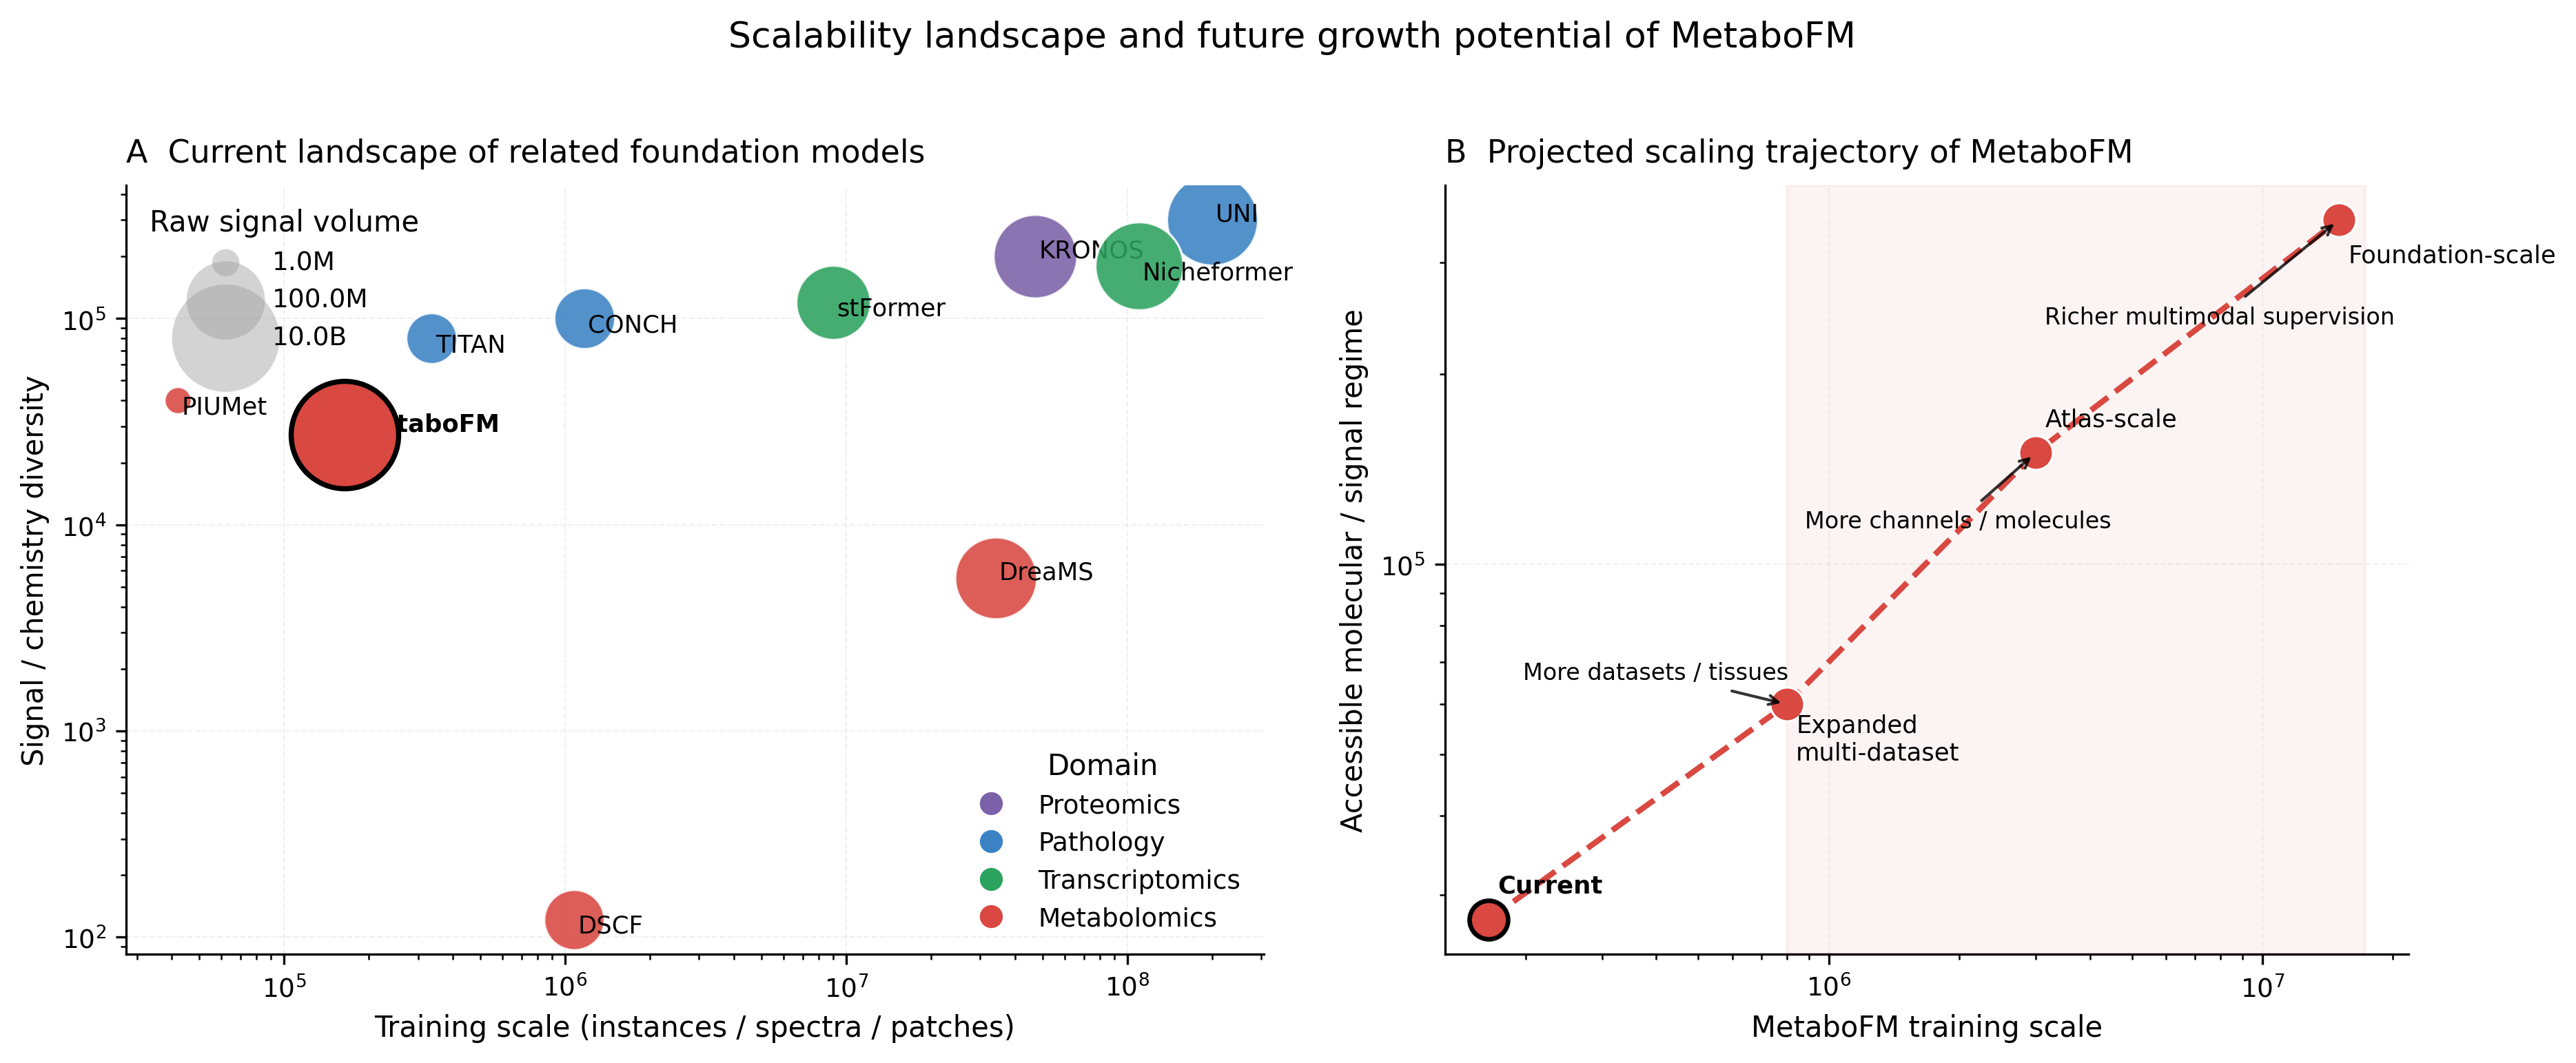

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# PAPER FIGURE:
#   Scalability landscape of related foundation models
#   + projected growth trajectory of MetaboFM
#
# FIGURE LAYOUT
#   Panel A: Current landscape (log-log scatter / bubble plot)
#   Panel B: MetaboFM scaling trajectory (current -> future)
#
# NOTES
#   - Replace example values with your final paper values if needed
#   - Panel B is intentionally framed as a conceptual/projected
#     scalability trajectory, not a measured future benchmark
# ============================================================

# ------------------------------------------------------------
# PANEL A: CURRENT LANDSCAPE
# ------------------------------------------------------------
models = [
    "PIUMet",
    "DreaMS",
    "DSCF",
    "KRONOS",
    "CONCH",
    "TITAN",
    "UNI",
    "Nicheformer",
    "stFormer",
    "MetaboFM"
]

domains = [
    "Metabolomics",
    "Metabolomics",
    "Metabolomics",
    "Proteomics",
    "Pathology",
    "Pathology",
    "Pathology",
    "Transcriptomics",
    "Transcriptomics",
    "Metabolomics"
]

# X-axis: training instances / samples / spectra / tile-channel pairs
training_instances = np.array([
    4.2e4,       # PIUMet
    3.4e7,       # DreaMS
    1.08e6,      # DSCF
    4.7e7,       # KRONOS
    1.17e6,      # CONCH
    3.35645e5,   # TITAN
    2.0e8,       # UNI
    1.1e8,       # Nicheformer
    9.0e6,       # stFormer
    1.64359e5    # MetaboFM
], dtype=float)

# Y-axis: chemical / signal diversity proxy
# For non-metabolomics models, this is a general “signal diversity / universe”
# type proxy. Keep wording broad in axis label for fairness.
signal_diversity = np.array([
    4.0e4,       # PIUMet chemical universe
    5.5e3,       # DreaMS unique connectivity blocks
    1.22e2,      # DSCF metabolite dictionary
    2.0e5,       # KRONOS proxy
    1.0e5,       # CONCH proxy
    8.0e4,       # TITAN proxy
    3.0e5,       # UNI proxy
    1.8e5,       # Nicheformer proxy
    1.2e5,       # stFormer proxy
    2.7407e4     # MetaboFM distinct molecules
], dtype=float)

# Bubble size: raw signal volume / total processed elements proxy
raw_signal_volume = np.array([
    4.2e4,          # PIUMet
    3.4e7,          # DreaMS
    1.08e6,         # DSCF
    4.7e7,          # KRONOS
    1.17e6,         # CONCH
    3.35645e5,      # TITAN
    2.0e8,          # UNI
    1.1e8,          # Nicheformer
    9.0e6,          # stFormer
    7.657136093e9   # MetaboFM total pixel-channels
], dtype=float)

domain_colors = {
    "Proteomics": "#7b61a8",
    "Pathology": "#3b82c4",
    "Transcriptomics": "#2ca25f",
    "Metabolomics": "#d94841",
}

# ------------------------------------------------------------
# PANEL B: METABOFM SCALING TRAJECTORY
# ------------------------------------------------------------
trajectory_labels = [
    "Current",
    "Expanded\nmulti-dataset",
    "Atlas-scale",
    "Foundation-scale"
]

# Example projected growth along x-axis:
# total training signal volume (or instances)
traj_x = np.array([
    1.64359e5,   # current
    8.0e5,       # ~5x
    3.0e6,       # ~18x
    1.5e7        # ~90x
], dtype=float)

# Example projected growth along y-axis:
# molecular / dataset / signal diversity regime
traj_y = np.array([
    2.7407e4,    # current distinct molecules
    6.0e4,
    1.5e5,
    3.5e5
], dtype=float)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def fmt_human(n: float) -> str:
    if n >= 1e12:
        return f"{n/1e12:.1f}T"
    if n >= 1e9:
        return f"{n/1e9:.1f}B"
    if n >= 1e6:
        return f"{n/1e6:.1f}M"
    if n >= 1e3:
        return f"{n/1e3:.1f}K"
    return f"{n:.0f}"

def scale_bubbles(values, min_size=90, max_size=1400):
    values = np.asarray(values, dtype=float)
    lv = np.log10(values)
    lv_min, lv_max = lv.min(), lv.max()
    if lv_max == lv_min:
        return np.full_like(lv, (min_size + max_size) / 2)
    scaled = (lv - lv_min) / (lv_max - lv_min)
    return min_size + scaled * (max_size - min_size)

bubble_sizes = scale_bubbles(raw_signal_volume)

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12.6, 5.2), dpi=300,
    gridspec_kw={"width_ratios": [1.18, 1.0]}
)

# ============================================================
# PANEL A
# ============================================================
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.18)
ax1.grid(False, which="minor")

for i, model in enumerate(models):
    color = domain_colors[domains[i]]
    is_metabofm = (model == "MetaboFM")

    ax1.scatter(
        training_instances[i],
        signal_diversity[i],
        s=bubble_sizes[i],
        color=color,
        alpha=0.88 if not is_metabofm else 1.0,
        edgecolor="black" if is_metabofm else "white",
        linewidth=1.8 if is_metabofm else 0.8,
        zorder=4 if is_metabofm else 3
    )

    # label placement
    if model == "MetaboFM":
        dx, dy = 1.10, 1.12
        weight = "bold"
    elif model in ["UNI", "DreaMS", "KRONOS"]:
        dx, dy = 1.03, 1.07
        weight = "normal"
    else:
        dx, dy = 1.03, 0.93
        weight = "normal"

    ax1.text(
        training_instances[i] * dx,
        signal_diversity[i] * dy,
        model,
        fontsize=8.5,
        ha="left",
        va="center",
        fontweight=weight
    )

ax1.set_xscale("log")
ax1.set_yscale("log")

ax1.set_xlabel("Training scale (instances / spectra / patches)")
ax1.set_ylabel("Signal / chemistry diversity")
ax1.set_title("A  Current landscape of related foundation models", loc="left", pad=8)

# Domain legend
domain_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=domain_colors[d], markeredgecolor='none',
           markersize=8, label=d)
    for d in ["Proteomics", "Pathology", "Transcriptomics", "Metabolomics"]
]

# Bubble size legend
size_legend_vals = [1e6, 1e8, 1e10]
size_legend_sizes = scale_bubbles(size_legend_vals)

size_handles = [
    plt.scatter([], [], s=s, color="#9e9e9e", alpha=0.45, edgecolor="none")
    for s in size_legend_sizes
]
size_labels = [fmt_human(v) for v in size_legend_vals]

leg1 = ax1.legend(
    handles=domain_handles,
    loc="lower right",
    frameon=False,
    title="Domain"
)
ax1.add_artist(leg1)

ax1.legend(
    size_handles,
    size_labels,
    scatterpoints=1,
    loc="upper left",
    frameon=False,
    title="Raw signal volume"
)

# ============================================================
# PANEL B
# ============================================================
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

ax2.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.18)
ax2.grid(False, which="minor")

# shaded future region
ax2.axvspan(traj_x[1], traj_x[-1] * 1.15, color="#d94841", alpha=0.06, zorder=0)

# dashed trajectory
ax2.plot(
    traj_x,
    traj_y,
    linestyle="--",
    linewidth=2.0,
    color="#d94841",
    zorder=2
)

# points
for i, (xv, yv, lab) in enumerate(zip(traj_x, traj_y, trajectory_labels)):
    ax2.scatter(
        xv,
        yv,
        s=180 if i == 0 else 140,
        color="#d94841",
        edgecolor="black" if i == 0 else "white",
        linewidth=1.6 if i == 0 else 0.8,
        zorder=3
    )

    ax2.text(
        xv * 1.05,
        yv * (1.13 if i % 2 == 0 else 0.88),
        lab,
        fontsize=8.5,
        ha="left",
        va="center",
        fontweight="bold" if i == 0 else "normal"
    )

# growth annotations
arrow_kw = dict(arrowstyle="->", lw=1.0, color="black", alpha=0.8)
ax2.annotate(
    "More datasets / tissues",
    xy=(traj_x[1], traj_y[1]),
    xytext=(traj_x[0] * 1.2, traj_y[0] * 2.4),
    arrowprops=arrow_kw,
    fontsize=8
)
ax2.annotate(
    "More channels / molecules",
    xy=(traj_x[2], traj_y[2]),
    xytext=(traj_x[1] * 1.1, traj_y[1] * 1.9),
    arrowprops=arrow_kw,
    fontsize=8
)
ax2.annotate(
    "Richer multimodal supervision",
    xy=(traj_x[3], traj_y[3]),
    xytext=(traj_x[2] * 1.05, traj_y[2] * 1.6),
    arrowprops=arrow_kw,
    fontsize=8
)

ax2.set_xscale("log")
ax2.set_yscale("log")

ax2.set_xlabel("MetaboFM training scale")
ax2.set_ylabel("Accessible molecular / signal regime")
ax2.set_title("B  Projected scaling trajectory of MetaboFM", loc="left", pad=8)

# ------------------------------------------------------------
# FINAL TOUCHES
# ------------------------------------------------------------
fig.suptitle(
    "Scalability landscape and future growth potential of MetaboFM",
    fontsize=12.5, y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

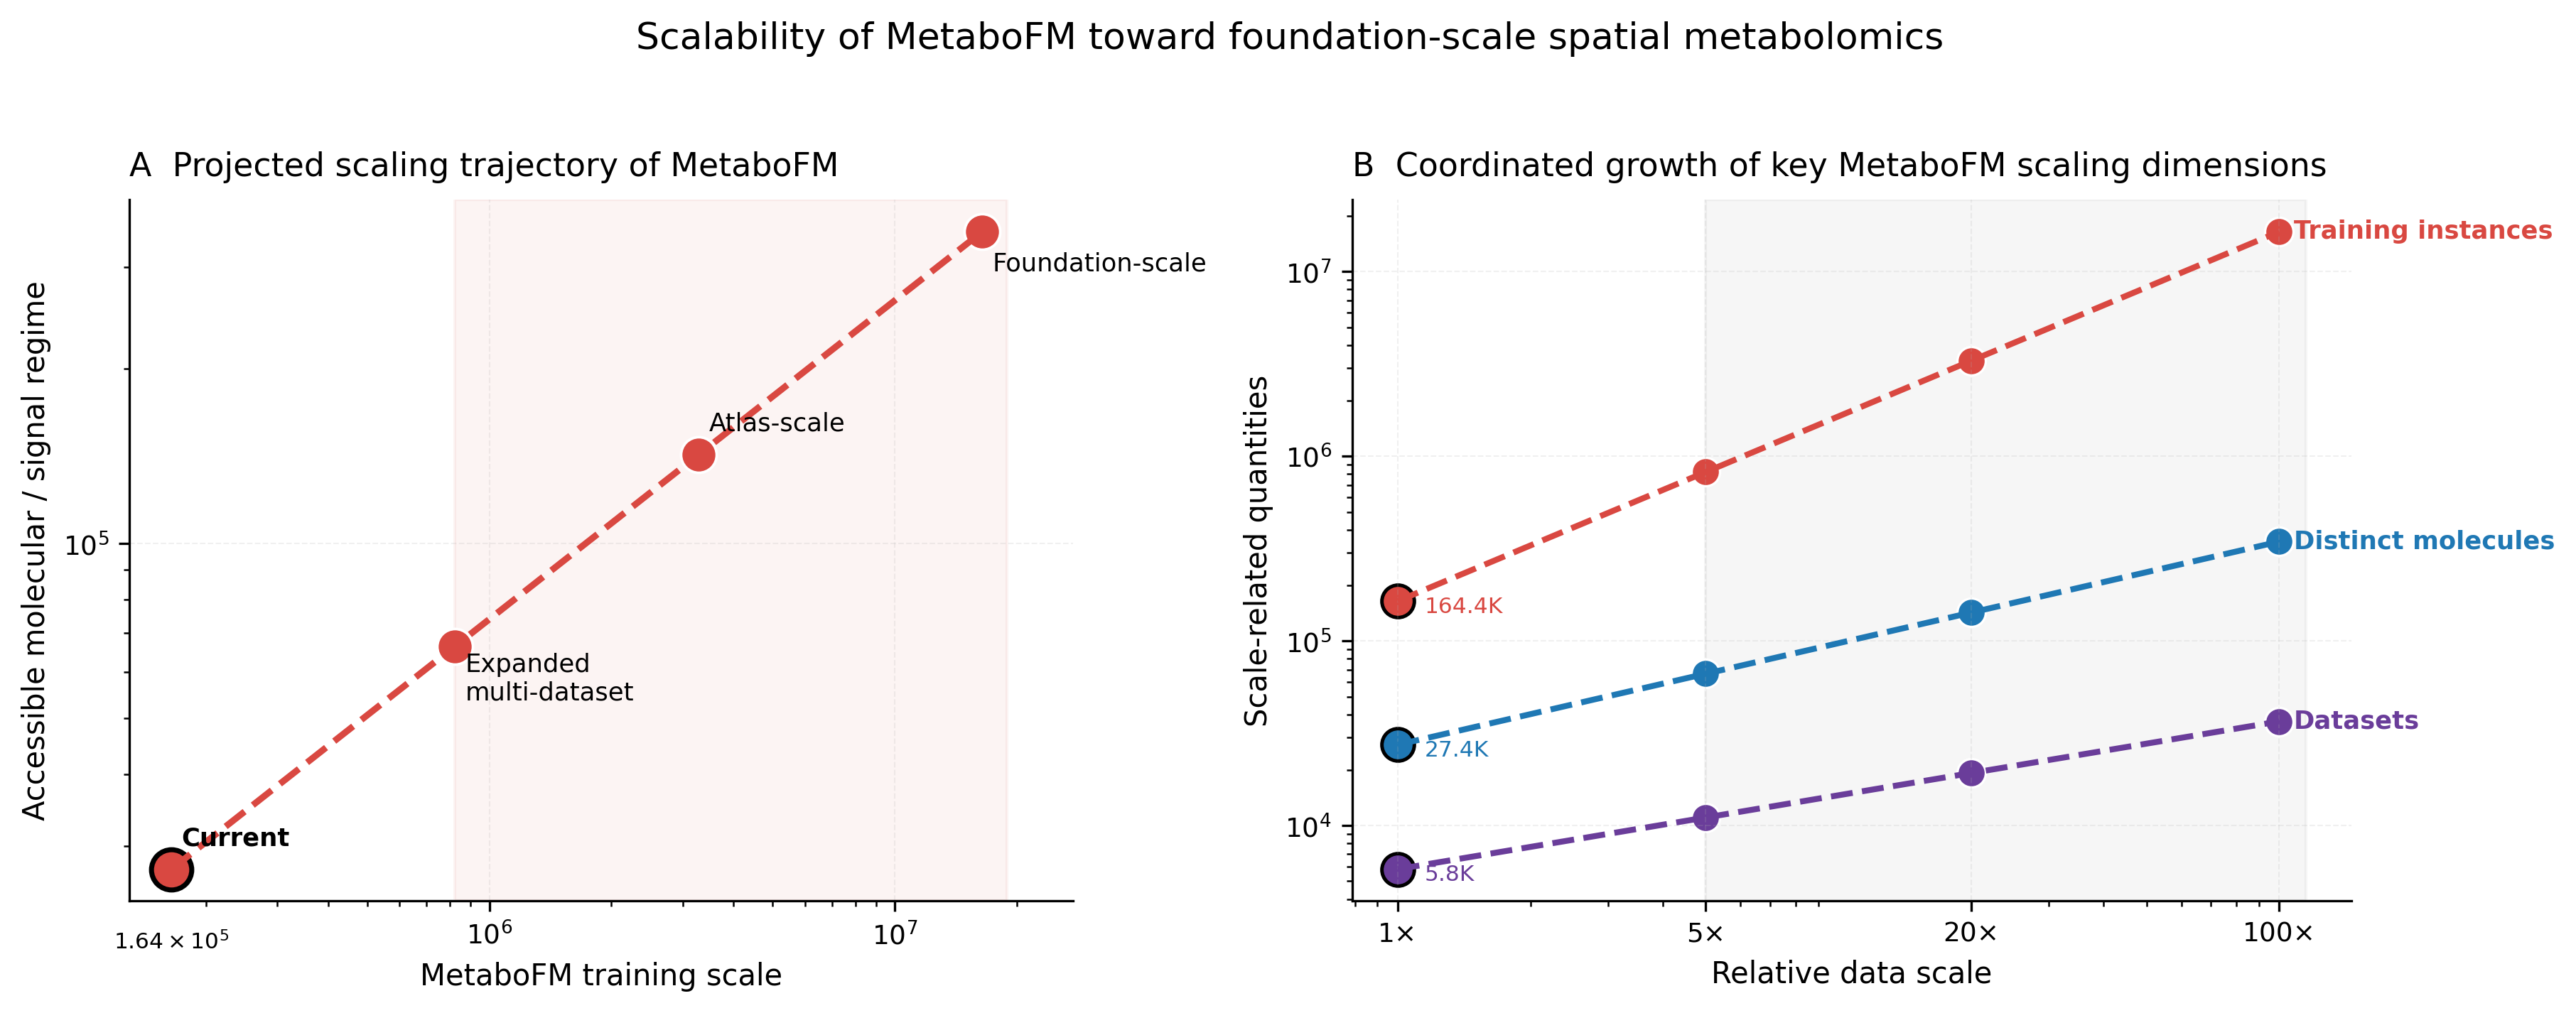

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PAPER FIGURE (FINAL CLEAN VERSION)
#   A) Projected scaling trajectory of MetaboFM
#   B) Coordinated growth (trajectory style)
# ============================================================

# ------------------------------------------------------------
# CURRENT METABOFM VALUES
# ------------------------------------------------------------
CURRENT_INSTANCES = 164_359
CURRENT_MOLECULES = 27_407
CURRENT_DATASETS = 5811   # update if needed

# ------------------------------------------------------------
# SCALE LEVELS
# ------------------------------------------------------------
scale_labels = [
    "Current",
    "Expanded\nmulti-dataset",
    "Atlas-scale",
    "Foundation-scale"
]
scale_mult = np.array([1, 5, 20, 100], dtype=float)

# ------------------------------------------------------------
# PANEL A
# ------------------------------------------------------------
traj_x = CURRENT_INSTANCES * scale_mult
traj_y = CURRENT_MOLECULES * (scale_mult ** 0.55)

# ------------------------------------------------------------
# PANEL B
# ------------------------------------------------------------
metric_specs = [
    {
        "name": "Training instances",
        "color": "#d94841",
        "values": CURRENT_INSTANCES * scale_mult,
    },
    {
        "name": "Distinct molecules",
        "color": "#1f78b4",
        "values": CURRENT_MOLECULES * (scale_mult ** 0.55),
    },
    {
        "name": "Datasets",
        "color": "#6a3d9a",
        "values": CURRENT_DATASETS * (scale_mult ** 0.40),
    },
]

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def fmt_human(n: float) -> str:
    if n >= 1e12:
        return f"{n/1e12:.1f}T"
    if n >= 1e9:
        return f"{n/1e9:.1f}B"
    if n >= 1e6:
        return f"{n/1e6:.1f}M"
    if n >= 1e3:
        return f"{n/1e3:.1f}K"
    return f"{n:.0f}"

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12.2, 4.8),
    dpi=300,
    gridspec_kw={"width_ratios": [1.02, 1.08]}
)

# ============================================================
# PANEL A
# ============================================================
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

ax1.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.18)
ax1.grid(False, which="minor")

ax1.axvspan(traj_x[1], traj_x[-1] * 1.15, color="#d94841", alpha=0.06)

ax1.plot(
    traj_x,
    traj_y,
    linestyle="--",
    linewidth=2.2,
    color="#d94841"
)

for i, (xv, yv, lab) in enumerate(zip(traj_x, traj_y, scale_labels)):
    ax1.scatter(
        xv,
        yv,
        s=185 if i == 0 else 145,
        color="#d94841",
        edgecolor="black" if i == 0 else "white",
        linewidth=1.7 if i == 0 else 0.9
    )

    ax1.text(
        xv * 1.06,
        yv * (1.13 if i % 2 == 0 else 0.88),
        lab,
        fontsize=8.5,
        ha="left",
        va="center",
        fontweight="bold" if i == 0 else "normal"
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("MetaboFM training scale")
ax1.set_ylabel("Accessible molecular / signal regime")
ax1.set_title("A  Projected scaling trajectory of MetaboFM", loc="left", pad=8)
xmin, xmax = ax1.get_xlim()
ax1.set_xlim(xmin, xmax * 1.15)

ax1.annotate(
    r"$1.64 \times 10^5$",
    xy=(traj_x[0], ax1.get_ylim()[0]),
    xytext=(0, -10),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=7.5
)

# ============================================================
# PANEL B
# ============================================================
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

ax2.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.18)
ax2.grid(False, which="minor")

ax2.axvspan(scale_mult[1], scale_mult[-1] * 1.15, color="#000000", alpha=0.035)

for j, spec in enumerate(metric_specs):
    yvals = np.asarray(spec["values"], dtype=float)
    color = spec["color"]

    ax2.plot(
        scale_mult,
        yvals,
        linestyle="--",
        linewidth=2.0,
        color=color
    )

    for i, xv in enumerate(scale_mult):
        ax2.scatter(
            xv,
            yvals[i],
            s=120 if i == 0 else 92,
            color=color,
            edgecolor="black" if i == 0 else "white",
            linewidth=1.2 if i == 0 else 0.8
        )

    # label at end
    ax2.text(
        scale_mult[-1] * 1.08,
        yvals[-1],
        spec["name"],
        color=color,
        fontsize=8.5,
        ha="left",
        va="center",
        fontweight="bold"
    )

    # label current value
    ax2.text(
        scale_mult[0] * 1.15,
        yvals[0] * 0.93,
        fmt_human(yvals[0]),
        color=color,
        fontsize=7.5,
        ha="left",
        va="center"
    )

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Relative data scale")
ax2.set_ylabel("Scale-related quantities")
ax2.set_title("B  Coordinated growth of key MetaboFM scaling dimensions", loc="left", pad=8)

ax2.set_xticks(scale_mult)
ax2.set_xticklabels(["1×", "5×", "20×", "100×"])

# ------------------------------------------------------------
# FINAL TITLE
# ------------------------------------------------------------
fig.suptitle(
    "Scalability of MetaboFM toward foundation-scale spatial metabolomics",
    fontsize=12.5,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()